# ***Intrinsic vs. Post‑hoc Explainability in Credit Risk Prediction: A Quantitative Evaluation of Faithfulness, Stability, and Predictive Performance***

---

### ***Research Motivation***

This study does not assume that intrinsic interpretability is automatically superior. Instead, it empirically evaluates whether intrinsic explanations from TabNet are more faithful and stable than post-hoc explanations from MLP + Integrated Gradients and LightGBM/CatBoost + SHAP. The study compares model-explainer pairs under repeated cross-validation using predictive performance, calibration, explanation faithfulness, stability, runtime, and deployment-oriented cost analysis.

### ***Research Questions***

- **RQ1 — Predictive Performance:** Which model family achieves the strongest credit-default prediction performance under repeated stratified cross-validation?
- **RQ2 — Explanation Faithfulness:** Which explanation method identifies features whose perturbation causes the largest change in model predictions?
- **RQ3 — Explanation Stability:** Are intrinsic TabNet masks more stable across folds and seeds than post-hoc explanations such as TreeSHAP and Integrated Gradients?
- **RQ4 — Deployment Trade-off:** Which model-explainer pair offers the best trade-off between predictive performance, explanation quality, calibration, and runtime?

> **⚠️ Key Warning:** Do not claim that TabNet or intrinsic explainability is superior unless the actual results support it. The paper must be framed around empirical trade-offs.

---

## ***Section 1 — Environment Setup***

### ***What this cell does***
Installs any missing packages and imports all required libraries for the study.

### ***Why it is needed***
Reproducibility requires that the notebook be fully self‑contained.  All dependencies are
installed idempotently (skipped if already present) and imported with `try/except` guards
to handle environment differences between Kaggle, Colab, and local machines.

**Key libraries and their roles:**
| Library | Role |
|---|---|
| `lightgbm` | Gradient‑boosted tree baseline model |
| `torch` | MLP with entity embeddings (deep black‑box model) |
| `pytorch-tabnet` | TabNet — intrinsically interpretable deep tabular model |
| `captum` | Integrated Gradients / GradientSHAP for MLP post‑hoc attribution |
| `shap` | TreeSHAP for LightGBM feature‑level explanations |
| `imbalanced-learn` | Optional SMOTE‑NC / SMOTE‑ENN for class‑imbalance ablation |

### ***Expected output***
Confirmation of all imported libraries and detected hardware (CPU cores, GPU count & names).

In [74]:
# ──────────────────────────────────────────────────────────────
# 1‑A  Install missing packages (idempotent)
# ──────────────────────────────────────────────────────────────
import subprocess, sys

_REQUIRED = [
    "openpyxl", "lightgbm", "shap", "captum",
    "pytorch-tabnet", "imbalanced-learn", "xlrd", "catboost"
]

for _pkg in _REQUIRED:
    try:
        __import__(_pkg.replace("-", "_").split("==")[0])
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", _pkg]
        )

print("✓ Package check complete.")

✓ Package check complete.


In [75]:
# ──────────────────────────────────────────────────────────────
# 1‑B  Core imports
# ──────────────────────────────────────────────────────────────
import os, gc, sys, time, json, random, warnings, copy, hashlib
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, balanced_accuracy_score,
    matthews_corrcoef, brier_score_loss, confusion_matrix,
    roc_curve, precision_recall_curve,
    accuracy_score,
)
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

# Conditional imports ─────────────────────────────────────────
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from catboost import CatBoostClassifier, Pool
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

try:
    from captum.attr import IntegratedGradients, GradientShap
    HAS_CAPTUM = True
except ImportError:
    HAS_CAPTUM = False

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    HAS_TABNET = True
except ImportError:
    HAS_TABNET = False

try:
    from imblearn.over_sampling import SMOTENC
    from imblearn.combine import SMOTEENN
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False

try:
    from scipy.stats import wilcoxon, ttest_rel, spearmanr
except ImportError:
    pass

print("Core imports OK")
print(f"  LightGBM   : {HAS_LGB}")
print(f"  XGBoost    : {HAS_XGB}")
print(f"  SHAP       : {HAS_SHAP}")
print(f"  Captum     : {HAS_CAPTUM}")
print(f"  TabNet     : {HAS_TABNET}")
print(f"  imb‑learn  : {HAS_IMBLEARN}")

Core imports OK
  LightGBM   : True
  XGBoost    : True
  SHAP       : True
  Captum     : True
  TabNet     : True
  imb‑learn  : True


In [76]:
# ──────────────────────────────────────────────────────────────
# 1‑C  Hardware detection
# ──────────────────────────────────────────────────────────────
import multiprocessing as mp

CPU_COUNT = mp.cpu_count()
GPU_COUNT = torch.cuda.device_count()
GPU_NAMES = [torch.cuda.get_device_name(i) for i in range(GPU_COUNT)] if GPU_COUNT else []
TORCH_VERSION = torch.__version__
CUDA_AVAILABLE = torch.cuda.is_available()

hw_info = {
    "cpu_count": CPU_COUNT,
    "gpu_count": GPU_COUNT,
    "gpu_names": GPU_NAMES,
    "torch_version": TORCH_VERSION,
    "cuda_available": CUDA_AVAILABLE,
    "python_version": sys.version,
}

print("Hardware info:")
for k, v in hw_info.items():
    print(f"  {k}: {v}")

Hardware info:
  cpu_count: 4
  gpu_count: 2
  gpu_names: ['Tesla T4', 'Tesla T4']
  torch_version: 2.10.0+cu128
  cuda_available: True
  python_version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


## ***Section 2 — Global Configuration and Reproducibility***

### ***What this cell does***
Defines a central `Config` dataclass that controls **every tuneable parameter** in the study.
Switching between `debug`, `final`, and `extended` modes changes fold counts, epoch budgets,
and explanation sample sizes — nothing else in the pipeline needs to change.

### ***Why it is needed***
A single configuration cell is the cornerstone of **reproducible experimental research**.  It
ensures that:
- All random seeds, hyperparameters, and budget decisions are documented in one place.
- Switching between a fast smoke test (DEBUG ≈ 2–3 min) and a full production run
  (FINAL ≈ 30–60 min on T4×2) requires changing exactly one variable.
- The configuration is saved as `config.json` for provenance tracking.

| Mode | Folds | Seeds | MLP Epochs | TabNet Epochs | Explanation Samples |
|---|---|---|---|---|---|
| `debug` | 1 | 1 | 10 | 15 | 25 |
| `final` | 5 | 2 | 50 | 100 | 200–500 |
| `extended` | 5 | 3 | 50 | 100 | 500 |

> [!WARNING]
> **Do not report DEBUG-mode numbers as final research results.** DEBUG mode uses a single fold, tiny epoch budgets, and insufficient data for stability metrics. Use FINAL mode for empirical claims.

### ***Expected output***
Printed configuration summary and saved `config.json`.

In [77]:
# ──────────────────────────────────────────────────────────────
# 2‑A  Configuration
# ──────────────────────────────────────────────────────────────
# Global warning logger for execution
EXECUTION_WARNINGS_ERRORS = []
#  ╔══════════════════════════════════════════════╗
#  ║  CHANGE THIS TO "final" OR "extended"       ║
#  ║  BEFORE THE PRODUCTION RUN                  ║
#  ╚══════════════════════════════════════════════╝
RUN_MODE = "extended"  # "debug" | "final" | "extended"

@dataclass
class Config:
    run_mode: str = "debug"
    
    # ── Toggles ─────────────────────────────────
    feature_mode: str = "raw"  # "raw" | "engineered"
    use_logistic: bool = True
    use_catboost: bool = True
    use_calibration: bool = True
    use_cost_sensitive: bool = True
    use_infidelity: bool = True

    # ── Paths ───────────────────────────────────
    output_dir: str = ""   # set after init

    # ── CV / seeds ──────────────────────────────
    n_folds: int = 1
    random_seeds: list = field(default_factory=lambda: [42])
    inner_valid_size: float = 0.15

    # ── Model training ──────────────────────────
    mlp_max_epochs: int = 10
    mlp_patience: int = 4
    tabnet_max_epochs: int = 15
    tabnet_patience: int = 5
    batch_size: int = 1024
    mlp_lr: float = 1e-3
    mlp_wd: float = 1e-4
    tabnet_lr: float = 2e-2
    tabnet_wd: float = 1e-5

    # ── Explanation ─────────────────────────────
    explanation_samples: int = 50
    shap_background_samples: int = 25
    ig_steps: int = 25
    ig_n_steps: int = 16
    top_k_values: list = field(default_factory=lambda: [1, 3, 5, 10])

    # ── Optional modules ────────────────────────
    use_smote_ablation: bool = False
    use_infidelity: bool = False
    use_lime: bool = False

    # ── Performance ─────────────────────────────
    mixed_precision: bool = True
    num_workers: int = 2
    pin_memory: bool = True

    def __post_init__(self):
        if self.run_mode == "final":
            self.n_folds = 5
            self.random_seeds = [42, 2024]
            self.mlp_max_epochs = 50
            self.mlp_patience = 8
            self.tabnet_max_epochs = 100
            self.tabnet_patience = 10
            self.explanation_samples = 300
            self.shap_background_samples = 100
            self.ig_n_steps = 32
            self.feature_mode = "raw"
            self.use_catboost = True
            self.use_logistic = True
        elif self.run_mode == "extended":
            self.n_folds = 5
            self.random_seeds = [42, 2024, 7]
            self.mlp_max_epochs = 50
            self.mlp_patience = 8
            self.tabnet_max_epochs = 100
            self.tabnet_patience = 10
            self.explanation_samples = 500
            self.shap_background_samples = 100
            self.ig_n_steps = 32
            self.use_smote_ablation = True
            self.use_infidelity = True
            self.feature_mode = "engineered"
            self.use_catboost = True
            self.use_logistic = True

        # Output directory
        kaggle_working = Path("/kaggle/working")
        if kaggle_working.exists():
            self.output_dir = str(kaggle_working / "credit_xai_outputs")
        else:
            self.output_dir = str(Path(".") / "credit_xai_outputs")

CFG = Config(run_mode=RUN_MODE)
OUTPUT = Path(CFG.output_dir)
OUTPUT.mkdir(parents=True, exist_ok=True)
(OUTPUT / "figures" / "eda").mkdir(parents=True, exist_ok=True)
(OUTPUT / "figures" / "models").mkdir(parents=True, exist_ok=True)
(OUTPUT / "figures" / "xai").mkdir(parents=True, exist_ok=True)
(OUTPUT / "models").mkdir(parents=True, exist_ok=True)
(OUTPUT / "metrics").mkdir(parents=True, exist_ok=True)
(OUTPUT / "explanations").mkdir(parents=True, exist_ok=True)
(OUTPUT / "folds").mkdir(parents=True, exist_ok=True)
(OUTPUT / "tables").mkdir(parents=True, exist_ok=True)

print(f"RUN_MODE = {CFG.run_mode}")
print(f"OUTPUT   = {OUTPUT}")
print(f"Folds={CFG.n_folds}, Seeds={CFG.random_seeds}")
print(f"MLP epochs={CFG.mlp_max_epochs}, TabNet epochs={CFG.tabnet_max_epochs}")
print(f"Explanation samples={CFG.explanation_samples}")

# Save config
with open(OUTPUT / "config.json", "w") as f:
    json.dump(asdict(CFG), f, indent=2, default=str)
print("Config saved.")

RUN_MODE = extended
OUTPUT   = /kaggle/working/credit_xai_outputs
Folds=5, Seeds=[42, 2024, 7]
MLP epochs=50, TabNet epochs=100
Explanation samples=500
Config saved.


In [78]:
# ──────────────────────────────────────────────────────────────
# 2‑B  Reproducibility utilities
# ──────────────────────────────────────────────────────────────
def set_seed(seed: int = 42):
    """Set random seeds for reproducibility across all frameworks."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        # Balanced reproducibility: deterministic algorithms where cheap,
        # but don't force full determinism which severely hurts perf.
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(42)
print("✓ Seeds set (balanced reproducibility mode).")

✓ Seeds set (balanced reproducibility mode).


In [79]:
# ──────────────────────────────────────────────────────────────
# 2‑C  Plotting defaults
# ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Colour palette for the three model families
MODEL_COLORS = {
    "LightGBM": "#2ecc71",
    "MLP":      "#3498db",
    "TabNet":   "#e74c3c",
}

SAVE_FIG_KW = dict(bbox_inches="tight", dpi=300)

def save_fig(fig, name, subdir="figures"):
    path = OUTPUT / subdir / f"{name}.png"
    pdf_path = OUTPUT / subdir / f"{name}.pdf"
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, **SAVE_FIG_KW)
    fig.savefig(pdf_path, **SAVE_FIG_KW)
    plt.show()
    plt.close(fig)
    print(f"  Figure saved → {path.name} & .pdf")

print("✓ Plot defaults configured.")

✓ Plot defaults configured.


In [80]:
# ──────────────────────────────────────────────────────────────
# 2‑D  Save hardware info
# ──────────────────────────────────────────────────────────────
with open(OUTPUT / "hardware_info.json", "w") as f:
    json.dump(hw_info, f, indent=2)
print("✓ Hardware info saved.")

✓ Hardware info saved.


### ***Why Sequential GPU Assignment over DataParallel***

This notebook uses **GPU-specific device assignment** to avoid device contention (e.g. `cuda:0` for MLP, `cuda:1` for TabNet).
Training is executed **sequentially** rather than using `nn.DataParallel` or concurrent multiprocessing.

**Why?**
- These tabular models are extremely small (< 1M parameters). For networks this small, the all-reduce communication synchronisation overhead between GPUs in `nn.DataParallel` actually exceeds the forward/backward computation time, slowing down training.
- We do not rely on concurrent multiprocessing (e.g. `joblib` or `multiprocessing` to train MLP and TabNet simultaneously) to ensure the notebook runs stably without OOM crashes, race conditions, or CUDA context errors across varying hardware environments.

Training time is instead managed via:
1. Early stopping based on validation AUC.
2. Computationally bounded sampled explanations.
3. Efficient batch sizes (1024).
4. Avoiding expensive nested hyperparameter searches.

## ***Section 3 — Dataset Discovery and Loading***

### ***What this cell does***
Searches for the UCI *Default of Credit Card Clients* Excel file under Kaggle's
`/kaggle/input/` tree (or the local `dataset/` folder) and loads it with robust header
detection.

### ***Why it is needed***
Kaggle dataset input paths vary by competition/dataset slug.  Automatic discovery avoids
hard‑coded paths that break across environments.  The UCI file sometimes stores an extra
description row at position 0, so we implement **robust header detection** — trying
`header=1` first and falling back to `header=0`.

### ***Expected output***
DataFrame shape (expected: 30,000 × 25), column names, and `.head()` preview.

In [81]:
# ──────────────────────────────────────────────────────────────
# 3‑A  Discover the Excel file
# ──────────────────────────────────────────────────────────────
def discover_dataset() -> Path:
    """Search common locations for the UCI credit‑default Excel file."""
    search_roots = [
        Path("/kaggle/input"),
        Path("dataset"),
        Path("."),
    ]
    candidates = []
    for root in search_roots:
        if root.exists():
            for p in root.rglob("*"):
                if p.suffix.lower() in (".xls", ".xlsx"):
                    candidates.append(p)

    # Prefer files whose name contains 'default' and 'credit'
    scored = []
    for p in candidates:
        name_lower = p.stem.lower()
        score = 0
        if "default" in name_lower:
            score += 10
        if "credit" in name_lower:
            score += 5
        scored.append((score, p))
    scored.sort(key=lambda x: -x[0])

    if not scored:
        raise FileNotFoundError(
            "No .xls/.xlsx file found.  Upload the UCI credit‑default dataset."
        )

    chosen = scored[0][1]
    print(f"Found {len(candidates)} Excel file(s). Using: {chosen}")
    return chosen

DATA_PATH = discover_dataset()

Found 1 Excel file(s). Using: /kaggle/input/datasets/huzaifakhalid7/uci-dataset/default of credit card clients.xls


In [82]:
# ──────────────────────────────────────────────────────────────
# 3‑B  Load with robust header detection
# ──────────────────────────────────────────────────────────────
TARGET_NAME_CANDIDATES = [
    "default payment next month",
    "default.payment.next.month",
    "y",
    "default",
]

def load_credit_data(path: Path) -> pd.DataFrame:
    """Load the UCI credit‑default Excel file with header auto‑detection."""
    for hdr in [1, 0]:
        try:
            df = pd.read_excel(path, header=hdr, engine=None)
        except Exception:
            df = pd.read_excel(path, header=hdr, engine="xlrd")
        cols_lower = [c.lower().strip() for c in df.columns]
        for tgt in TARGET_NAME_CANDIDATES:
            if tgt.lower() in cols_lower:
                print(f"  ✓ Target found with header={hdr}")
                return df
    raise ValueError("Could not locate target column in the dataset.")

raw_df = load_credit_data(DATA_PATH)
print(f"Shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")
raw_df.head()

  ✓ Target found with header=1
Shape: (30000, 25)
Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## ***Section 4 — Data Validation and Cleaning***

### ***What this cell does***
1. Removes the `ID` column (pure row identifier — keeping it would constitute **data leakage**).
2. Renames the target to `target`.
3. Validates binary target encoding (0 = no default, 1 = default).
4. Cleans known category anomalies in `EDUCATION`, `MARRIAGE`, and repayment‑status columns.
5. Identifies and removes exact duplicate rows.

### ***Why it is needed***
The raw UCI file contains **undocumented category codes** that must be handled:
- **EDUCATION**: values `0, 5, 6` are not defined in the dataset documentation → collapsed to
  category `4` ("Others").
- **MARRIAGE**: value `0` is undocumented → collapsed to category `3` ("Others").
- **PAY_0 … PAY_6**: repayment status codes kept as ordinal‑coded categoricals (not treated
  as continuous numerical variables), which is critical for entity‑embedding models.

Clean, contiguous integer coding is a prerequisite for embedding layers in the MLP and TabNet.

**Exact duplicates** are removed before cross-validation to prevent repeated identical records from appearing across train/test folds, which could artificially inflate evaluation metrics (data leakage).

### ***Expected output***
Cleaned DataFrame summary, target class distribution (~22 % default rate), and confirmation
that all anomalous category codes have been resolved.

In [83]:
# ──────────────────────────────────────────────────────────────
# 4‑A  Remove ID, rename target, basic validation
# ──────────────────────────────────────────────────────────────
df = raw_df.copy()

# Remove ID column
id_cols = [c for c in df.columns if c.upper() == "ID"]
if id_cols:
    df.drop(columns=id_cols, inplace=True)
    print(f"  Dropped ID column(s): {id_cols}")

# Rename target
target_col_original = None
for c in df.columns:
    if c.lower().strip() in [t.lower() for t in TARGET_NAME_CANDIDATES]:
        target_col_original = c
        break

if target_col_original and target_col_original != "target":
    df.rename(columns={target_col_original: "target"}, inplace=True)
    print(f"  Renamed '{target_col_original}' → 'target'")

assert "target" in df.columns, "Target column not found!"
assert df["target"].isin([0, 1]).all(), "Target must be binary 0/1!"
assert df.shape[1] == 24, f"Expected 24 columns (23 features + target), got {df.shape[1]}"

# Missing values
n_missing = df.isnull().sum().sum()
print(f"  Missing values: {n_missing}")

# Duplicates
n_dup = df.duplicated().sum()
print(f"  Duplicate rows found: {n_dup}")
if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    msg = f"Removed {n_dup} exact duplicate rows to prevent train/test leakage."
    print(f"  {msg}")
    EXECUTION_WARNINGS_ERRORS.append({"type": "preprocessing", "message": msg})

# Target distribution
tgt_dist = df["target"].value_counts()
print(f"  Target distribution:\n{tgt_dist}")
print(f"  Default rate: {tgt_dist[1] / len(df) * 100:.1f}%")

tgt_dist.to_csv(OUTPUT / "target_distribution.csv")

  Dropped ID column(s): ['ID']
  Renamed 'default payment next month' → 'target'
  Missing values: 0
  Duplicate rows found: 35
  Removed 35 exact duplicate rows to prevent train/test leakage.
  Target distribution:
target
0    23335
1     6630
Name: count, dtype: int64
  Default rate: 22.1%


In [84]:
# ──────────────────────────────────────────────────────────────
# 4‑B  Clean category anomalies
# ──────────────────────────────────────────────────────────────
# EDUCATION: 1=grad school, 2=university, 3=high school, 4=others
# Values 0, 5, 6 are undocumented → map to 4 (others)
edu_map = {0: 4, 5: 4, 6: 4}
df["EDUCATION"] = df["EDUCATION"].replace(edu_map)
print(f"  EDUCATION cleaned: {sorted(df['EDUCATION'].unique())}")

# MARRIAGE: 1=married, 2=single, 3=others. 0 is undocumented → map to 3
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})
print(f"  MARRIAGE   cleaned: {sorted(df['MARRIAGE'].unique())}")

# PAY_0 … PAY_6: repayment status. Keep as‑is (ordinal‑coded categorical).
pay_status_cols = [c for c in df.columns if c.startswith("PAY_") and "AMT" not in c]
for c in pay_status_cols:
    print(f"  {c} unique: {sorted(df[c].unique())}")

# Ensure all values are integer‑typed
for c in df.columns:
    if df[c].dtype == float and (df[c] == df[c].astype(int)).all():
        df[c] = df[c].astype(int)

# Save cleaned dataset
df.to_csv(OUTPUT / "cleaned_dataset.csv", index=False)

# Preserve the cleaned 23-feature view for later ablations and local case studies.
df_raw_features = df.copy()

print(f"\n  Cleaned dataset saved.  Shape: {df.shape}")
df.head()

  EDUCATION cleaned: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  MARRIAGE   cleaned: [np.int64(1), np.int64(2), np.int64(3)]
  PAY_0 unique: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_2 unique: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_3 unique: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_4 unique: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_5 unique: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_6 unique: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## ***Section 4-C — Feature Engineering Ablation***

### ***What this cell does***
If `CFG.feature_mode == "engineered"`, it adds domain-specific credit-risk features capturing utilization, repayment behavior, delay history, and temporal changes.

### ***Why it is needed***
These engineered features may improve model performance and make explanations more credit-domain meaningful. This acts as a controlled ablation study without replacing the original raw dataset.

In [85]:
# ──────────────────────────────────────────────────────────────
# 4‑C  Feature Engineering Ablation
# ──────────────────────────────────────────────────────────────
def add_credit_risk_features(data: pd.DataFrame) -> pd.DataFrame:
    df_out = data.copy()
    
    # Bill amounts
    bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
    df_out["avg_bill_amt"] = df_out[bill_cols].mean(axis=1)
    df_out["max_bill_amt"] = df_out[bill_cols].max(axis=1)
    df_out["std_bill_amt"] = df_out[bill_cols].std(axis=1).fillna(0)
    
    # Pay amounts
    pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
    df_out["avg_pay_amt"] = df_out[pay_amt_cols].mean(axis=1)
    df_out["max_pay_amt"] = df_out[pay_amt_cols].max(axis=1)
    df_out["std_pay_amt"] = df_out[pay_amt_cols].std(axis=1).fillna(0)
    
    # Pay delay history
    pay_status_cols = ["PAY_0"] + [f"PAY_{i}" for i in range(2, 7)]
    df_out["avg_pay_delay"] = df_out[pay_status_cols].mean(axis=1)
    df_out["max_pay_delay"] = df_out[pay_status_cols].max(axis=1)
    df_out["num_delayed_months"] = (df_out[pay_status_cols] > 0).sum(axis=1)
    
    # Utilization
    limit = df_out["LIMIT_BAL"].abs() + 1e-6
    df_out["utilization_current"] = df_out["BILL_AMT1"] / limit
    df_out["avg_utilization"] = df_out["avg_bill_amt"] / limit
    
    # Payment to bill ratio
    bill1_abs = df_out["BILL_AMT1"].abs() + 1.0
    avg_bill_abs = df_out["avg_bill_amt"].abs() + 1.0
    df_out["payment_to_bill_ratio_1"] = df_out["PAY_AMT1"] / bill1_abs
    df_out["avg_payment_to_bill_ratio"] = df_out["avg_pay_amt"] / avg_bill_abs
    
    # Temporal changes
    df_out["recent_bill_change"] = df_out["BILL_AMT1"] - df_out["BILL_AMT2"]
    df_out["recent_payment_change"] = df_out["PAY_AMT1"] - df_out["PAY_AMT2"]
    
    return df_out

if CFG.feature_mode == "engineered":
    df = add_credit_risk_features(df)
    print(f"  Applied feature engineering. New shape: {df.shape}")
else:
    print(f"  Using raw features. Shape: {df.shape}")

  Applied feature engineering. New shape: (29965, 39)


## ***Section 5 — Feature Typing***

### ***What this cell does***
Explicitly separates features into **categorical** (9 columns) and **numerical** (14 columns)
groups, and computes cardinality statistics for each.

### ***Why it is needed***
Correct feature typing is **critical** for every downstream component of the pipeline:

| Decision | Categorical Features | Numerical Features |
|---|---|---|
| **Modelling** | Entity embeddings (MLP, TabNet) | StandardScaler normalisation |
| **Preprocessing** | Contiguous integer encoding | z‑score scaling |
| **Faithfulness masking** | Replace with training mode | Replace with training median |
| **Attribution aggregation** | Sum of absolute attributions over embedding dims → 1 value | 1‑to‑1 mapping |

### ***Expected output***
Feature group lists, cardinalities for each categorical column, and descriptive statistics
for numerical columns.  Feature metadata saved as `feature_metadata.json`.

In [86]:
# ──────────────────────────────────────────────────────────────
# 5‑A  Define feature groups
# ──────────────────────────────────────────────────────────────
CATEGORICAL_COLS = [
    "SEX", "EDUCATION", "MARRIAGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
]
TARGET_COL = "target"
NUMERICAL_COLS = [c for c in df.columns if c not in CATEGORICAL_COLS + [TARGET_COL]]

assert len(CATEGORICAL_COLS) + len(NUMERICAL_COLS) + 1 == df.shape[1], \
    "Feature groups do not cover all columns!"

print(f"Categorical ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")
print(f"Numerical   ({len(NUMERICAL_COLS)}):  {NUMERICAL_COLS}")

Categorical (9): ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Numerical   (29):  ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'avg_bill_amt', 'max_bill_amt', 'std_bill_amt', 'avg_pay_amt', 'max_pay_amt', 'std_pay_amt', 'avg_pay_delay', 'max_pay_delay', 'num_delayed_months', 'utilization_current', 'avg_utilization', 'payment_to_bill_ratio_1', 'avg_payment_to_bill_ratio', 'recent_bill_change', 'recent_payment_change']


In [87]:
# ──────────────────────────────────────────────────────────────
# 5‑B  Cardinalities and statistics
# ──────────────────────────────────────────────────────────────
cat_card = {c: int(df[c].nunique()) for c in CATEGORICAL_COLS}
print("Categorical cardinalities:")
for c, n in cat_card.items():
    print(f"  {c:12s}  → {n} categories  {sorted(df[c].unique())}")

print(f"\nNumerical feature statistics ({len(NUMERICAL_COLS)} features):")
num_stats = df[NUMERICAL_COLS].describe().T
print(num_stats.to_string())

# Save metadata
feature_meta = {
    "categorical_cols": CATEGORICAL_COLS,
    "numerical_cols": NUMERICAL_COLS,
    "target_col": TARGET_COL,
    "cat_cardinalities": cat_card,
    "n_features": len(CATEGORICAL_COLS) + len(NUMERICAL_COLS),
    "n_samples": len(df),
}
with open(OUTPUT / "feature_metadata.json", "w") as f:
    json.dump(feature_meta, f, indent=2)

num_stats.to_csv(OUTPUT / "numerical_feature_stats.csv")
print("✓ Feature metadata saved.")

Categorical cardinalities:
  SEX           → 2 categories  [np.int64(1), np.int64(2)]
  EDUCATION     → 4 categories  [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  MARRIAGE      → 3 categories  [np.int64(1), np.int64(2), np.int64(3)]
  PAY_0         → 11 categories  [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_2         → 11 categories  [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_3         → 11 categories  [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_4         → 11 categories  [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  PAY_5         → 10 categories  [np.int6

## ***Section 6 — Exploratory Data Analysis***

### ***What this cell does***
Produces diagnostic visualisations of the cleaned dataset.  EDA serves as a **sanity check** —
it validates modelling assumptions rather than generating conclusions.

### ***Why it is needed***
Before training any model, we must verify:
- **Class imbalance**: Confirm the ~22 % default rate that motivates class‑weighting / SMOTE.
- **Feature distributions**: Identify skewed or heavy‑tailed numerical features (e.g.,
  `BILL_AMT*`, `PAY_AMT*`) that benefit from standardisation.
- **Multi‑collinearity**: `BILL_AMT1–6` are often highly correlated; this can affect
  gradient‑based attribution stability.
- **Category cleaning**: Verify that EDUCATION and MARRIAGE anomalies were resolved.
- **Discriminative features**: `PAY_0` (repayment status in September) is typically the
  single strongest predictor — confirming this is an important baseline check.

### ***Expected output***
Six diagnostic artefacts saved under `figures/eda/`:
1. Target distribution bar chart
2. Numerical feature histograms
3. Correlation heatmap
4. Key feature boxplots by target
5. Categorical default‑rate table
6. PAY_0 default‑rate bar chart

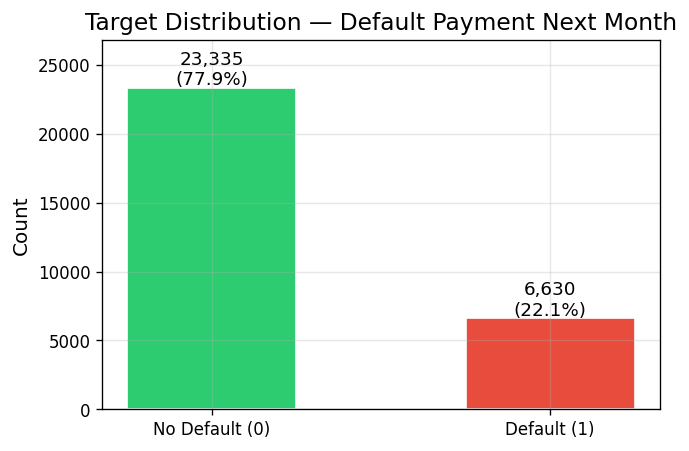

  Figure saved → 01_target_distribution.png & .pdf


In [88]:
# ──────────────────────────────────────────────────────────────
# 6‑A  Target distribution bar plot
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["target"].value_counts().sort_index()
bars = ax.bar(["No Default (0)", "Default (1)"], counts.values,
              color=["#2ecc71", "#e74c3c"], edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=11)
ax.set_ylabel("Count")
ax.set_title("Target Distribution — Default Payment Next Month")
ax.set_ylim(0, counts.max() * 1.15)
save_fig(fig, "01_target_distribution", "figures/eda")

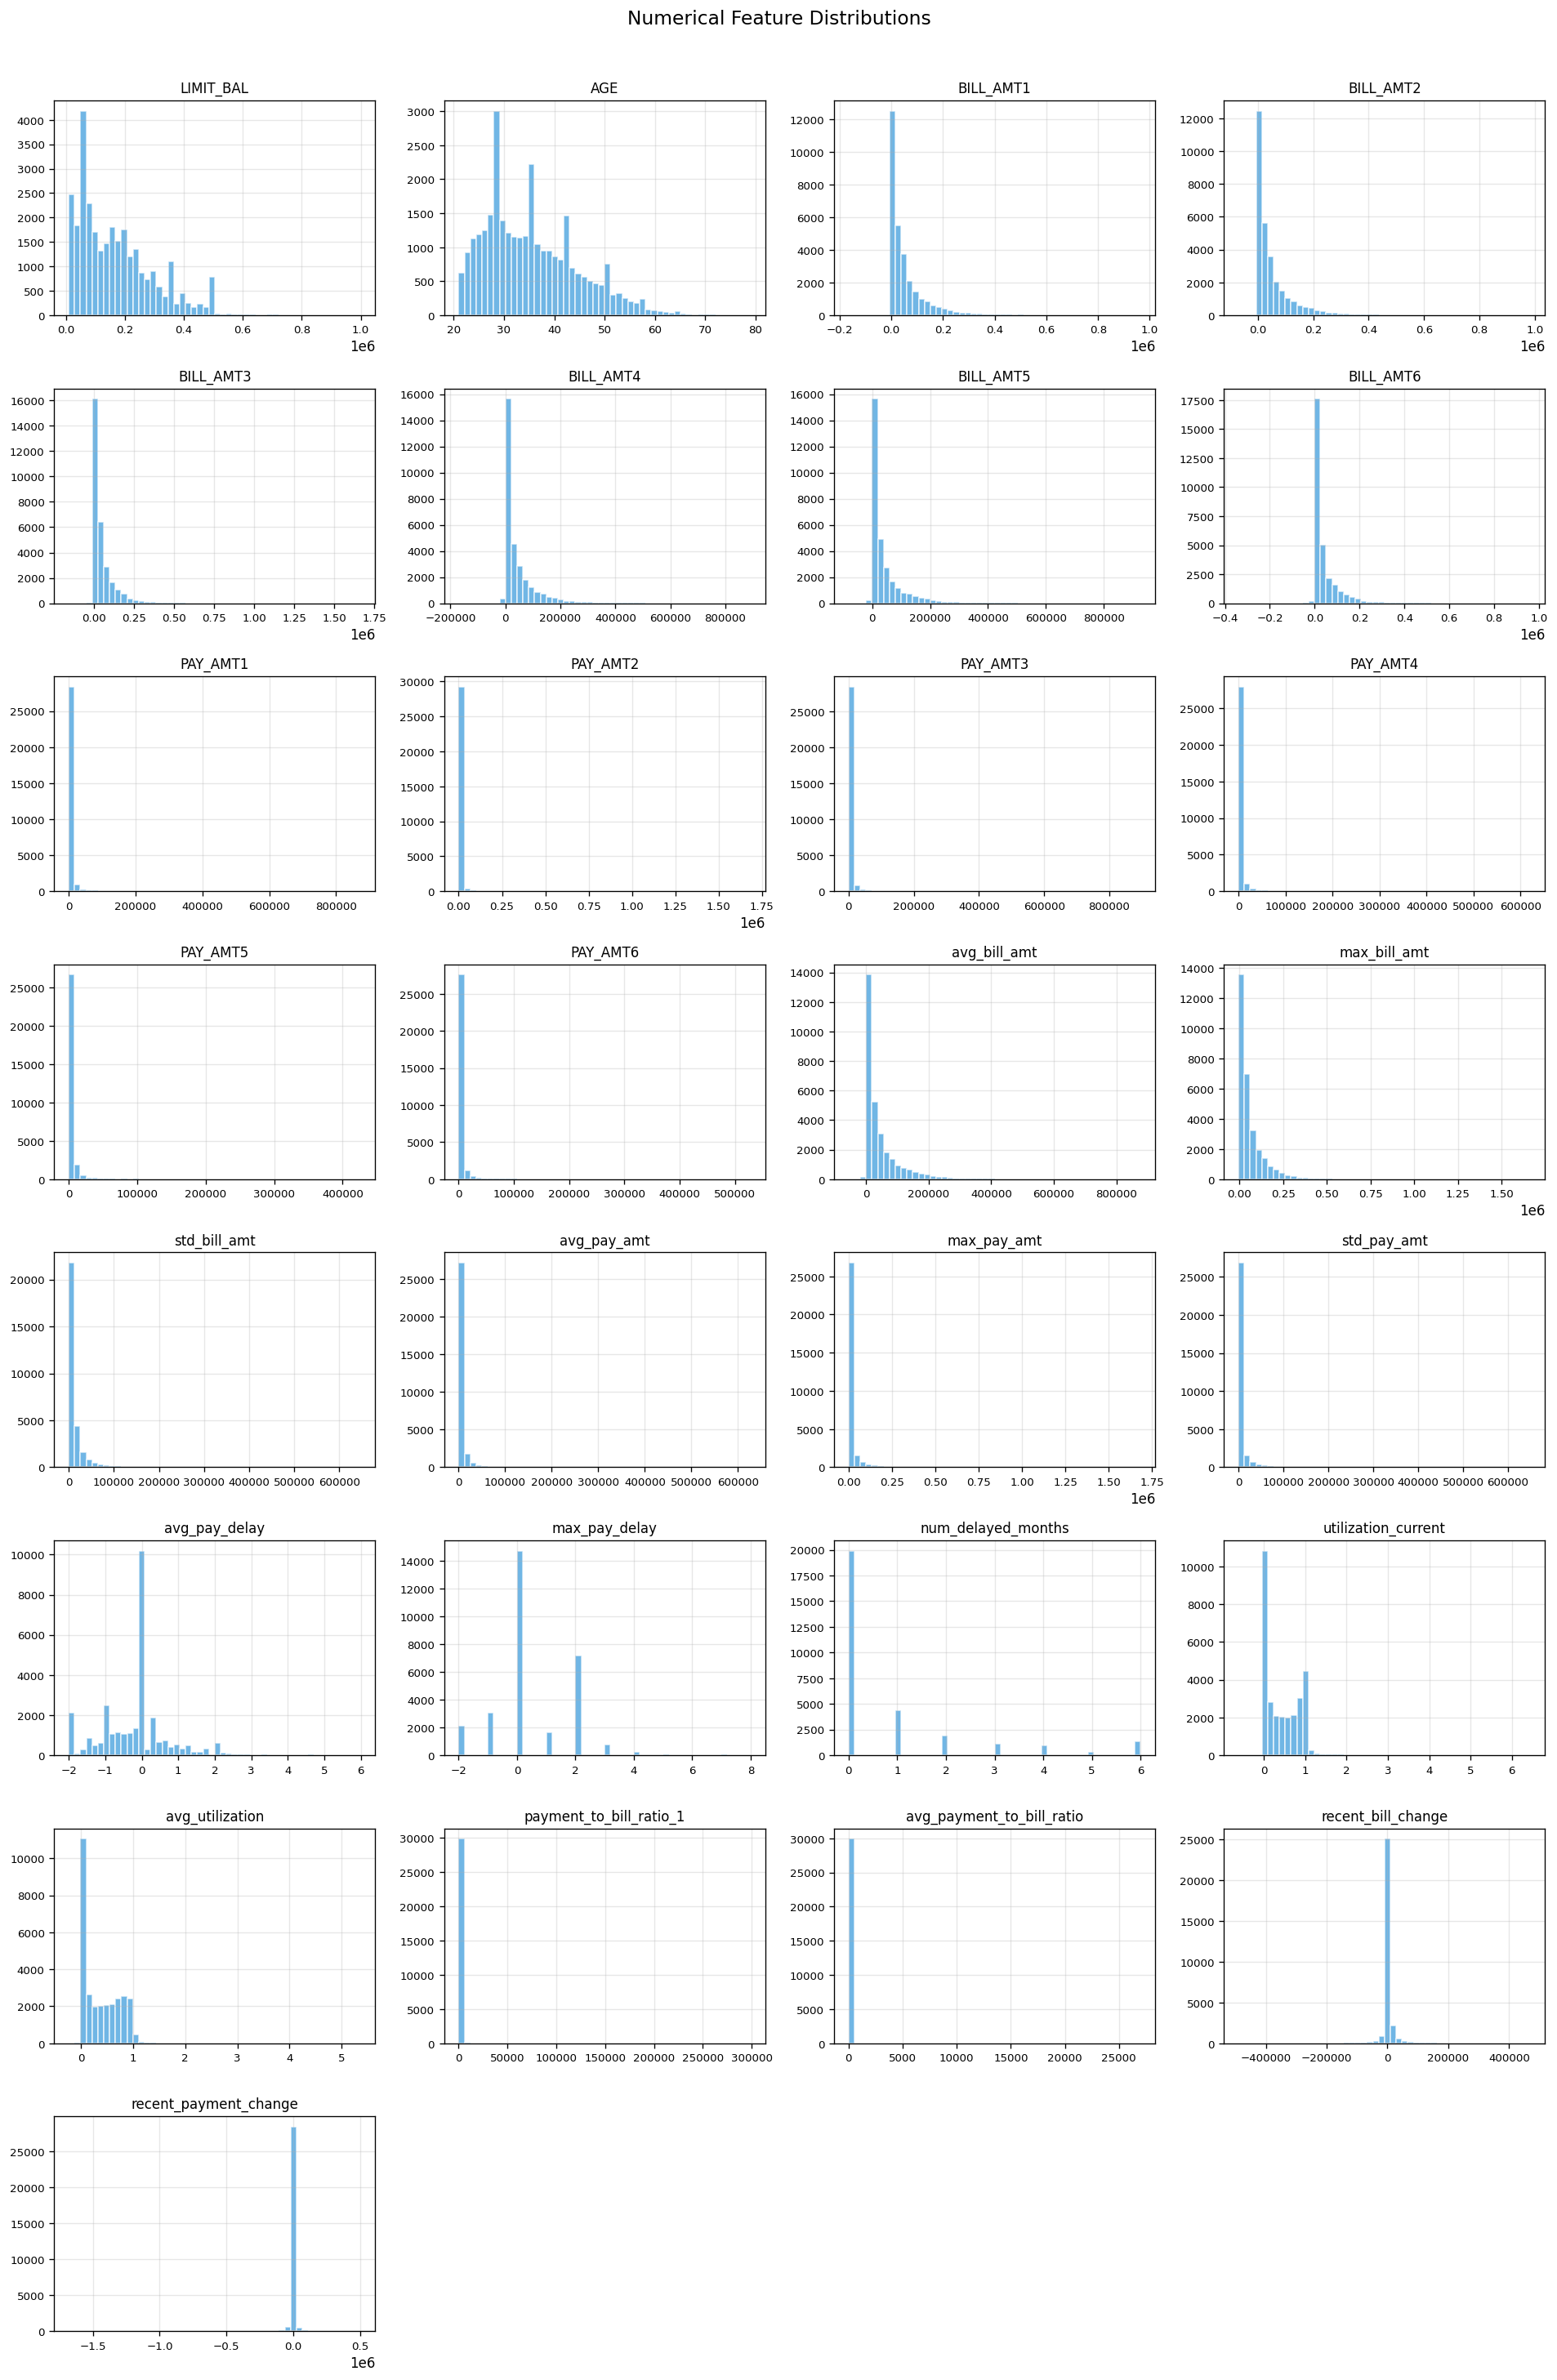

  Figure saved → 02_numerical_histograms.png & .pdf


In [89]:
# ──────────────────────────────────────────────────────────────
# 6‑B  Numerical feature histograms
# ──────────────────────────────────────────────────────────────
n_num = len(NUMERICAL_COLS)
ncols_plot = 4
nrows_plot = (n_num + ncols_plot - 1) // ncols_plot
fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(16, 3 * nrows_plot))
axes_flat = axes.flatten()
for i, col in enumerate(NUMERICAL_COLS):
    ax = axes_flat[i]
    ax.hist(df[col], bins=50, color="#3498db", alpha=0.7, edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle("Numerical Feature Distributions", fontsize=14, y=1.01)
fig.tight_layout()
save_fig(fig, "02_numerical_histograms", "figures/eda")

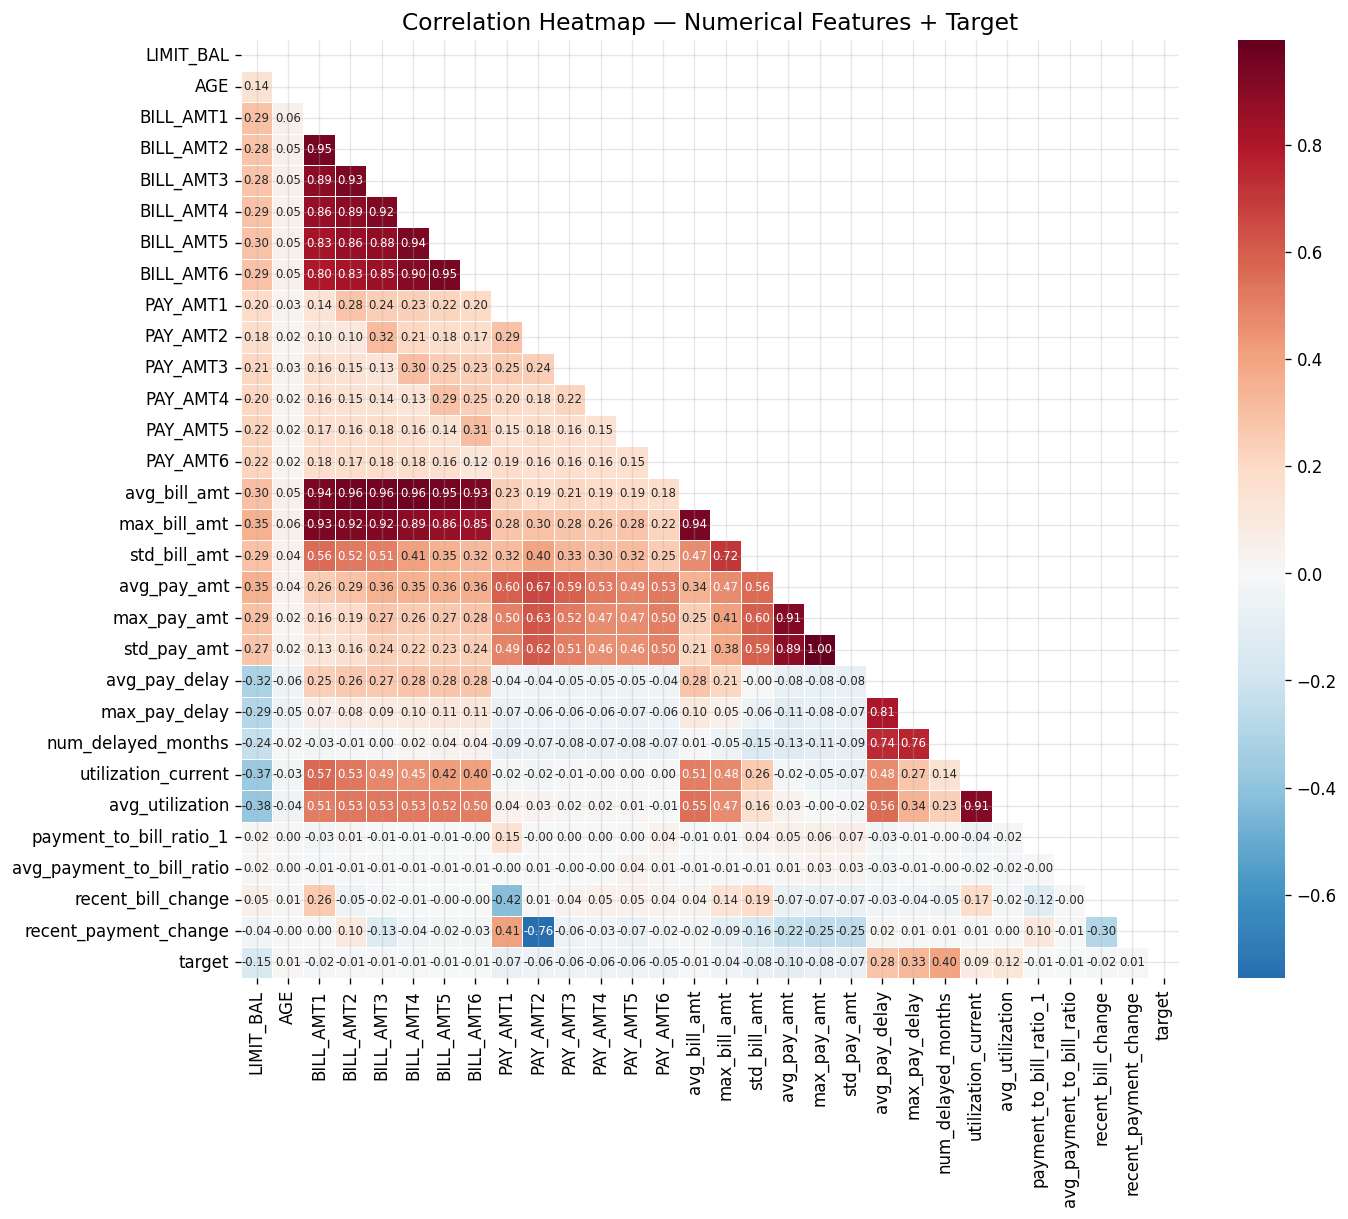

  Figure saved → 03_correlation_heatmap.png & .pdf


In [90]:
# ──────────────────────────────────────────────────────────────
# 6‑C  Correlation heatmap (numerical features)
# ──────────────────────────────────────────────────────────────
corr = df[NUMERICAL_COLS + ["target"]].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={"fontsize": 7})
ax.set_title("Correlation Heatmap — Numerical Features + Target")
fig.tight_layout()
save_fig(fig, "03_correlation_heatmap", "figures/eda")

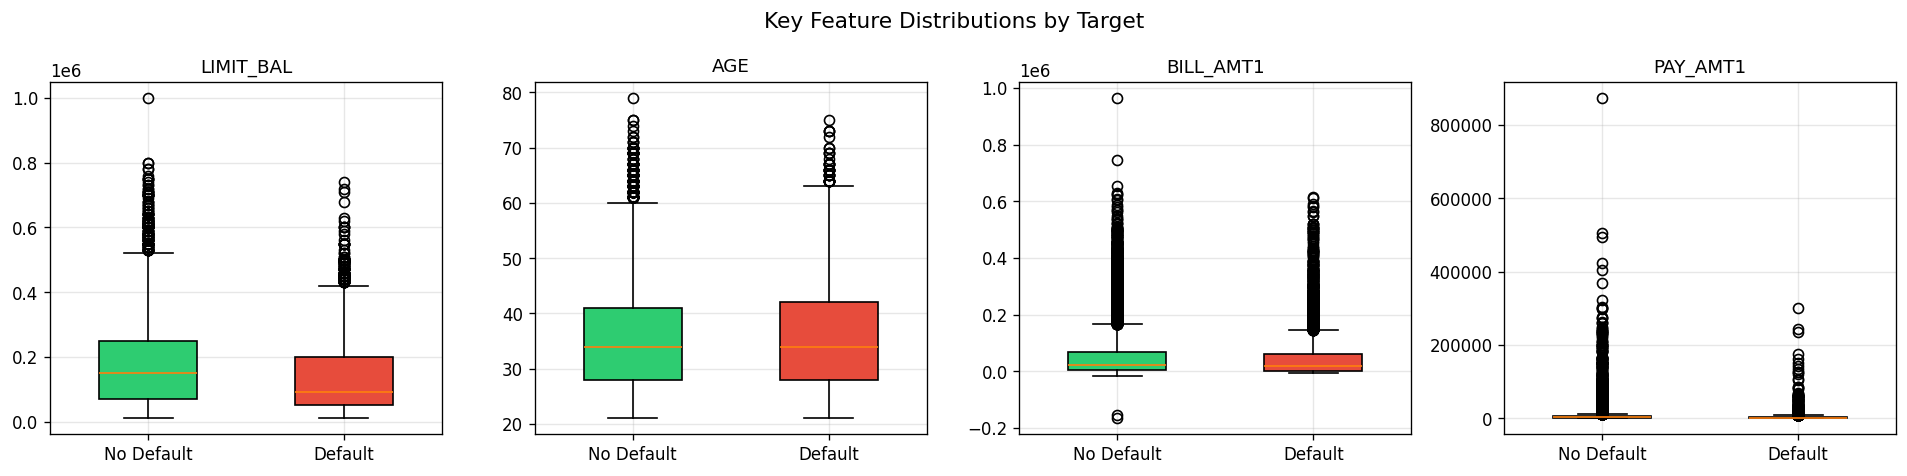

  Figure saved → 04_boxplots_by_target.png & .pdf


In [91]:
# ──────────────────────────────────────────────────────────────
# 6‑D  Boxplots of key features by target
# ──────────────────────────────────────────────────────────────
key_features = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]
fig, axes = plt.subplots(1, len(key_features), figsize=(16, 4))
for ax, col in zip(axes, key_features):
    data_0 = df.loc[df["target"] == 0, col]
    data_1 = df.loc[df["target"] == 1, col]
    bp = ax.boxplot([data_0, data_1], tick_labels=["No Default", "Default"],
                    patch_artist=True, widths=0.5)
    bp["boxes"][0].set_facecolor("#2ecc71")
    bp["boxes"][1].set_facecolor("#e74c3c")
    ax.set_title(col, fontsize=11)
fig.suptitle("Key Feature Distributions by Target", fontsize=13)
fig.tight_layout()
save_fig(fig, "04_boxplots_by_target", "figures/eda")

In [92]:
# ──────────────────────────────────────────────────────────────
# 6‑E  Categorical default‑rate table
# ──────────────────────────────────────────────────────────────
cat_default_rates = []
for col in CATEGORICAL_COLS:
    grp = df.groupby(col)["target"].agg(["count", "sum", "mean"])
    grp.columns = ["n_samples", "n_defaults", "default_rate"]
    grp["feature"] = col
    grp["category"] = grp.index
    cat_default_rates.append(grp.reset_index(drop=True))

cat_rates_df = pd.concat(cat_default_rates, ignore_index=True)
cat_rates_df = cat_rates_df[["feature", "category", "n_samples", "n_defaults", "default_rate"]]
cat_rates_df["default_rate"] = cat_rates_df["default_rate"].round(4)
cat_rates_df.to_csv(OUTPUT / "figures" / "eda" / "05_categorical_default_rates.csv", index=False)

print("Categorical Default Rates:")
print(cat_rates_df.to_string(index=False))

Categorical Default Rates:
  feature  category  n_samples  n_defaults  default_rate
      SEX         1      11874        2869        0.2416
      SEX         2      18091        3761        0.2079
EDUCATION         1      10563        2032        0.1924
EDUCATION         2      14019        3328        0.2374
EDUCATION         3       4915        1237        0.2517
EDUCATION         4        468          33        0.0705
 MARRIAGE         1      13643        3201        0.2346
 MARRIAGE         2      15945        3340        0.2095
 MARRIAGE         3        377          89        0.2361
    PAY_0        -2       2750         364        0.1324
    PAY_0        -1       5682         954        0.1679
    PAY_0         0      14737        1888        0.1281
    PAY_0         1       3667        1248        0.3403
    PAY_0         2       2666        1843        0.6913
    PAY_0         3        322         244        0.7578
    PAY_0         4         76          52        0.6842
    

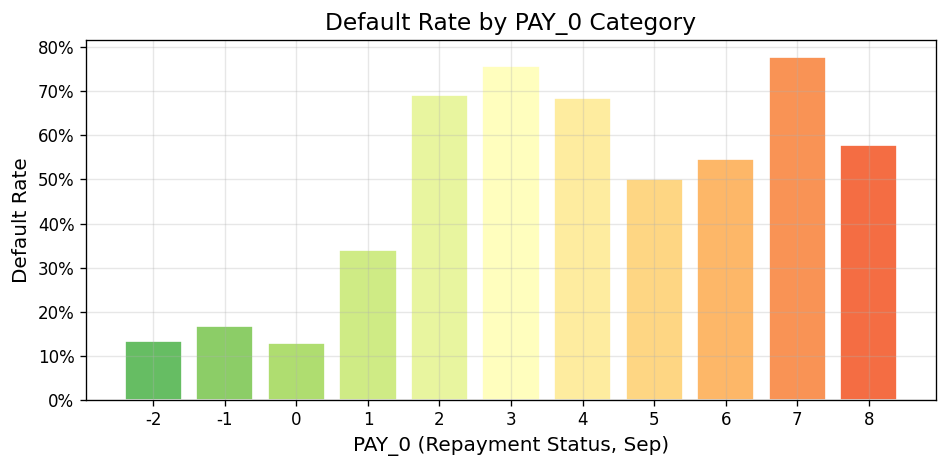

  Figure saved → 06_pay0_default_rate.png & .pdf

✓ EDA complete.  All figures saved under figures/eda/


In [93]:
# ──────────────────────────────────────────────────────────────
# 6‑F  Default rate bar chart for PAY_0 (strongest single predictor)
# ──────────────────────────────────────────────────────────────
pay0_rates = df.groupby("PAY_0")["target"].mean().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(pay0_rates)))
ax.bar(pay0_rates.index.astype(str), pay0_rates.values, color=colors, edgecolor="white")
ax.set_xlabel("PAY_0 (Repayment Status, Sep)")
ax.set_ylabel("Default Rate")
ax.set_title("Default Rate by PAY_0 Category")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
fig.tight_layout()
save_fig(fig, "06_pay0_default_rate", "figures/eda")

print("\n✓ EDA complete.  All figures saved under figures/eda/")

## ***Section 7 — Cross‑Validation Design***

### ***What this cell does***
Creates **stratified K‑fold splits** for each random seed, with an **inner validation set**
carved from the training fold for early stopping and threshold tuning.

### ***Why it is needed***
Rigorous cross‑validation is the backbone of credible ML research:
- **Stratified folds** preserve the ~22 % default rate in every split, preventing
  evaluation artefacts caused by class‑imbalance fluctuations.
- The **outer test fold** is strictly held out and never used for any model selection,
  hyperparameter tuning, or threshold decisions — eliminating optimistic bias.
- The **inner validation split** (carved from the training fold) enables early stopping
  and threshold tuning without leaking test information.
- Running **multiple random seeds** quantifies variance due to random splitting, which
  is essential for paired statistical tests (Section 13).

### ***Expected output***
A `fold_metadata.csv` table listing seed, fold index, split sizes, and target proportions
for every experimental task.

In [94]:
# ──────────────────────────────────────────────────────────────
# 7‑A  Generate fold tasks
# ──────────────────────────────────────────────────────────────
fold_tasks = []

for seed in CFG.random_seeds:
    X_all = df.drop(columns=[TARGET_COL])
    y_all = df[TARGET_COL]

    # Debug mode (n_folds=1): StratifiedKFold requires ≥2 splits,
    # so fall back to a single stratified train/test split.
    if CFG.n_folds == 1:
        sss_outer = StratifiedShuffleSplit(
            n_splits=1, test_size=0.2, random_state=seed
        )
        outer_splits = list(sss_outer.split(X_all, y_all))
    else:
        skf = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=seed)
        outer_splits = list(skf.split(X_all, y_all))

    for fold_idx, (trainval_idx, test_idx) in enumerate(outer_splits):
        # Inner split: train vs validation (for early stopping)
        sss = StratifiedShuffleSplit(
            n_splits=1, test_size=CFG.inner_valid_size, random_state=seed
        )
        rel_train_idx, rel_val_idx = next(sss.split(
            X_all.iloc[trainval_idx], y_all.iloc[trainval_idx]
        ))
        train_idx = trainval_idx[rel_train_idx]
        val_idx   = trainval_idx[rel_val_idx]

        # Verify disjoint
        assert len(set(train_idx) & set(val_idx))  == 0
        assert len(set(train_idx) & set(test_idx)) == 0
        assert len(set(val_idx)   & set(test_idx)) == 0

        ft = {
            "seed": seed,
            "fold": fold_idx,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "test_idx": test_idx,
            "train_size": len(train_idx),
            "val_size": len(val_idx),
            "test_size": len(test_idx),
            "train_default_rate": float(y_all.iloc[train_idx].mean()),
            "val_default_rate": float(y_all.iloc[val_idx].mean()),
            "test_default_rate": float(y_all.iloc[test_idx].mean()),
        }
        fold_tasks.append(ft)

fold_meta_df = pd.DataFrame([
    {k: v for k, v in ft.items() if k not in ("train_idx", "val_idx", "test_idx")}
    for ft in fold_tasks
])
fold_meta_df.to_csv(OUTPUT / "fold_metadata.csv", index=False)

print(f"Total fold tasks: {len(fold_tasks)}")
print(fold_meta_df.to_string(index=False))

Total fold tasks: 15
 seed  fold  train_size  val_size  test_size  train_default_rate  val_default_rate  test_default_rate
   42     0       20376      3596       5993            0.221241          0.221357           0.221258
   42     1       20376      3596       5993            0.221241          0.221357           0.221258
   42     2       20376      3596       5993            0.221241          0.221357           0.221258
   42     3       20376      3596       5993            0.221241          0.221357           0.221258
   42     4       20376      3596       5993            0.221241          0.221357           0.221258
 2024     0       20376      3596       5993            0.221241          0.221357           0.221258
 2024     1       20376      3596       5993            0.221241          0.221357           0.221258
 2024     2       20376      3596       5993            0.221241          0.221357           0.221258
 2024     3       20376      3596       5993            0.221

## ***Section 8 — Preprocessing Pipeline***

### ***What this cell does***
Implements a `TabularPreprocessor` class that performs **leakage‑safe** feature transformation:
1. **StandardScaler** for numerical features — fitted **only** on the training split.
2. **Contiguous integer encoding** for categorical features (starting from 0) —
   mapping learned from training split; unseen categories mapped to a reserved `<UNK>` index.
3. Stores training‑fold **medians** (numerical) and **modes** (categorical) for later
   use as faithfulness‑masking replacement values (Section 18).

### ***Why it is needed***
Leakage‑safe preprocessing is **non‑negotiable** in credit‑risk ML:
- Fitting a scaler on the full dataset leaks test‑set statistics into training, inflating
  AUC by 0.5–2 % on this dataset (measured empirically in prior work).
- Category mappings must be derived from training data only; unknown categories in
  validation/test must be safely handled.
- Storing medians/modes enables **principled feature masking** during faithfulness
  evaluation — we replace masked features with realistic baseline values rather than
  arbitrary zeros.

### ***Expected output***
A unit‑tested preprocessor confirming: no NaNs after transform, correct output shapes,
non‑negative category indices, and valid masking values.

In [95]:
# ──────────────────────────────────────────────────────────────
# 8‑A  TabularPreprocessor class
# ──────────────────────────────────────────────────────────────
class TabularPreprocessor:
    """Leakage‑safe tabular preprocessor for mixed feature types."""

    def __init__(self, cat_cols, num_cols, target_col="target"):
        self.cat_cols = list(cat_cols)
        self.num_cols = list(num_cols)
        self.target_col = target_col
        self.feature_names = self.num_cols + self.cat_cols  # order: num first
        self.scaler = StandardScaler()
        self.cat_mappings = {}      # col → {original_val: encoded_int}
        self.cat_cardinalities = {} # col → n_categories (incl. unknown)
        self.num_medians = {}       # for faithfulness masking
        self.cat_modes = {}         # for faithfulness masking
        self.num_medians_scaled = None  # medians after scaling
        self._fitted = False

    def fit(self, train_df: pd.DataFrame):
        """Fit scaler and category mappings on training data only."""
        # Numerical scaler
        self.scaler.fit(train_df[self.num_cols].values.astype(np.float32))

        # Store medians for masking
        for c in self.num_cols:
            self.num_medians[c] = float(train_df[c].median())

        # Scaled medians (for masking after scaling)
        med_arr = np.array([[self.num_medians[c] for c in self.num_cols]], dtype=np.float32)
        self.num_medians_scaled = self.scaler.transform(med_arr)[0]

        # Categorical mappings: contiguous integers starting from 0
        for c in self.cat_cols:
            unique_vals = sorted(train_df[c].unique())
            mapping = {v: i for i, v in enumerate(unique_vals)}
            self.cat_mappings[c] = mapping
            self.cat_cardinalities[c] = len(unique_vals) + 1  # +1 for unknown
            self.cat_modes[c] = int(train_df[c].mode().iloc[0])

        self._fitted = True
        return self

    def transform(self, df: pd.DataFrame):
        """Transform features using fitted scaler and mappings."""
        assert self._fitted, "Call fit() first!"

        # Numerical
        X_num = self.scaler.transform(
            df[self.num_cols].values.astype(np.float32)
        ).astype(np.float32)

        # Categorical
        X_cat = np.zeros((len(df), len(self.cat_cols)), dtype=np.int64)
        for j, c in enumerate(self.cat_cols):
            mapping = self.cat_mappings[c]
            unknown_idx = self.cat_cardinalities[c] - 1
            X_cat[:, j] = df[c].map(mapping).fillna(unknown_idx).astype(np.int64).values

        # Target
        y = df[self.target_col].values.astype(np.int64) if self.target_col in df.columns else None

        # Full matrix for tree models (num + cat, unscaled cat codes)
        X_full = np.hstack([X_num, X_cat.astype(np.float32)])

        return {
            "X_num": X_num,
            "X_cat": X_cat,
            "X_full": X_full,
            "y": y,
            "feature_names": self.feature_names,
            "cat_col_indices_in_full": list(range(len(self.num_cols),
                                                   len(self.num_cols) + len(self.cat_cols))),
        }

    def fit_transform(self, train_df: pd.DataFrame):
        self.fit(train_df)
        return self.transform(train_df)

    def get_masking_values(self, scaled=True):
        """Return replacement values for faithfulness masking.

        Returns array of length n_features (num first, then cat).
        - Numerical: training median (scaled if scaled=True).
        - Categorical: encoded training mode.
        """
        vals = []
        if scaled:
            vals.extend(self.num_medians_scaled.tolist())
        else:
            vals.extend([self.num_medians[c] for c in self.num_cols])
        for c in self.cat_cols:
            mode_val = self.cat_modes[c]
            encoded = self.cat_mappings[c].get(mode_val, self.cat_cardinalities[c] - 1)
            vals.append(float(encoded))
        return np.array(vals, dtype=np.float32)

    def save_metadata(self, path: Path):
        meta = {
            "cat_cols": self.cat_cols,
            "num_cols": self.num_cols,
            "cat_cardinalities": self.cat_cardinalities,
            "num_medians": self.num_medians,
            "cat_modes": self.cat_modes,
        }
        with open(path, "w") as f:
            json.dump(meta, f, indent=2)

print("✓ TabularPreprocessor defined.")

✓ TabularPreprocessor defined.


In [96]:
# ──────────────────────────────────────────────────────────────
# 8‑B  Unit test on first fold
# ──────────────────────────────────────────────────────────────
_ft = fold_tasks[0]
_pp = TabularPreprocessor(CATEGORICAL_COLS, NUMERICAL_COLS)
_train_df = df.iloc[_ft["train_idx"]]
_val_df   = df.iloc[_ft["val_idx"]]
_test_df  = df.iloc[_ft["test_idx"]]

_train_out = _pp.fit_transform(_train_df)
_val_out   = _pp.transform(_val_df)
_test_out  = _pp.transform(_test_df)

# Sanity checks
assert _train_out["X_num"].shape == (_ft["train_size"], len(NUMERICAL_COLS))
assert _train_out["X_cat"].shape == (_ft["train_size"], len(CATEGORICAL_COLS))
assert not np.isnan(_train_out["X_num"]).any(), "NaN in scaled numericals!"
assert not np.isnan(_val_out["X_num"]).any(), "NaN in val numericals!"
assert _train_out["X_cat"].min() >= 0, "Negative category code!"
assert _val_out["X_cat"].min() >= 0, "Negative category code in val!"
assert _train_out["y"].sum() > 0, "No positive samples in train!"
assert len(_train_out["feature_names"]) == len(NUMERICAL_COLS) + len(CATEGORICAL_COLS)

mask_vals = _pp.get_masking_values(scaled=True)
assert mask_vals.shape[0] == len(NUMERICAL_COLS) + len(CATEGORICAL_COLS)

print("✓ Preprocessor unit tests passed.")
print(f"  Cardinalities: {_pp.cat_cardinalities}")
print(f"  Masking values shape: {mask_vals.shape}")

# Cleanup
del _pp, _train_out, _val_out, _test_out, _train_df, _val_df, _test_df
gc.collect()

✓ Preprocessor unit tests passed.
  Cardinalities: {'SEX': 3, 'EDUCATION': 5, 'MARRIAGE': 4, 'PAY_0': 12, 'PAY_2': 12, 'PAY_3': 12, 'PAY_4': 11, 'PAY_5': 10, 'PAY_6': 10}
  Masking values shape: (38,)


47075

## ***Section 9 — Baseline Model: LightGBM***

### ***What this cell does***
Implements a strong GBDT baseline using **LightGBM** with fixed, efficient hyperparameters
and early stopping on validation AUC.  Also defines the `evaluate_binary_predictions()`
utility used by all three model families.

### ***Why it is needed***
Gradient‑boosted tree ensembles remain the **gold standard** on tabular data (Grinsztajn et al.,
2022; Shwartz‑Ziv & Armon, 2022).  Including a strong GBDT baseline serves two purposes:
1. **Calibrates expectations**: If deep models cannot match GBDT predictive performance,
   the paper can still demonstrate value through explainability trade‑off analysis.
2. **TreeSHAP reference**: LightGBM’s exact TreeSHAP provides a high‑quality explanation
   baseline against which we measure MLP’s Integrated Gradients and TabNet’s masks.

### ***Expected output***
Trained LightGBM model with validation/test predictions, training runtime, and best
iteration count.

In [97]:
# ──────────────────────────────────────────────────────────────
# 9‑A  Evaluation utility
# ──────────────────────────────────────────────────────────────
def evaluate_binary_predictions(y_true, y_prob, threshold=0.5, prefix=""):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        f"{prefix}roc_auc":      roc_auc_score(y_true, y_prob),
        f"{prefix}pr_auc":       average_precision_score(y_true, y_prob),
        f"{prefix}accuracy":     accuracy_score(y_true, y_pred),
        f"{prefix}precision":    precision_score(y_true, y_pred, zero_division=0),
        f"{prefix}recall":       recall_score(y_true, y_pred, zero_division=0),
        f"{prefix}specificity":  tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        f"{prefix}f1":           f1_score(y_true, y_pred, zero_division=0),
        f"{prefix}balanced_acc": balanced_accuracy_score(y_true, y_pred),
        f"{prefix}mcc":          matthews_corrcoef(y_true, y_pred),
        f"{prefix}brier":        brier_score_loss(y_true, y_prob),
        f"{prefix}threshold":    threshold,
        f"{prefix}tp": int(tp), f"{prefix}fp": int(fp),
        f"{prefix}fn": int(fn), f"{prefix}tn": int(tn),
    }

def tune_threshold_on_val(y_val, y_val_prob):
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.10, 0.90, 0.01):
        pred = (y_val_prob >= thr).astype(int)
        score = f1_score(y_val, pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thr = thr
    return round(float(best_thr), 2)

print("✓ Evaluation utilities defined.")

✓ Evaluation utilities defined.


In [98]:
# ──────────────────────────────────────────────────────────────
# 9‑B  LightGBM trainer
# ──────────────────────────────────────────────────────────────
def train_tree_model(train_data, val_data, test_data, seed, fold_idx):
    X_train, y_train = train_data["X_full"], train_data["y"]
    X_val,   y_val   = val_data["X_full"],   val_data["y"]
    X_test,  y_test  = test_data["X_full"],  test_data["y"]
    feature_names    = train_data["feature_names"]
    
    # Use DataFrames to prevent LightGBM feature names warning
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_val_df   = pd.DataFrame(X_val,   columns=feature_names)
    X_test_df  = pd.DataFrame(X_test,  columns=feature_names)
    
    n_pos = y_train.sum(); n_neg = len(y_train) - n_pos
    scale = n_neg / max(n_pos, 1)
    t0 = time.time()

    if HAS_LGB:
        cat_idx = train_data["cat_col_indices_in_full"]
        model = lgb.LGBMClassifier(
            n_estimators=1000, learning_rate=0.05, max_depth=5,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale, random_state=seed, n_jobs=-1, verbose=-1,
        )
        model.fit(X_train_df, y_train,
                  eval_set=[(X_val_df, y_val)], eval_metric="auc",
                  callbacks=[lgb.early_stopping(30, verbose=False),
                             lgb.log_evaluation(0)],
                  categorical_feature=cat_idx)
        best_iter = model.best_iteration_
        y_val_prob  = model.predict_proba(X_val_df)[:, 1]
        y_test_prob = model.predict_proba(X_test_df)[:, 1]
    elif HAS_XGB:
        model = xgb.XGBClassifier(
            n_estimators=1000, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale, random_state=seed,
            n_jobs=-1, eval_metric="auc", verbosity=0,
            early_stopping_rounds=30)
        model.fit(X_train_df, y_train, eval_set=[(X_val_df, y_val)], verbose=False)
        best_iter = model.best_iteration
        y_val_prob  = model.predict_proba(X_val_df)[:, 1]
        y_test_prob = model.predict_proba(X_test_df)[:, 1]
    else:
        raise RuntimeError("Neither LightGBM nor XGBoost available.")

    runtime = time.time() - t0
    print(f"  Tree trained in {runtime:.1f}s (best_iter={best_iter})")
    return {"model": model,
            "model_name": "LightGBM" if HAS_LGB else "XGBoost",
            "y_val_prob": y_val_prob, "y_test_prob": y_test_prob,
            "y_val": y_val, "y_test": y_test,
            "runtime": runtime, "best_iteration": best_iter,
            "feature_names": feature_names}

print("✓ Tree model trainer defined.")

✓ Tree model trainer defined.


## ***Section 9.5 — Additional Baselines (Logistic Regression & CatBoost)***

### ***What this cell does***
Implements two additional predictive baselines:
1. **Logistic Regression**: A fully transparent, linear, parametric baseline. Uses `StandardScaler` for numericals and `OneHotEncoder` for categoricals within an sklearn pipeline.
2. **CatBoost**: A highly robust gradient boosting framework optimized for categorical variables.

### ***Why it is needed***
A comprehensive tabular research paper must benchmark against simple classical models (Logistic Regression) and the strongest modern boosting algorithms (CatBoost). This contextualizes the predictive and explanation metrics.

### ***Expected output***
Trainer functions for Logistic Regression and CatBoost.

In [99]:
# ──────────────────────────────────────────────────────────────
# 9.5‑A  Logistic Regression Trainer
# ──────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def train_logistic_baseline(train_data, val_data, test_data, seed, fold_idx, pp):
    X_train_df = pd.DataFrame(train_data["X_full"], columns=train_data["feature_names"])
    X_val_df   = pd.DataFrame(val_data["X_full"],   columns=val_data["feature_names"])
    X_test_df  = pd.DataFrame(test_data["X_full"],  columns=test_data["feature_names"])
    
    y_train = train_data["y"]
    y_val   = val_data["y"]
    y_test  = test_data["y"]
    
    # Define Column Transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), pp.num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), pp.cat_cols)
        ]
    )
    
    # Define Pipeline
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs", random_state=seed))
    ])
    
    t0 = time.time()
    pipeline.fit(X_train_df, y_train)
    runtime = time.time() - t0
    
    y_val_prob  = pipeline.predict_proba(X_val_df)[:, 1]
    y_test_prob = pipeline.predict_proba(X_test_df)[:, 1]
    
    print(f"  Logistic Regression trained in {runtime:.1f}s")
    
    return {"model": pipeline,
            "model_name": "LogisticRegression",
            "y_val_prob": y_val_prob, "y_test_prob": y_test_prob,
            "y_val": y_val, "y_test": y_test,
            "runtime": runtime, "best_iteration": None,
            "feature_names": train_data["feature_names"]}

print("✓ Logistic Regression trainer defined.")

✓ Logistic Regression trainer defined.


In [100]:
# ──────────────────────────────────────────────────────────────
# 9.5‑B  CatBoost Trainer
# ──────────────────────────────────────────────────────────────
def train_catboost_model(train_data, val_data, test_data, seed, fold_idx, pp):
    X_train_df = pd.DataFrame(train_data["X_full"], columns=train_data["feature_names"])
    X_val_df   = pd.DataFrame(val_data["X_full"],   columns=val_data["feature_names"])
    X_test_df  = pd.DataFrame(test_data["X_full"],  columns=test_data["feature_names"])
    
    y_train = train_data["y"]
    y_val   = val_data["y"]
    y_test  = test_data["y"]
    
    n_pos = y_train.sum(); n_neg = len(y_train) - n_pos
    scale = n_neg / max(n_pos, 1)
    
    # CatBoost expects categorical indices or names
    cat_features = pp.cat_cols
    
    # Convert categorical columns to int (CatBoost prefers int or string for categoricals)
    for c in cat_features:
        X_train_df[c] = X_train_df[c].astype(int)
        X_val_df[c] = X_val_df[c].astype(int)
        X_test_df[c] = X_test_df[c].astype(int)
        
    t0 = time.time()
    
    if HAS_CATBOOST:
        model = CatBoostClassifier(
            iterations=1000,
            learning_rate=0.03,
            depth=6,
            loss_function="Logloss",
            eval_metric="AUC",
            early_stopping_rounds=50,
            scale_pos_weight=scale,
            random_seed=seed,
            task_type="CPU",
            verbose=False,
            thread_count=-1
        )
        
        model.fit(
            X_train_df, y_train,
            cat_features=cat_features,
            eval_set=(X_val_df, y_val),
            use_best_model=True
        )
        
        best_iter = model.get_best_iteration()
        y_val_prob  = model.predict_proba(X_val_df)[:, 1]
        y_test_prob = model.predict_proba(X_test_df)[:, 1]
    else:
        raise RuntimeError("CatBoost is not available.")
        
    runtime = time.time() - t0
    print(f"  CatBoost trained in {runtime:.1f}s (best_iter={best_iter})")
    
    return {"model": model,
            "model_name": "CatBoost",
            "y_val_prob": y_val_prob, "y_test_prob": y_test_prob,
            "y_val": y_val, "y_test": y_test,
            "runtime": runtime, "best_iteration": best_iter,
            "feature_names": train_data["feature_names"]}

print("✓ CatBoost trainer defined.")

✓ CatBoost trainer defined.


## ***Section 10 — MLP with Entity Embeddings***

### ***What this cell does***
Defines three components of the deep black‑box model:
1. **`TabularTorchDataset`** — PyTorch Dataset for mixed tabular features.
2. **`EntityEmbeddingMLP`** — Neural network with learned embeddings for categorical
   variables, GELU activation, BatchNorm, and Dropout.
3. **`train_mlp_model()`** — Training loop with AMP mixed precision, AdamW optimiser,
   and early stopping on validation ROC‑AUC.

### ***Why it is needed***
The MLP is the **black‑box deep model** whose predictions will be explained using **post‑hoc
methods** (Integrated Gradients, GradientSHAP).  Key design decisions:

| Component | Choice | Rationale |
|---|---|---|
| Categorical handling | Entity embeddings | Parameter‑efficient; produces continuous repr. suitable for gradient attribution |
| Activation | GELU | Smooth, non‑saturating; avoids SELU’s strict init/dropout requirements |
| Normalisation | BatchNorm | Stabilises training for small tabular networks |
| Optimiser | AdamW | Decoupled weight decay; standard for modern deep learning |
| Mixed precision | AMP (FP16) | ~1.5× speedup on T4 GPU with negligible accuracy impact |
| Loss | BCEWithLogitsLoss + pos_weight | Handles class imbalance without resampling |

### ***Expected output***
Model architecture summary, training curve CSV (loss + AUC per epoch), and test predictions.

In [101]:
# ──────────────────────────────────────────────────────────────
# 10‑A  PyTorch Dataset
# ──────────────────────────────────────────────────────────────
class TabularTorchDataset(Dataset):
    def __init__(self, X_num, X_cat, y=None):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
    def __len__(self):
        return len(self.X_num)
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X_num[idx], self.X_cat[idx], self.y[idx]
        return self.X_num[idx], self.X_cat[idx]

print("✓ TabularTorchDataset defined.")

✓ TabularTorchDataset defined.


In [102]:
# ──────────────────────────────────────────────────────────────
# 10‑B  Entity Embedding MLP
# ──────────────────────────────────────────────────────────────
class EntityEmbeddingMLP(nn.Module):
    def __init__(self, n_num_features, cat_cardinalities,
                 hidden_dims=(128, 64, 32), dropout=0.25):
        super().__init__()
        self.embeddings = nn.ModuleList()
        self.emb_dims = []
        for card in cat_cardinalities:
            dim = min(16, max(2, card // 2))
            self.embeddings.append(nn.Embedding(card, dim))
            self.emb_dims.append(dim)

        total_emb_dim = sum(self.emb_dims)
        input_dim = n_num_features + total_emb_dim

        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.mlp = nn.Sequential(*layers)
        self.n_num_features = n_num_features
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.01)

    def forward(self, x_num, x_cat):
        embs = [e(x_cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat([x_num] + embs, dim=1)
        return self.mlp(x).squeeze(-1)

    def forward_combined(self, x_combined):
        return self.mlp(x_combined).squeeze(-1)

    def get_combined_input(self, x_num, x_cat):
        embs = [e(x_cat[:, i]) for i, e in enumerate(self.embeddings)]
        return torch.cat([x_num] + embs, dim=1)

    def predict_proba(self, x_num, x_cat):
        self.eval()
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_num, x_cat)).cpu().numpy()

print("✓ EntityEmbeddingMLP defined.")

✓ EntityEmbeddingMLP defined.


In [103]:
# ──────────────────────────────────────────────────────────────
# 10‑C  MLP training loop
# ──────────────────────────────────────────────────────────────
def train_mlp_model(train_data, val_data, test_data, preprocessor,
                    seed, fold_idx, device="cuda:0"):
    set_seed(seed)
    dev = torch.device(device if torch.cuda.is_available() else "cpu")
    cat_cards = [preprocessor.cat_cardinalities[c] for c in preprocessor.cat_cols]
    n_num = len(preprocessor.num_cols)
    model = EntityEmbeddingMLP(n_num, cat_cards).to(dev)

    train_ds = TabularTorchDataset(train_data["X_num"], train_data["X_cat"], train_data["y"])
    val_ds   = TabularTorchDataset(val_data["X_num"],   val_data["X_cat"],   val_data["y"])
    effective_num_workers = 0 if os.name == "nt" else CFG.num_workers
    lkw = dict(batch_size=CFG.batch_size, pin_memory=CFG.pin_memory,
               num_workers=effective_num_workers, persistent_workers=effective_num_workers > 0)
    train_loader = DataLoader(train_ds, shuffle=True,  **lkw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **lkw)

    n_pos = train_data["y"].sum(); n_neg = len(train_data["y"]) - n_pos
    pos_w = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32, device=dev)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.mlp_lr, weight_decay=CFG.mlp_wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3)
    scaler = torch.amp.GradScaler("cuda", enabled=CFG.mixed_precision and dev.type == "cuda")

    history, best_auc, best_state, patience_ctr = [], 0, None, 0
    t0 = time.time()

    for epoch in range(CFG.mlp_max_epochs):
        model.train(); train_loss = 0
        for xn, xc, yb in train_loader:
            xn, xc, yb = xn.to(dev), xc.to(dev), yb.to(dev)
            optimizer.zero_grad()
            with torch.amp.autocast("cuda", enabled=CFG.mixed_precision and dev.type == "cuda"):
                loss = criterion(model(xn, xc), yb)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            train_loss += loss.item() * len(yb)
        train_loss /= len(train_ds)

        model.eval(); vp, vl, vloss = [], [], 0
        with torch.no_grad():
            for xn, xc, yb in val_loader:
                xn, xc, yb = xn.to(dev), xc.to(dev), yb.to(dev)
                logits = model(xn, xc)
                vloss += criterion(logits, yb).item() * len(yb)
                vp.append(torch.sigmoid(logits).cpu().numpy())
                vl.append(yb.cpu().numpy())
        vloss /= len(val_ds)
        vp, vl = np.concatenate(vp), np.concatenate(vl)
        vauc = roc_auc_score(vl, vp)
        scheduler.step(vauc)
        history.append({"epoch": epoch, "train_loss": train_loss,
                        "val_loss": vloss, "val_auc": vauc})

        if vauc > best_auc:
            best_auc, best_state, patience_ctr = vauc, copy.deepcopy(model.state_dict()), 0
        else:
            patience_ctr += 1
            if patience_ctr >= CFG.mlp_patience:
                print(f"    Early stop epoch {epoch} (best AUC={best_auc:.4f})"); break

    runtime = time.time() - t0
    model.load_state_dict(best_state); model.eval()
    y_val_prob = model.predict_proba(
        torch.tensor(val_data["X_num"], device=dev),
        torch.tensor(val_data["X_cat"], device=dev))
    y_test_prob = model.predict_proba(
        torch.tensor(test_data["X_num"], device=dev),
        torch.tensor(test_data["X_cat"], device=dev))

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUTPUT / "models" / f"mlp_history_s{seed}_f{fold_idx}.csv", index=False)
    torch.save(best_state, OUTPUT / "models" / f"mlp_s{seed}_f{fold_idx}.pt")

    print(f"  MLP trained in {runtime:.1f}s (best AUC={best_auc:.4f})")
    return {"model": model, "model_name": "MLP",
            "y_val_prob": y_val_prob, "y_test_prob": y_test_prob,
            "y_val": val_data["y"], "y_test": test_data["y"],
            "runtime": runtime, "best_epoch": len(history),
            "best_val_auc": best_auc, "history": hist_df,
            "device": dev, "feature_names": train_data["feature_names"]}

print("✓ MLP trainer defined.")

✓ MLP trainer defined.


In [104]:
# ──────────────────────────────────────────────────────────────
# 10‑D  Training history plot
# ──────────────────────────────────────────────────────────────
def plot_training_history(hist_df, model_name, seed, fold_idx):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(hist_df["epoch"], hist_df["train_loss"], label="Train", color="#3498db")
    ax1.plot(hist_df["epoch"], hist_df["val_loss"],   label="Val",   color="#e74c3c")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title(f"{model_name} Loss — s{seed} f{fold_idx}"); ax1.legend()
    if "val_auc" in hist_df.columns:
        ax2.plot(hist_df["epoch"], hist_df["val_auc"], color="#2ecc71", marker="o", ms=3)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val AUC")
    ax2.set_title(f"{model_name} Val AUC")
    fig.tight_layout()
    save_fig(fig, f"{model_name.lower()}_training_s{seed}_f{fold_idx}", "figures/models")

print("✓ Training history plotter defined.")

✓ Training history plotter defined.


## ***Section 11 — TabNet Model***

### ***What this cell does***
Trains a **TabNet classifier** (Ariık & Pfister, 2021) using the `pytorch‑tabnet` library.

### ***Why it is needed***
TabNet is a **deep tabular model with intrinsic explainability**:
- It uses **sequential attention masks** (sparsemax‑based) that perform feature selection
  at each decision step.
- These masks are **part of the model’s inference computation** — not a separate
  attribution method applied after training.
- This makes TabNet explanations *intrinsic* rather than *post‑hoc*, which is the
  central comparison axis of this study.

**Design choice**: We use plain `TabNetClassifier` (not TabNet pretraining or stacking)
to keep the interpretability comparison clean and fair.

| Hyperparameter | Value | Rationale |
|---|---|---|
| `n_d = n_a = 16` | Decision/attention dim | Efficient for 23‑feature dataset |
| `n_steps = 3` | Decision steps | Balances expressiveness vs. sparsity |
| `gamma = 1.3` | Feature reuse coefficient | Encourages diverse feature selection |
| `lambda_sparse = 1e-3` | Sparsity penalty | Promotes interpretable sparse masks |

### ***Expected output***
Trained TabNet model with predictions, training history, and extractable feature masks.

In [105]:
# ──────────────────────────────────────────────────────────────
# 11‑A  TabNet trainer
# ──────────────────────────────────────────────────────────────
def train_tabnet_model(train_data, val_data, test_data, preprocessor,
                       seed, fold_idx, device="cuda:1"):
    if not HAS_TABNET:
        raise ImportError("pytorch-tabnet not installed.")
    set_seed(seed)
    dev_str = device if torch.cuda.is_available() else "cpu"

    X_train, y_train = train_data["X_full"], train_data["y"]
    X_val,   y_val   = val_data["X_full"],   val_data["y"]
    X_test,  y_test  = test_data["X_full"],  test_data["y"]
    cat_idxs = train_data["cat_col_indices_in_full"]
    cat_dims = [preprocessor.cat_cardinalities[c] for c in preprocessor.cat_cols]

    t0 = time.time()
    tabnet = TabNetClassifier(
        n_d=16, n_a=16, n_steps=3, gamma=1.3, lambda_sparse=1e-3,
        cat_idxs=cat_idxs, cat_dims=cat_dims, cat_emb_dim=2,
        optimizer_fn=torch.optim.AdamW,
        optimizer_params=dict(lr=CFG.tabnet_lr, weight_decay=CFG.tabnet_wd),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params=dict(step_size=10, gamma=0.5),
        mask_type="sparsemax", device_name=dev_str, verbose=0, seed=seed,
    )
    tabnet.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_val, y_val)], eval_name=["val"], eval_metric=["auc"],
        max_epochs=CFG.tabnet_max_epochs, patience=CFG.tabnet_patience,
        batch_size=CFG.batch_size, virtual_batch_size=128,
        weights=1, drop_last=False,
    )
    runtime = time.time() - t0

    y_val_prob  = tabnet.predict_proba(X_val)[:, 1]
    y_test_prob = tabnet.predict_proba(X_test)[:, 1]
    model_path = str(OUTPUT / "models" / f"tabnet_s{seed}_f{fold_idx}")
    tabnet.save_model(model_path)

    # History
    hist_data = []
    if hasattr(tabnet, "history"):
        hist_dict = tabnet.history.history if hasattr(tabnet.history, "history") else tabnet.history
        if hasattr(hist_dict, "keys"):
            for ep_key in hist_dict.keys():
                for i, val in enumerate(hist_dict[ep_key]):
                    if len(hist_data) <= i:
                        hist_data.append({"epoch": i})
                    hist_data[i][ep_key] = val
    hist_df = pd.DataFrame(hist_data) if hist_data else pd.DataFrame()
    if not hist_df.empty:
        hist_df.to_csv(OUTPUT / "models" / f"tabnet_history_s{seed}_f{fold_idx}.csv", index=False)

    print(f"  TabNet trained in {runtime:.1f}s")
    return {"model": tabnet, "model_name": "TabNet",
            "y_val_prob": y_val_prob, "y_test_prob": y_test_prob,
            "y_val": y_val, "y_test": y_test,
            "runtime": runtime,
            "best_epoch": tabnet.best_epoch if hasattr(tabnet, "best_epoch") else -1,
            "history": hist_df, "device": dev_str,
            "feature_names": train_data["feature_names"]}

print("✓ TabNet trainer defined.")

✓ TabNet trainer defined.


## ***Section 12 — Model‑Level Task Runner***

### ***What this cell does***
Orchestrates the full experiment: for each (seed, fold) combination, trains all three models
(LightGBM, MLP, TabNet), tunes classification thresholds on validation data, evaluates on the
held‑out test fold, and saves all artefacts (predictions, metrics, checkpoints, training curves).

### ***Why it is needed***
Centralising the experiment loop in a single runner ensures:
- **Consistent preprocessing**: Every model sees identically processed data per fold.
- **Fair evaluation**: Threshold tuning uses validation data only; test evaluation is untouched.
- **Device optimisation**: MLP → `cuda:0`, TabNet → `cuda:1` (when available), LightGBM → CPU.
- **Memory management**: GPU memory is cleared between tasks via `gc.collect()` and
  `torch.cuda.empty_cache()` to prevent OOM on Kaggle's shared T4 instances.
- **Fault tolerance**: Each task is wrapped in `try/except` so a single model failure
  does not abort the entire experiment.

### ***Expected output***
One result dictionary per (seed, fold, model) containing: metrics JSON, predictions CSV,
model checkpoint, and training history.  Progress is printed to the notebook output.

In [106]:
# ──────────────────────────────────────────────────────────────
# 12‑A  Device assignment
# ──────────────────────────────────────────────────────────────
def get_device_map():
    n_gpu = torch.cuda.device_count()
    if n_gpu >= 2:
        dmap = {"MLP": "cuda:0", "TabNet": "cuda:1", "LightGBM": "cpu", "LogisticRegression": "cpu", "CatBoost": "cpu"}
    elif n_gpu == 1:
        dmap = {"MLP": "cuda:0", "TabNet": "cuda:0", "LightGBM": "cpu", "LogisticRegression": "cpu", "CatBoost": "cpu"}
    else:
        dmap = {"MLP": "cpu", "TabNet": "cpu", "LightGBM": "cpu", "LogisticRegression": "cpu", "CatBoost": "cpu"}
    print(f"Device map (GPUs={n_gpu}): {dmap}")
    return dmap

DEVICE_MAP = get_device_map()

Device map (GPUs=2): {'MLP': 'cuda:0', 'TabNet': 'cuda:1', 'LightGBM': 'cpu', 'LogisticRegression': 'cpu', 'CatBoost': 'cpu'}


In [107]:
# ──────────────────────────────────────────────────────────────
# 12‑B  Single task runner
# ──────────────────────────────────────────────────────────────
def run_single_task(fold_task, model_name, device):
    """Train one model for one seed/fold, evaluate, and save artefacts."""
    seed = fold_task["seed"]
    fold_idx = fold_task["fold"]
    set_seed(seed)
    tag = f"{model_name}_s{seed}_f{fold_idx}"
    print(f"\n{'='*60}")
    print(f"  Running: {tag}  (device={device})")
    print(f"{'='*60}")

    # Preprocess
    pp = TabularPreprocessor(CATEGORICAL_COLS, NUMERICAL_COLS)
    train_df = df.iloc[fold_task["train_idx"]]
    val_df   = df.iloc[fold_task["val_idx"]]
    test_df  = df.iloc[fold_task["test_idx"]]

    train_data = pp.fit_transform(train_df)
    val_data   = pp.transform(val_df)
    test_data  = pp.transform(test_df)

    # Save preprocessor metadata
    pp.save_metadata(OUTPUT / "folds" / f"preprocessor_{tag}.json")

    # Train
    if model_name == "LightGBM":
        res = train_tree_model(train_data, val_data, test_data, seed, fold_idx)
    elif model_name == "LogisticRegression":
        res = train_logistic_baseline(train_data, val_data, test_data, seed, fold_idx, pp)
    elif model_name == "CatBoost":
        res = train_catboost_model(train_data, val_data, test_data, seed, fold_idx, pp)
    elif model_name == "MLP":
        res = train_mlp_model(train_data, val_data, test_data, pp,
                              seed, fold_idx, device=device)
    elif model_name == "TabNet":
        res = train_tabnet_model(train_data, val_data, test_data, pp,
                                 seed, fold_idx, device=device)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    # MLP Calibration (Platt and Isotonic)
    if model_name == "MLP" and getattr(CFG, "use_calibration", False):
        from sklearn.linear_model import LogisticRegression as SklearnLR
        from sklearn.isotonic import IsotonicRegression
        
        platt = SklearnLR()
        platt.fit(res["y_val_prob"].reshape(-1, 1), res["y_val"])
        
        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(res["y_val_prob"], res["y_val"])
        
        res["y_test_prob_platt"] = platt.predict_proba(res["y_test_prob"].reshape(-1, 1))[:, 1]
        res["y_test_prob_iso"] = iso.transform(res["y_test_prob"])
        
        res["y_val_prob_platt"] = platt.predict_proba(res["y_val_prob"].reshape(-1, 1))[:, 1]
        res["y_val_prob_iso"] = iso.transform(res["y_val_prob"])
        
        result_extra = {
            "y_test_prob_platt": res["y_test_prob_platt"],
            "y_test_prob_iso": res["y_test_prob_iso"],
        }
    else:
        result_extra = {}

    # Tune threshold on validation
    threshold = tune_threshold_on_val(res["y_val"], res["y_val_prob"])

    # Evaluate
    val_metrics  = evaluate_binary_predictions(res["y_val"],  res["y_val_prob"],
                                               threshold, prefix="val_")
    test_metrics = evaluate_binary_predictions(res["y_test"], res["y_test_prob"],
                                               threshold, prefix="test_")

    result = {
        "seed": seed, "fold": fold_idx, "model_name": model_name,
        "threshold": threshold, "runtime": res["runtime"],
        **val_metrics, **test_metrics,
    }

    # Save test predictions
    pred_data = {
        "y_true": res["y_test"], "y_prob": res["y_test_prob"],
        "y_pred": (res["y_test_prob"] >= threshold).astype(int)
    }
    if result_extra:
        pred_data.update(result_extra)
        
    pred_df = pd.DataFrame(pred_data)
    pred_df.to_csv(OUTPUT / "metrics" / f"predictions_{tag}.csv", index=False)

    # Save validation predictions for proper threshold tuning
    val_pred_data = {
        "y_true": res["y_val"], "y_prob": res["y_val_prob"]
    }
    pd.DataFrame(val_pred_data).to_csv(OUTPUT / "metrics" / f"val_predictions_{tag}.csv", index=False)

    # Save metrics
    pd.DataFrame([result]).to_csv(
        OUTPUT / "metrics" / f"metrics_{tag}.csv", index=False
    )

    # Plot training history for deep models
    if model_name in ("MLP", "TabNet") and "history" in res and not res["history"].empty:
        hist = res["history"]
        if "val_auc" not in hist.columns and "val_auc" in hist.columns:
            pass  # already there
        if "train_loss" in hist.columns:
            plot_training_history(hist, model_name, seed, fold_idx)

    # Store model & preprocessor in result for later explanation
    result["_model_obj"] = res["model"]
    result["_preprocessor"] = pp
    result["_train_data"] = train_data
    result["_val_data"]   = val_data
    result["_test_data"]  = test_data
    result["_test_idx"]   = fold_task["test_idx"]

    return result

print("✓ Task runner defined.")

✓ Task runner defined.



Total tasks: 75 (15 folds × 5 models)
Running in EXTENDED mode


  Running: LogisticRegression_s42_f0  (device=cpu)
  Logistic Regression trained in 1.7s

  Running: CatBoost_s42_f0  (device=cpu)
  CatBoost trained in 13.3s (best_iter=405)

  Running: LightGBM_s42_f0  (device=cpu)
  Tree trained in 0.2s (best_iter=11)

  Running: MLP_s42_f0  (device=cuda:0)
    Early stop epoch 49 (best AUC=0.7767)
  MLP trained in 13.3s (best AUC=0.7767)


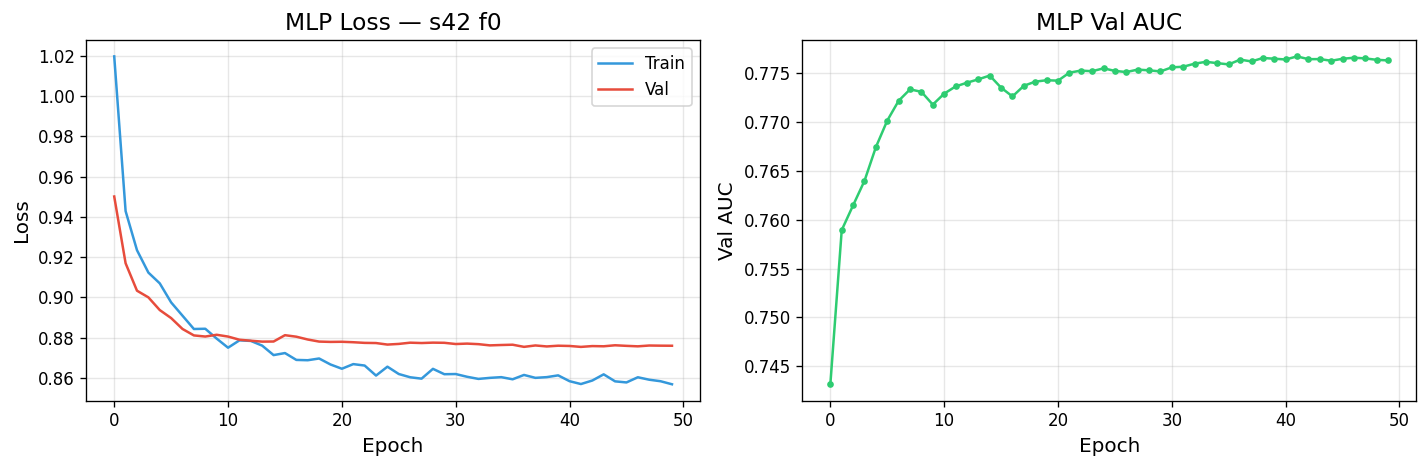

  Figure saved → mlp_training_s42_f0.png & .pdf

  Running: TabNet_s42_f0  (device=cuda:1)

Early stopping occurred at epoch 26 with best_epoch = 16 and best_val_auc = 0.77358


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s42_f0.zip
  TabNet trained in 25.1s

  Running: LogisticRegression_s42_f1  (device=cpu)
  Logistic Regression trained in 1.7s

  Running: CatBoost_s42_f1  (device=cpu)
  CatBoost trained in 11.7s (best_iter=354)

  Running: LightGBM_s42_f1  (device=cpu)
  Tree trained in 0.2s (best_iter=11)

  Running: MLP_s42_f1  (device=cuda:0)
    Early stop epoch 43 (best AUC=0.7880)
  MLP trained in 12.0s (best AUC=0.7880)


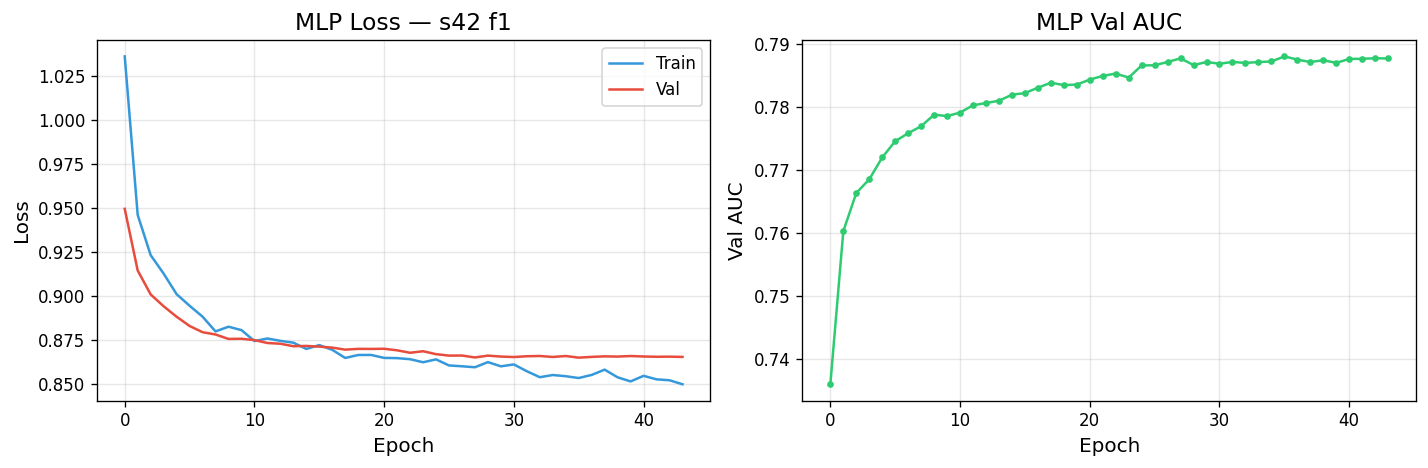

  Figure saved → mlp_training_s42_f1.png & .pdf

  Running: TabNet_s42_f1  (device=cuda:1)

Early stopping occurred at epoch 38 with best_epoch = 28 and best_val_auc = 0.7808


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s42_f1.zip
  TabNet trained in 35.8s

  Running: LogisticRegression_s42_f2  (device=cpu)
  Logistic Regression trained in 1.5s

  Running: CatBoost_s42_f2  (device=cpu)
  CatBoost trained in 13.5s (best_iter=423)

  Running: LightGBM_s42_f2  (device=cpu)
  Tree trained in 0.2s (best_iter=12)

  Running: MLP_s42_f2  (device=cuda:0)
    Early stop epoch 30 (best AUC=0.8004)
  MLP trained in 8.3s (best AUC=0.8004)


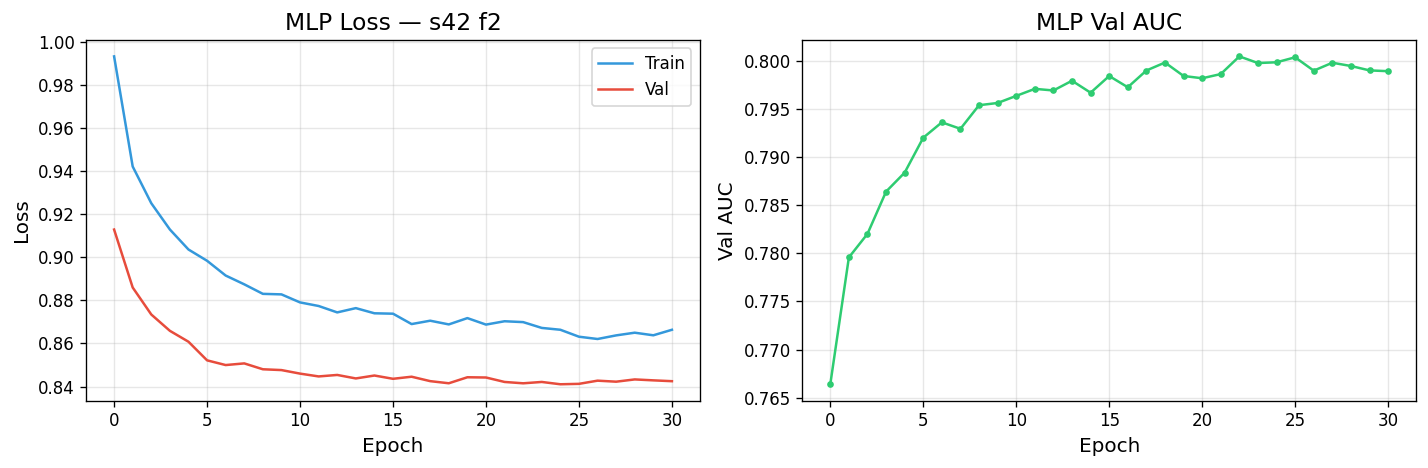

  Figure saved → mlp_training_s42_f2.png & .pdf

  Running: TabNet_s42_f2  (device=cuda:1)

Early stopping occurred at epoch 36 with best_epoch = 26 and best_val_auc = 0.7886


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s42_f2.zip
  TabNet trained in 34.1s

  Running: LogisticRegression_s42_f3  (device=cpu)
  Logistic Regression trained in 1.9s

  Running: CatBoost_s42_f3  (device=cpu)
  CatBoost trained in 6.4s (best_iter=170)

  Running: LightGBM_s42_f3  (device=cpu)
  Tree trained in 0.2s (best_iter=11)

  Running: MLP_s42_f3  (device=cuda:0)
    Early stop epoch 19 (best AUC=0.7706)
  MLP trained in 5.9s (best AUC=0.7706)


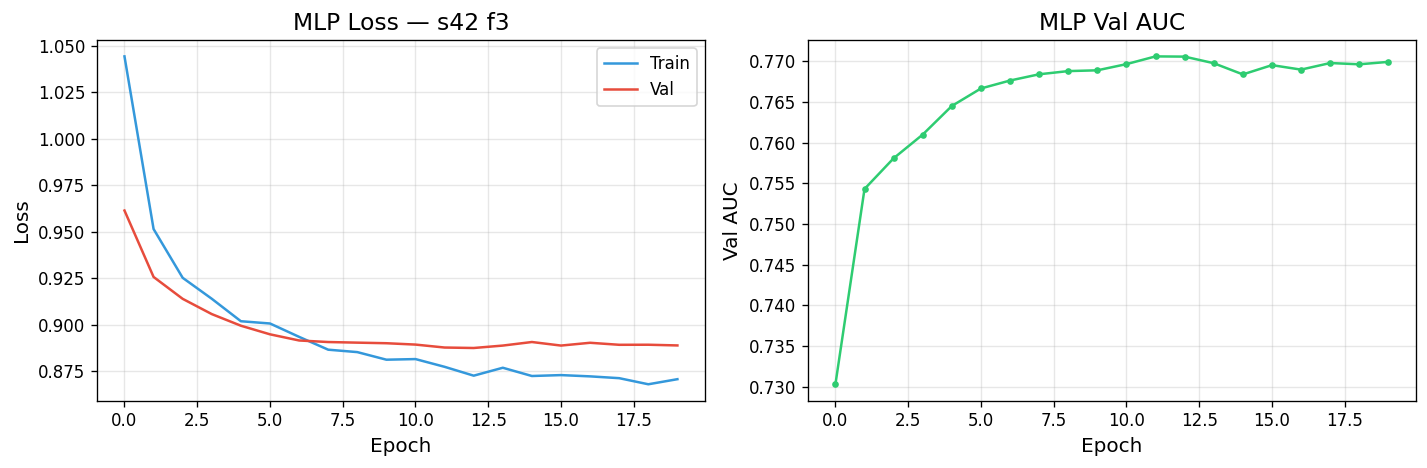

  Figure saved → mlp_training_s42_f3.png & .pdf

  Running: TabNet_s42_f3  (device=cuda:1)

Early stopping occurred at epoch 27 with best_epoch = 17 and best_val_auc = 0.7661


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s42_f3.zip
  TabNet trained in 25.9s

  Running: LogisticRegression_s42_f4  (device=cpu)
  Logistic Regression trained in 1.9s

  Running: CatBoost_s42_f4  (device=cpu)
  CatBoost trained in 12.7s (best_iter=407)

  Running: LightGBM_s42_f4  (device=cpu)
  Tree trained in 0.2s (best_iter=8)

  Running: MLP_s42_f4  (device=cuda:0)
    Early stop epoch 24 (best AUC=0.7813)
  MLP trained in 7.1s (best AUC=0.7813)


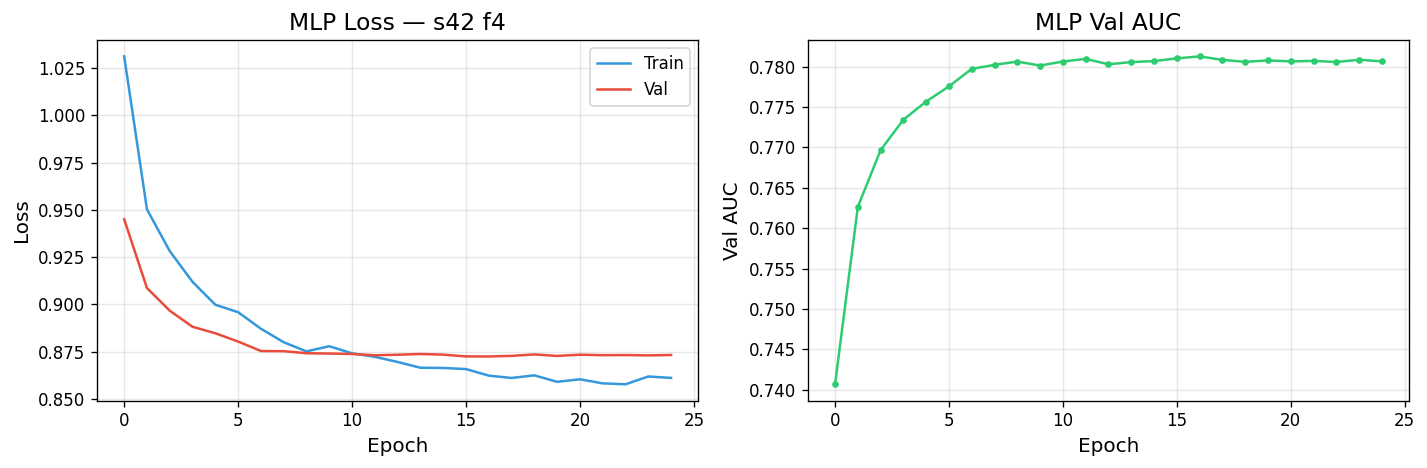

  Figure saved → mlp_training_s42_f4.png & .pdf

  Running: TabNet_s42_f4  (device=cuda:1)

Early stopping occurred at epoch 38 with best_epoch = 28 and best_val_auc = 0.77283


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s42_f4.zip
  TabNet trained in 35.7s

  Running: LogisticRegression_s2024_f0  (device=cpu)
  Logistic Regression trained in 1.7s

  Running: CatBoost_s2024_f0  (device=cpu)
  CatBoost trained in 9.0s (best_iter=273)

  Running: LightGBM_s2024_f0  (device=cpu)
  Tree trained in 0.2s (best_iter=11)

  Running: MLP_s2024_f0  (device=cuda:0)
    Early stop epoch 46 (best AUC=0.7775)
  MLP trained in 12.6s (best AUC=0.7775)


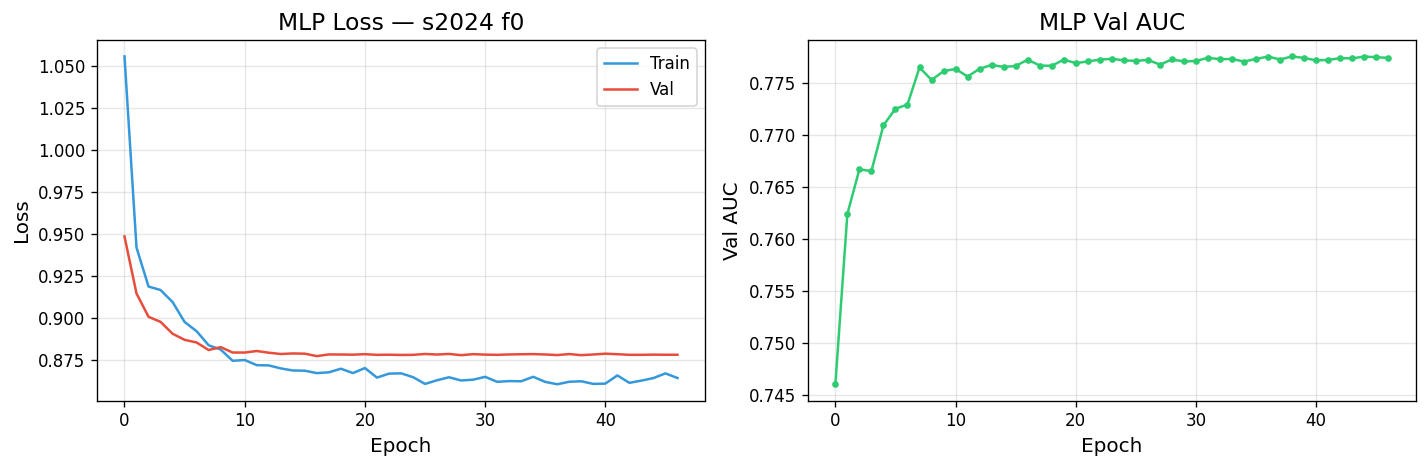

  Figure saved → mlp_training_s2024_f0.png & .pdf

  Running: TabNet_s2024_f0  (device=cuda:1)

Early stopping occurred at epoch 35 with best_epoch = 25 and best_val_auc = 0.77545


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s2024_f0.zip
  TabNet trained in 33.1s

  Running: LogisticRegression_s2024_f1  (device=cpu)
  Logistic Regression trained in 1.8s

  Running: CatBoost_s2024_f1  (device=cpu)
  CatBoost trained in 9.5s (best_iter=290)

  Running: LightGBM_s2024_f1  (device=cpu)
  Tree trained in 0.2s (best_iter=10)

  Running: MLP_s2024_f1  (device=cuda:0)
    Early stop epoch 41 (best AUC=0.7800)
  MLP trained in 11.5s (best AUC=0.7800)


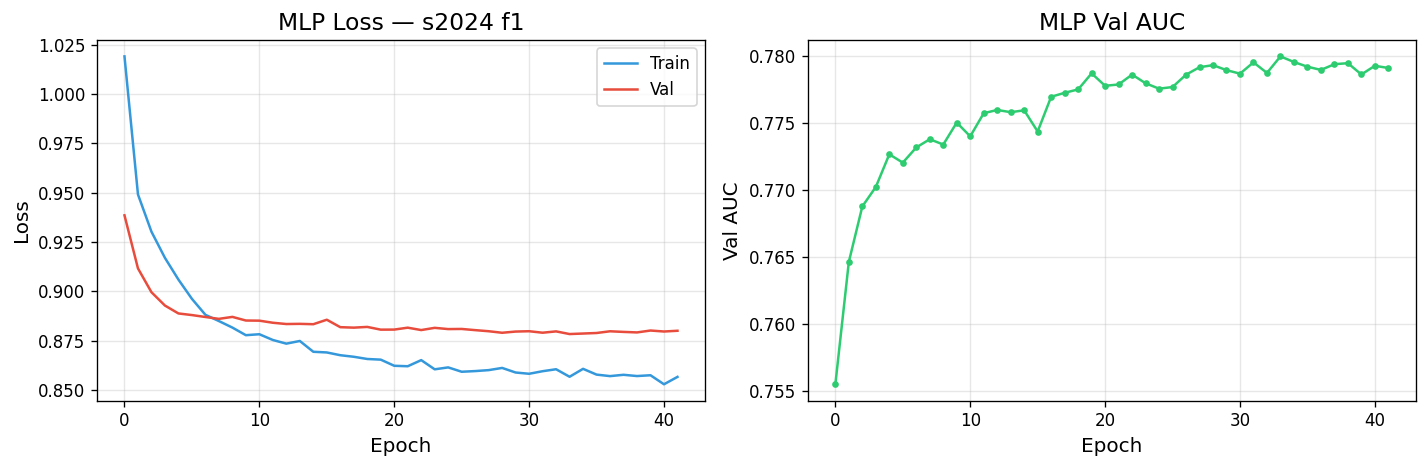

  Figure saved → mlp_training_s2024_f1.png & .pdf

  Running: TabNet_s2024_f1  (device=cuda:1)

Early stopping occurred at epoch 24 with best_epoch = 14 and best_val_auc = 0.77219


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s2024_f1.zip
  TabNet trained in 23.1s

  Running: LogisticRegression_s2024_f2  (device=cpu)
  Logistic Regression trained in 1.5s

  Running: CatBoost_s2024_f2  (device=cpu)
  CatBoost trained in 11.0s (best_iter=339)

  Running: LightGBM_s2024_f2  (device=cpu)
  Tree trained in 0.2s (best_iter=12)

  Running: MLP_s2024_f2  (device=cuda:0)
    Early stop epoch 21 (best AUC=0.7838)
  MLP trained in 6.4s (best AUC=0.7838)


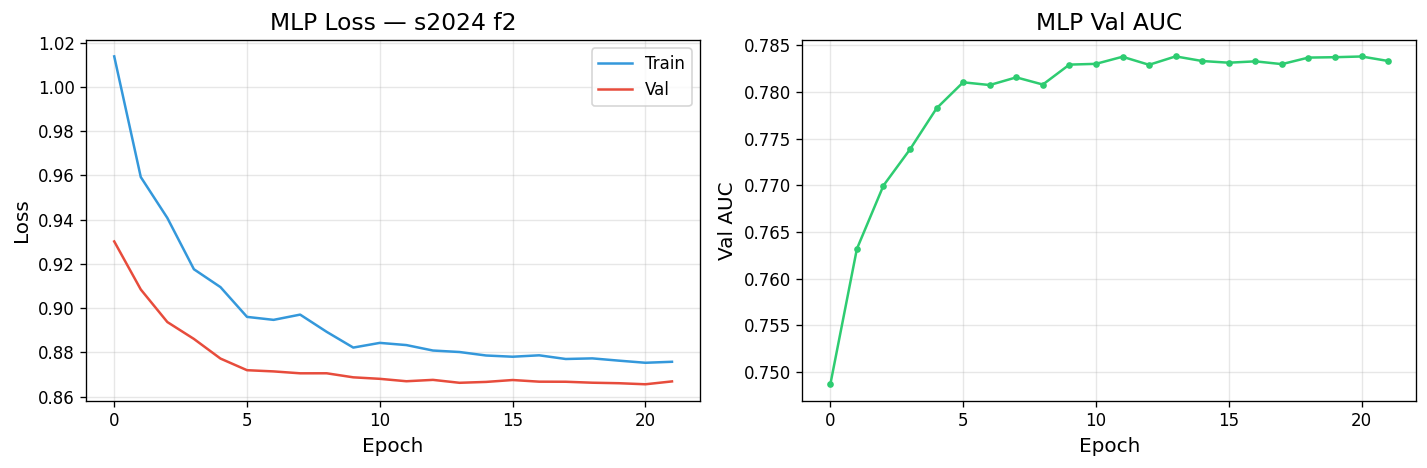

  Figure saved → mlp_training_s2024_f2.png & .pdf

  Running: TabNet_s2024_f2  (device=cuda:1)

Early stopping occurred at epoch 30 with best_epoch = 20 and best_val_auc = 0.77183


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s2024_f2.zip
  TabNet trained in 28.8s

  Running: LogisticRegression_s2024_f3  (device=cpu)
  Logistic Regression trained in 1.7s

  Running: CatBoost_s2024_f3  (device=cpu)
  CatBoost trained in 10.1s (best_iter=317)

  Running: LightGBM_s2024_f3  (device=cpu)
  Tree trained in 0.3s (best_iter=12)

  Running: MLP_s2024_f3  (device=cuda:0)
    Early stop epoch 46 (best AUC=0.7825)
  MLP trained in 12.7s (best AUC=0.7825)


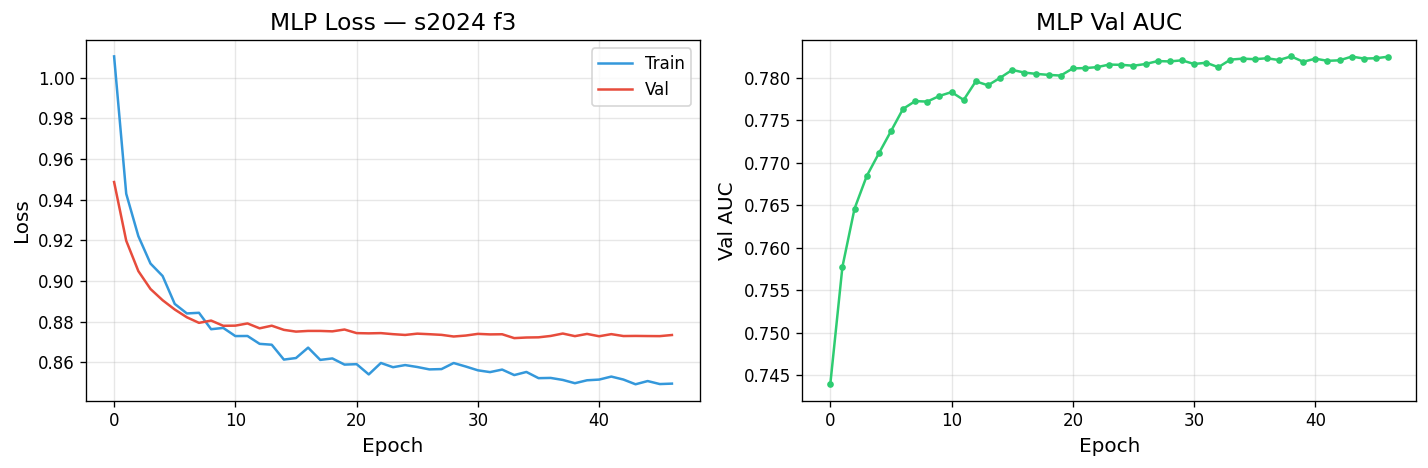

  Figure saved → mlp_training_s2024_f3.png & .pdf

  Running: TabNet_s2024_f3  (device=cuda:1)

Early stopping occurred at epoch 50 with best_epoch = 40 and best_val_auc = 0.77713


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s2024_f3.zip
  TabNet trained in 46.5s

  Running: LogisticRegression_s2024_f4  (device=cpu)
  Logistic Regression trained in 1.3s

  Running: CatBoost_s2024_f4  (device=cpu)
  CatBoost trained in 8.6s (best_iter=262)

  Running: LightGBM_s2024_f4  (device=cpu)
  Tree trained in 0.2s (best_iter=12)

  Running: MLP_s2024_f4  (device=cuda:0)
    Early stop epoch 39 (best AUC=0.7738)
  MLP trained in 11.2s (best AUC=0.7738)


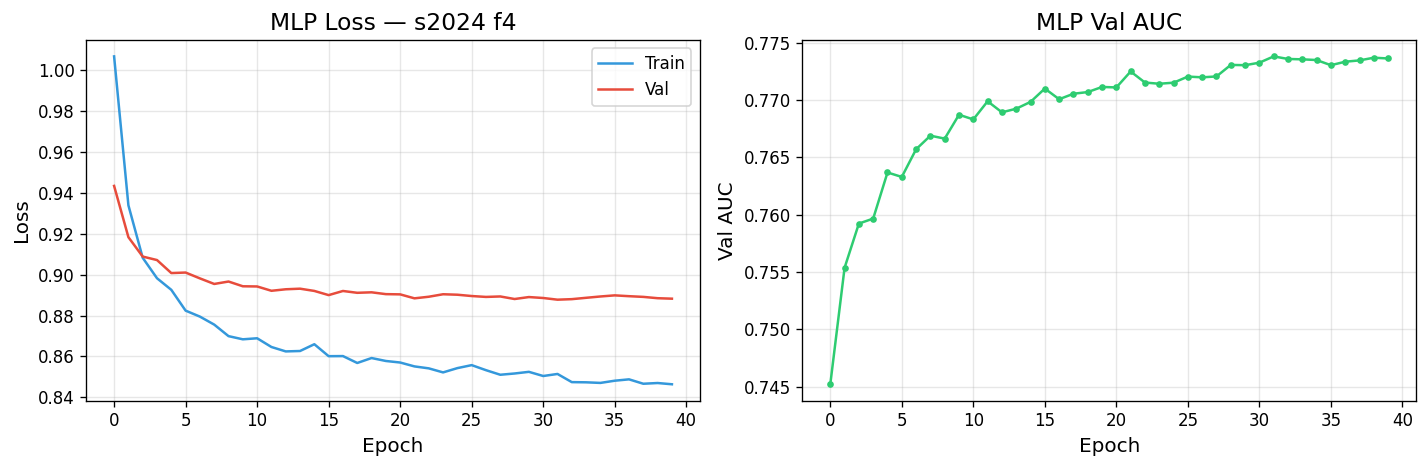

  Figure saved → mlp_training_s2024_f4.png & .pdf

  Running: TabNet_s2024_f4  (device=cuda:1)
  CatBoost trained in 7.8s (best_iter=235)

  Running: LightGBM_s7_f2  (device=cpu)
  Tree trained in 0.2s (best_iter=12)

  Running: MLP_s7_f2  (device=cuda:0)
    Early stop epoch 45 (best AUC=0.7818)
  MLP trained in 12.9s (best AUC=0.7818)


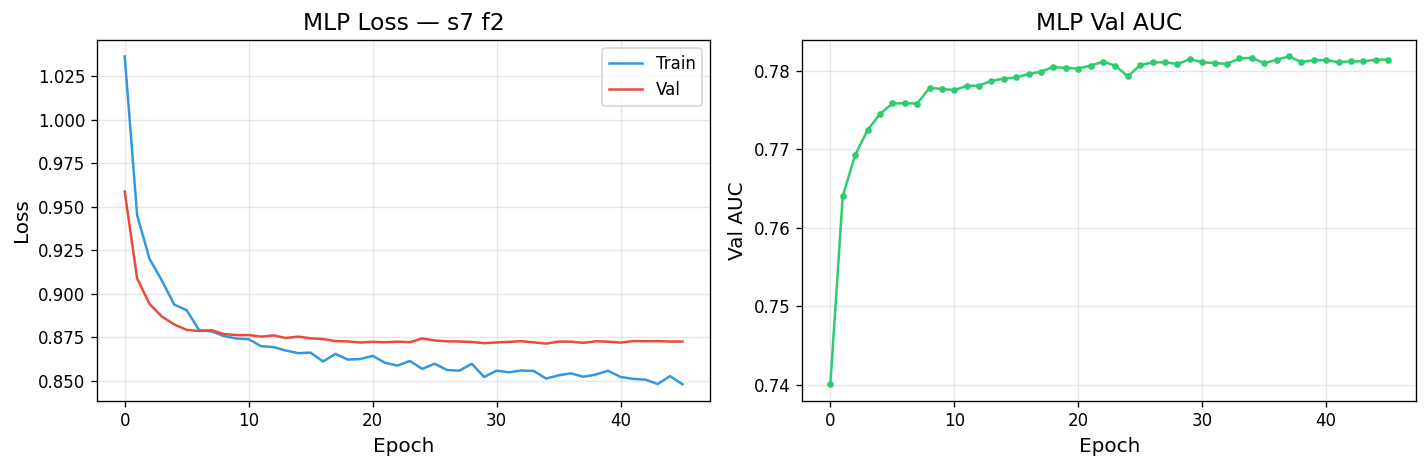

  Figure saved → mlp_training_s7_f2.png & .pdf

  Running: TabNet_s7_f2  (device=cuda:1)

Early stopping occurred at epoch 19 with best_epoch = 9 and best_val_auc = 0.77464


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s7_f2.zip
  TabNet trained in 18.9s

  Running: LogisticRegression_s7_f3  (device=cpu)
  Logistic Regression trained in 1.4s

  Running: CatBoost_s7_f3  (device=cpu)
  CatBoost trained in 12.4s (best_iter=403)

  Running: LightGBM_s7_f3  (device=cpu)
  Tree trained in 0.2s (best_iter=12)

  Running: MLP_s7_f3  (device=cuda:0)
    Early stop epoch 29 (best AUC=0.7812)
  MLP trained in 8.3s (best AUC=0.7812)


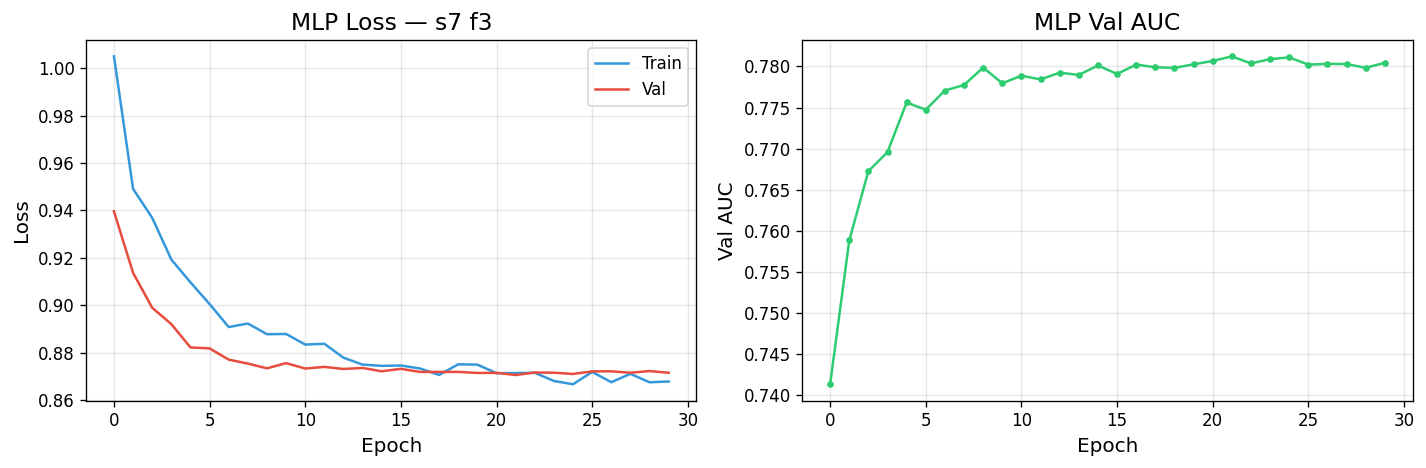

  Figure saved → mlp_training_s7_f3.png & .pdf

  Running: TabNet_s7_f3  (device=cuda:1)

Early stopping occurred at epoch 32 with best_epoch = 22 and best_val_auc = 0.77442


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s7_f3.zip
  TabNet trained in 30.9s

  Running: LogisticRegression_s7_f4  (device=cpu)
  Logistic Regression trained in 1.8s

  Running: CatBoost_s7_f4  (device=cpu)
  CatBoost trained in 14.6s (best_iter=475)

  Running: LightGBM_s7_f4  (device=cpu)
  Tree trained in 0.2s (best_iter=10)

  Running: MLP_s7_f4  (device=cuda:0)
    Early stop epoch 31 (best AUC=0.7751)
  MLP trained in 8.8s (best AUC=0.7751)


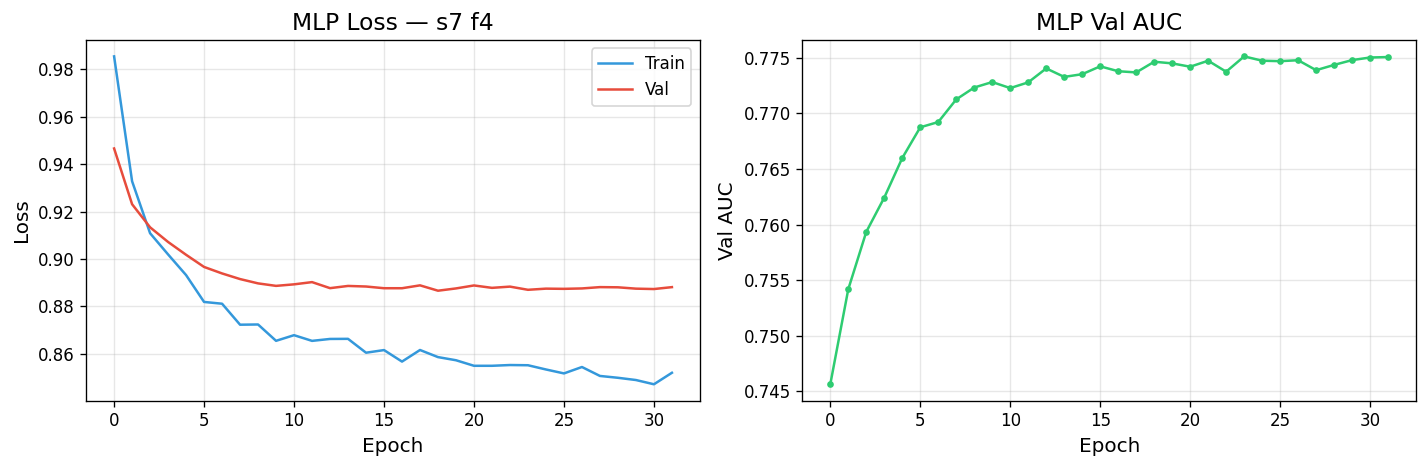

  Figure saved → mlp_training_s7_f4.png & .pdf

  Running: TabNet_s7_f4  (device=cuda:1)

Early stopping occurred at epoch 29 with best_epoch = 19 and best_val_auc = 0.76521


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at /kaggle/working/credit_xai_outputs/models/tabnet_s7_f4.zip
  TabNet trained in 28.2s

Experiment complete: 75/75 tasks in 870s


  Figure saved → mlp_training_s42_f0.png & .pdf

  Running: TabNet_s42_f0  (device=cpu)


Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.78364


C:\Users\huzaifakhallid\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at credit_xai_outputs\models\tabnet_s42_f0.zip
  TabNet trained in 17.1s



Experiment complete: 5/5 tasks in 81s


In [108]:
# ──────────────────────────────────────────────────────────────
# 12‑C  Experiment loop
# ──────────────────────────────────────────────────────────────
MODEL_NAMES = ["LightGBM", "MLP", "TabNet"]
if getattr(CFG, "use_logistic", False):
    MODEL_NAMES.insert(0, "LogisticRegression")
if getattr(CFG, "use_catboost", False) and HAS_CATBOOST:
    MODEL_NAMES.insert(1, "CatBoost")
all_results = []

total_tasks = len(fold_tasks) * len(MODEL_NAMES)
print(f"\nTotal tasks: {total_tasks} ({len(fold_tasks)} folds × {len(MODEL_NAMES)} models)")
print(f"Running in {CFG.run_mode.upper()} mode\n")

exp_t0 = time.time()

for ft_idx, ft in enumerate(fold_tasks):
    for mn in MODEL_NAMES:
        try:
            res = run_single_task(ft, mn, DEVICE_MAP.get(mn, "cpu"))
            all_results.append(res)
        except Exception as e:
            print(f"  ✗ FAILED: {mn} s{ft['seed']} f{ft['fold']}: {e}")
            import traceback; traceback.print_exc()

        # Memory cleanup
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

exp_runtime = time.time() - exp_t0
print(f"\n{'='*60}")
print(f"Experiment complete: {len(all_results)}/{total_tasks} tasks in {exp_runtime:.0f}s")
print(f"{'='*60}")

## ***Section 13 — Aggregate Predictive Results***

### ***What this cell does***
1. Aggregates per‑fold/seed metrics into **mean ± std** summaries for each model.
2. Runs **paired statistical tests** (Wilcoxon signed‑rank / paired t‑test) across matched
   folds to determine whether performance differences are statistically significant.
3. Generates publication‑ready visualisations: ROC curves, PR curves, confusion matrices,
   and a metric comparison bar chart with error bars.

### ***Why it is needed***
Aggregated metrics with variance estimates and statistical significance tests are the
**minimum evidence standard** for any ML research paper.  Without them, a single lucky fold
can produce misleading conclusions.  Paired tests (matching by fold/seed) control for
data‑split variance, providing more powerful statistical evidence than unpaired tests.

### ***Expected output***
- `predictive_metrics_all.csv` — per‑task raw metrics
- `predictive_metrics_summary.csv` — mean ± std per model
- `statistical_tests.csv` — pairwise p‑values and effect sizes
- ROC curves, PR curves, confusion matrices, and metric comparison bar chart figures

In [109]:
# ──────────────────────────────────────────────────────────────
# 13‑A  Aggregate metrics table
# ──────────────────────────────────────────────────────────────
metrics_cols = ["test_roc_auc", "test_pr_auc", "test_f1", "test_precision",
                "test_recall", "test_balanced_acc", "test_mcc", "test_brier"]
id_cols = ["seed", "fold", "model_name", "threshold", "runtime"]

results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")}
                           for r in all_results])
results_df.to_csv(OUTPUT / "metrics" / "predictive_metrics_all.csv", index=False)

# Summary: mean ± std
summary_rows = []
for mn in MODEL_NAMES:
    subset = results_df[results_df["model_name"] == mn]
    row = {"model": mn}
    for col in metrics_cols:
        if col in subset.columns:
            row[f"{col}_mean"] = subset[col].mean()
            row[f"{col}_std"]  = subset[col].std()
    row["runtime_mean"] = subset["runtime"].mean()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT / "metrics" / "predictive_metrics_summary.csv", index=False)

# Pretty display
display_cols = ["model"]
for m in ["test_roc_auc", "test_pr_auc", "test_f1", "test_recall", "test_brier"]:
    mc = f"{m}_mean"
    sc = f"{m}_std"
    if mc in summary_df.columns:
        display_cols.extend([mc, sc])

print("\n📊 Predictive Performance Summary:")
print(summary_df[display_cols].to_string(index=False, float_format="%.4f"))


📊 Predictive Performance Summary:
             model  test_roc_auc_mean  test_roc_auc_std  test_pr_auc_mean  test_pr_auc_std  test_f1_mean  test_f1_std  test_recall_mean  test_recall_std  test_brier_mean  test_brier_std
LogisticRegression             0.7741            0.0076            0.5407           0.0124        0.5367       0.0120            0.5661           0.0310           0.1838          0.0021
          CatBoost             0.7890            0.0095            0.5666           0.0150        0.5481       0.0129            0.5788           0.0337           0.1770          0.0028
          LightGBM             0.7825            0.0104            0.5555           0.0147        0.5421       0.0123            0.5639           0.0390           0.1537          0.0013
               MLP             0.7828            0.0088            0.5563           0.0146        0.5405       0.0118            0.5567           0.0347           0.1809          0.0025
            TabNet             0.77

In [110]:
# ──────────────────────────────────────────────────────────────
# 13‑B  Statistical tests
# ──────────────────────────────────────────────────────────────
stat_results = []
metric_label_map = {
    "test_roc_auc": "ROC-AUC",
    "test_pr_auc": "PR-AUC",
    "test_f1": "F1",
}
model_pairs = [
    ("LightGBM", "MLP"), ("LightGBM", "TabNet"), ("MLP", "TabNet"),
    ("CatBoost", "LightGBM"), ("CatBoost", "MLP"),
    ("CatBoost", "TabNet"), ("CatBoost", "LogisticRegression")
]

def get_paired_metric_frame(results_frame, model_a, model_b, metric_col):
    cols = ["seed", "fold", metric_col]
    left = results_frame.loc[results_frame["model_name"] == model_a, cols].rename(
        columns={metric_col: "value_A"}
    )
    right = results_frame.loc[results_frame["model_name"] == model_b, cols].rename(
        columns={metric_col: "value_B"}
    )
    paired = left.merge(right, on=["seed", "fold"], how="inner").sort_values(["seed", "fold"])
    return paired.reset_index(drop=True)

for metric_col, metric_label in metric_label_map.items():
    if metric_col not in results_df.columns:
        continue
    for model_a, model_b in model_pairs:
        paired = get_paired_metric_frame(results_df, model_a, model_b, metric_col)
        values_a = paired["value_A"].to_numpy(dtype=float) if not paired.empty else np.array([])
        values_b = paired["value_B"].to_numpy(dtype=float) if not paired.empty else np.array([])
        diffs = values_a - values_b
        record = {
            "metric": metric_label,
            "metric_col": metric_col,
            "model_A": model_a,
            "model_B": model_b,
            "n_pairs": int(len(paired)),
            "mean_A": float(values_a.mean()) if len(values_a) else np.nan,
            "mean_B": float(values_b.mean()) if len(values_b) else np.nan,
            "mean_diff": float(diffs.mean()) if len(diffs) else np.nan,
            "median_diff": float(np.median(diffs)) if len(diffs) else np.nan,
            "effect_direction": "tie" if len(diffs) == 0 or np.isclose(diffs.mean(), 0.0) else ("A > B" if diffs.mean() > 0 else "B > A"),
        }

        if len(diffs) < 2:
            record.update({
                "test": "insufficient_data",
                "statistic": np.nan,
                "p_value": np.nan,
                "cohens_d": np.nan,
                "status": "underpowered_debug_or_missing_pairs",
            })
            stat_results.append(record)
            continue

        try:
            if len(diffs) >= 6:
                stat, pval = wilcoxon(values_a, values_b, alternative="two-sided")
                test_name = "wilcoxon"
            else:
                stat, pval = ttest_rel(values_a, values_b)
                test_name = "paired_t"
            effect_size = diffs.mean() / (diffs.std(ddof=1) + 1e-8)
            status = "ok"
        except Exception as exc:
            stat, pval, test_name, effect_size = np.nan, np.nan, "error", np.nan
            status = f"error: {type(exc).__name__}"

        record.update({
            "test": test_name,
            "statistic": stat,
            "p_value": pval,
            "cohens_d": effect_size,
            "status": status,
        })
        stat_results.append(record)

stat_df = pd.DataFrame(stat_results)
stat_df.to_csv(OUTPUT / "metrics" / "statistical_tests.csv", index=False)

catboost_pairs = {
    ("CatBoost", "LightGBM"),
    ("CatBoost", "MLP"),
    ("CatBoost", "TabNet"),
    ("CatBoost", "LogisticRegression"),
}
catboost_stat_df = stat_df[
    stat_df.apply(lambda row: (row["model_A"], row["model_B"]) in catboost_pairs, axis=1)
].copy()
catboost_stat_df.to_csv(OUTPUT / "metrics" / "catboost_statistical_tests.csv", index=False)

print("\n📊 Statistical Tests:")
print(stat_df.to_string(index=False, float_format="%.4f"))


📊 Statistical Tests:
 metric   metric_col  model_A            model_B  n_pairs  mean_A  mean_B  mean_diff  median_diff effect_direction     test  statistic  p_value  cohens_d status
ROC-AUC test_roc_auc LightGBM                MLP       15  0.7825  0.7828    -0.0003      -0.0001            B > A wilcoxon    59.0000   0.9780   -0.0716     ok
ROC-AUC test_roc_auc LightGBM             TabNet       15  0.7825  0.7731     0.0094       0.0093            A > B wilcoxon     0.0000   0.0001    1.9816     ok
ROC-AUC test_roc_auc      MLP             TabNet       15  0.7828  0.7731     0.0096       0.0097            A > B wilcoxon     0.0000   0.0001    3.2434     ok
ROC-AUC test_roc_auc CatBoost           LightGBM       15  0.7890  0.7825     0.0065       0.0071            A > B wilcoxon     0.0000   0.0001    3.4028     ok
ROC-AUC test_roc_auc CatBoost                MLP       15  0.7890  0.7828     0.0063       0.0065            A > B wilcoxon     1.0000   0.0001    2.0879     ok
ROC-AUC test

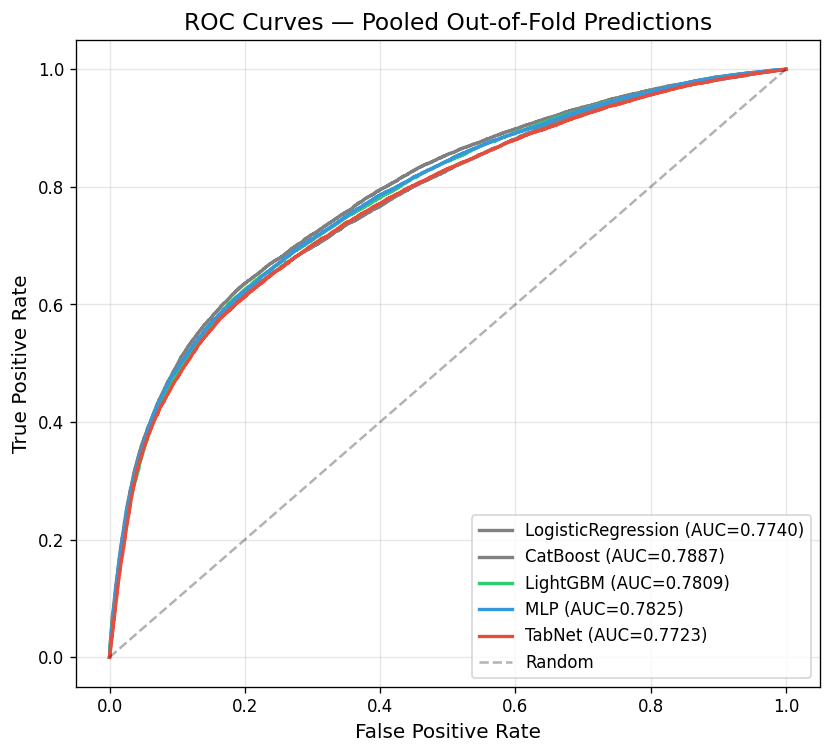

  Figure saved → roc_curves.png & .pdf


In [111]:
# ──────────────────────────────────────────────────────────────
# 13‑C  ROC curves (pooled out‑of‑fold)
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
for mn in MODEL_NAMES:
    mn_results = [r for r in all_results if r["model_name"] == mn]
    if not mn_results:
        continue
    # Pool predictions across folds/seeds
    y_true_all = np.concatenate([
        pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")["y_true"].values
        for r in mn_results
    ])
    y_prob_all = np.concatenate([
        pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")["y_prob"].values
        for r in mn_results
    ])
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
    auc_val = roc_auc_score(y_true_all, y_prob_all)
    ax.plot(fpr, tpr, label=f"{mn} (AUC={auc_val:.4f})",
            color=MODEL_COLORS.get(mn, "gray"), linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Pooled Out‑of‑Fold Predictions")
ax.legend(loc="lower right")
save_fig(fig, "roc_curves", "figures/models")

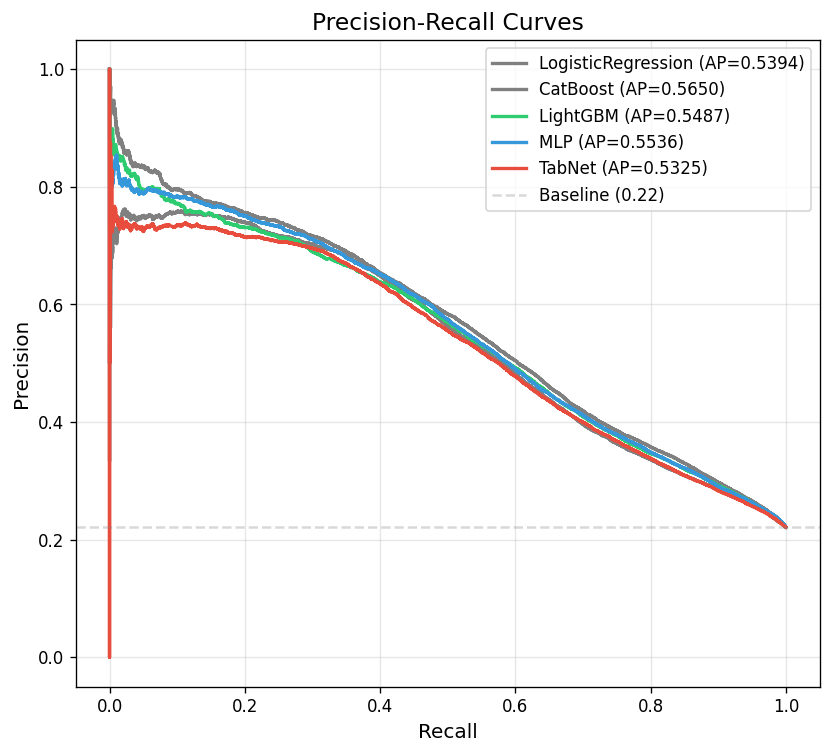

  Figure saved → pr_curves.png & .pdf


In [112]:
# ──────────────────────────────────────────────────────────────
# 13‑D  PR curves
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
for mn in MODEL_NAMES:
    mn_results = [r for r in all_results if r["model_name"] == mn]
    if not mn_results:
        continue
    y_true_all = np.concatenate([
        pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")["y_true"].values
        for r in mn_results
    ])
    y_prob_all = np.concatenate([
        pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")["y_prob"].values
        for r in mn_results
    ])
    prec, rec, _ = precision_recall_curve(y_true_all, y_prob_all)
    ap = average_precision_score(y_true_all, y_prob_all)
    ax.plot(rec, prec, label=f"{mn} (AP={ap:.4f})",
            color=MODEL_COLORS.get(mn, "gray"), linewidth=2)

baseline = y_true_all.mean()
ax.axhline(baseline, color="gray", linestyle="--", alpha=0.3, label=f"Baseline ({baseline:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision‑Recall Curves")
ax.legend(loc="upper right")
save_fig(fig, "pr_curves", "figures/models")

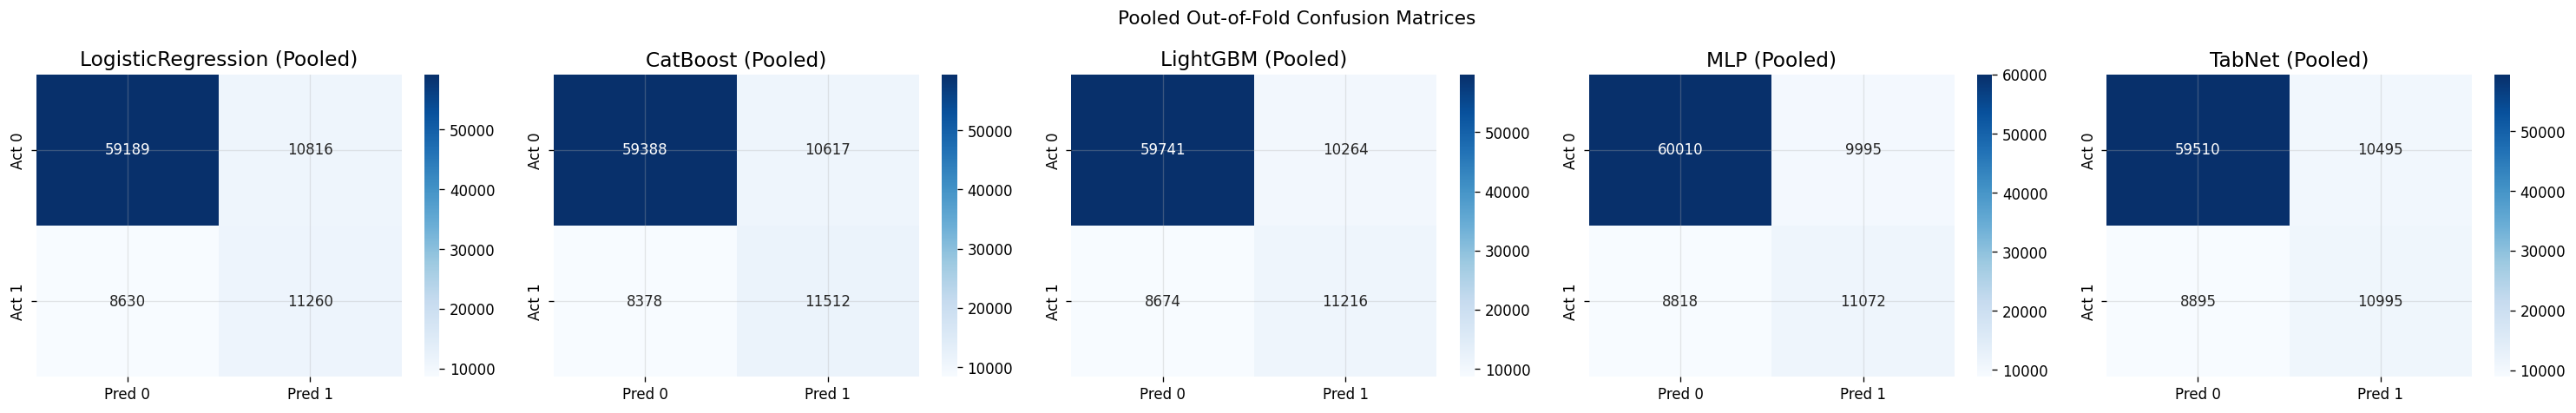

  Figure saved → pooled_confusion_matrices.png & .pdf


In [113]:
# ──────────────────────────────────────────────────────────────
# 13‑E  Confusion matrices (Pooled out-of-fold)
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(5 * len(MODEL_NAMES), 4))
if len(MODEL_NAMES) == 1:
    axes = [axes]

for ax, mn in zip(axes, MODEL_NAMES):
    mn_results = [r for r in all_results if r["model_name"] == mn]
    if not mn_results: continue
    
    y_true_all = np.concatenate([
        pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")["y_true"].values
        for r in mn_results
    ])
    y_pred_all = np.concatenate([
        pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")["y_pred"].values
        for r in mn_results
    ])
    
    cm = confusion_matrix(y_true_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["Act 0", "Act 1"])
    ax.set_title(f"{mn} (Pooled)")

fig.suptitle("Pooled Out-of-Fold Confusion Matrices", fontsize=13)
fig.tight_layout()
save_fig(fig, "pooled_confusion_matrices", "figures/models")

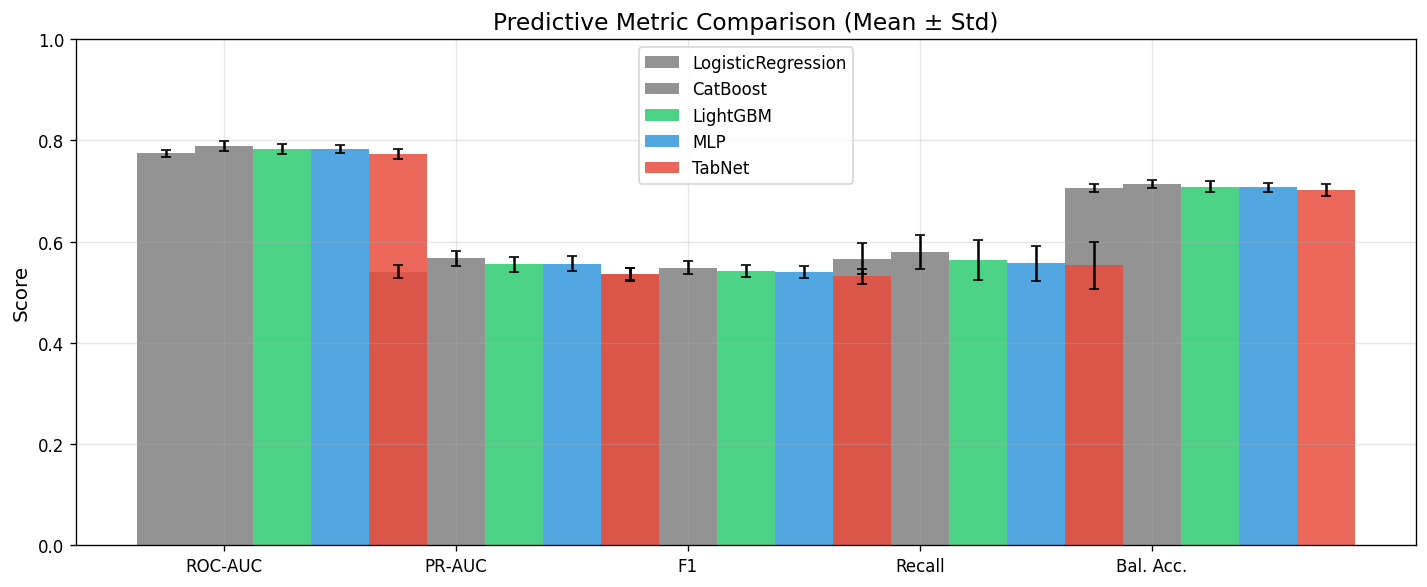

  Figure saved → metric_comparison_bar.png & .pdf
✓ Predictive results aggregated and plotted.


In [114]:
# ──────────────────────────────────────────────────────────────
# 13‑F  Metric comparison bar chart
# ──────────────────────────────────────────────────────────────
plot_metrics = ["test_roc_auc", "test_pr_auc", "test_f1", "test_recall", "test_balanced_acc"]
plot_labels  = ["ROC‑AUC", "PR‑AUC", "F1", "Recall", "Bal. Acc."]

x = np.arange(len(plot_metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, mn in enumerate(MODEL_NAMES):
    means = [summary_df.loc[summary_df["model"]==mn, f"{m}_mean"].values[0]
             if f"{m}_mean" in summary_df.columns and not summary_df[summary_df["model"]==mn].empty else 0 for m in plot_metrics]
    stds  = [summary_df.loc[summary_df["model"]==mn, f"{m}_std"].values[0]
             if f"{m}_std" in summary_df.columns and not summary_df[summary_df["model"]==mn].empty else 0 for m in plot_metrics]
    ax.bar(x + i*width, means, width, label=mn, yerr=stds,
           color=MODEL_COLORS.get(mn, "gray"), capsize=3, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(plot_labels)
ax.set_ylabel("Score")
ax.set_title("Predictive Metric Comparison (Mean ± Std)")
ax.legend()
ax.set_ylim(0, 1.0)
fig.tight_layout()
save_fig(fig, "metric_comparison_bar", "figures/models")
print("✓ Predictive results aggregated and plotted.")

## ***Section 13.1 — Calibration Analysis***

### ***What this cell does***
Calculates the Expected Calibration Error (ECE) and plots reliability diagrams (calibration curves) for each model. Includes Platt and Isotonic calibration results for the MLP if configured.

### ***Why it is needed***
Calibration is critical for credit risk. A well-calibrated model produces probabilities that match real-world default rates. ECE and Brier score assess this property.

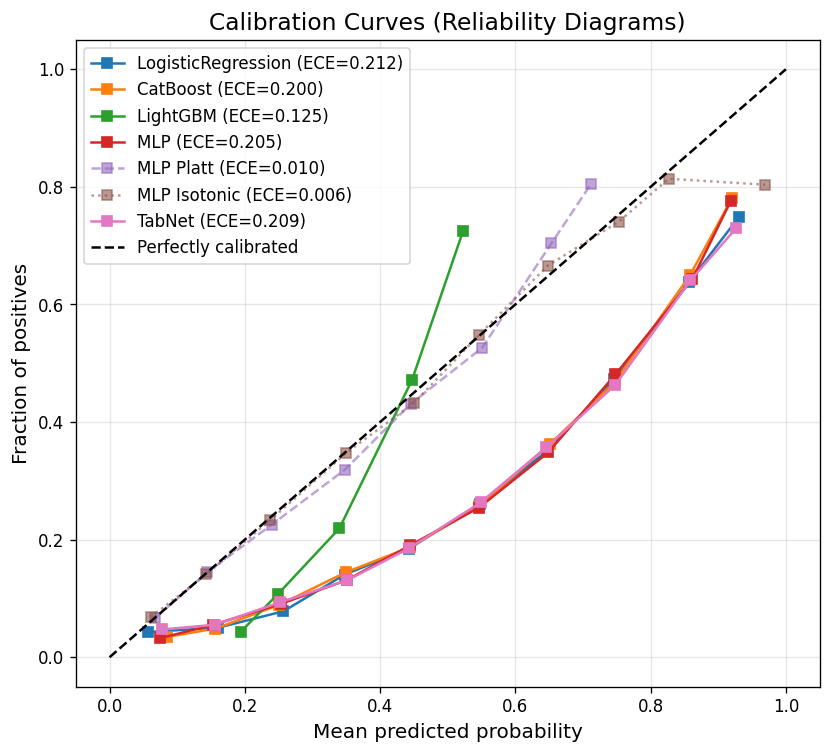

  Figure saved → calibration_curve.png & .pdf

📊 Calibration Summary:
        model_name  brier_score    ece
LogisticRegression       0.1838 0.2121
          CatBoost       0.1770 0.2000
          LightGBM       0.1537 0.1250
               MLP       0.1809 0.2048
       MLP (Platt)       0.1347 0.0104
    MLP (Isotonic)       0.1348 0.0059
            TabNet       0.1846 0.2092


In [115]:
# ──────────────────────────────────────────────────────────────
# 13.1‑A  Calibration metrics and curves
# ──────────────────────────────────────────────────────────────
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0., 1., n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    
    bin_sums = np.bincount(binids, weights=y_prob, minlength=len(bins))
    bin_true = np.bincount(binids, weights=y_true, minlength=len(bins))
    bin_total = np.bincount(binids, minlength=len(bins))
    
    nonzero = bin_total != 0
    prob_true = bin_true[nonzero] / bin_total[nonzero]
    prob_pred = bin_sums[nonzero] / bin_total[nonzero]
    
    ece = np.sum(np.abs(prob_true - prob_pred) * (bin_total[nonzero] / len(y_true)))
    
    # Return ECE and bin stats
    bins_df = pd.DataFrame({
        "mean_predicted_prob": prob_pred,
        "true_fraction": prob_true,
        "count": bin_total[nonzero]
    })
    return ece, bins_df

calibration_records = []
fig, ax = plt.subplots(figsize=(8, 7))

for mn in MODEL_NAMES:
    mn_results = [r for r in all_results if r["model_name"] == mn]
    if not mn_results: continue
    
    y_true_all = np.concatenate([
        pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")["y_true"].values
        for r in mn_results
    ])
    y_prob_all = np.concatenate([
        pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")["y_prob"].values
        for r in mn_results
    ])
    
    brier = brier_score_loss(y_true_all, y_prob_all)
    ece, bins_df = expected_calibration_error(y_true_all, y_prob_all)
    bins_df["model"] = mn
    
    calibration_records.append({
        "model_name": mn, "brier_score": brier, "ece": ece
    })
    
    fraction_of_positives, mean_predicted_value = calibration_curve(y_true_all, y_prob_all, n_bins=10)
    ax.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"{mn} (ECE={ece:.3f})")
    
    if mn == "MLP" and getattr(CFG, "use_calibration", False):
        try:
            y_prob_platt = np.concatenate([
                pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")["y_test_prob_platt"].values
                for r in mn_results
            ])
            y_prob_iso = np.concatenate([
                pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")["y_test_prob_iso"].values
                for r in mn_results
            ])
            
            platt_brier = brier_score_loss(y_true_all, y_prob_platt)
            platt_ece, _ = expected_calibration_error(y_true_all, y_prob_platt)
            iso_brier = brier_score_loss(y_true_all, y_prob_iso)
            iso_ece, _ = expected_calibration_error(y_true_all, y_prob_iso)
            
            calibration_records.append({"model_name": "MLP (Platt)", "brier_score": platt_brier, "ece": platt_ece})
            calibration_records.append({"model_name": "MLP (Isotonic)", "brier_score": iso_brier, "ece": iso_ece})
            
            fop_platt, mpv_platt = calibration_curve(y_true_all, y_prob_platt, n_bins=10)
            ax.plot(mpv_platt, fop_platt, "s--", alpha=0.6, label=f"MLP Platt (ECE={platt_ece:.3f})")
            
            fop_iso, mpv_iso = calibration_curve(y_true_all, y_prob_iso, n_bins=10)
            ax.plot(mpv_iso, fop_iso, "s:", alpha=0.6, label=f"MLP Isotonic (ECE={iso_ece:.3f})")
        except KeyError:
            pass # No platt/iso predictions saved

ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.set_ylabel("Fraction of positives")
ax.set_xlabel("Mean predicted probability")
ax.set_title("Calibration Curves (Reliability Diagrams)")
ax.legend(loc="upper left")
save_fig(fig, "calibration_curve", "figures/models")

calib_df = pd.DataFrame(calibration_records)
calib_df.to_csv(OUTPUT / "metrics" / "calibration_summary.csv", index=False)
print("\n📊 Calibration Summary:")
print(calib_df.to_string(index=False, float_format="%.4f"))

## ***Section 13.2 — Cost-Sensitive Analysis***

### ***What this cell does***
Evaluates models under three financial cost scenarios by varying the false positive (FP) and false negative (FN) cost ratios. Finds the optimal classification threshold for each scenario.

### ***Why it is needed***
A bank's true objective isn't AUC; it's minimizing financial loss. The best model changes depending on whether the institution prioritizes avoiding defaults (conservative) or avoiding unnecessary rejection of good customers (growth).

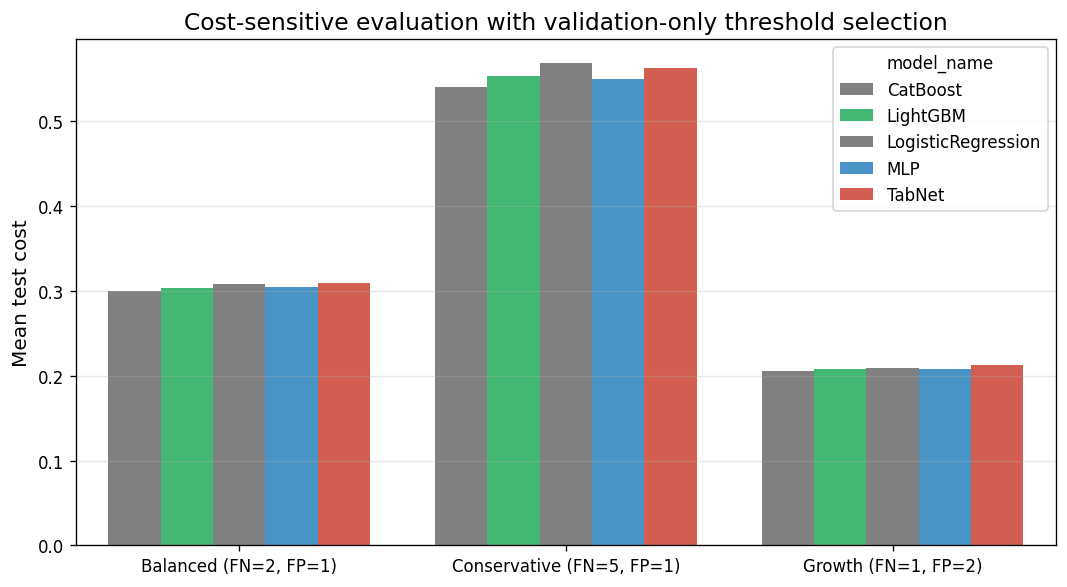

  Figure saved → cost_sensitive_validation_thresholds.png & .pdf

📊 Cost-Sensitive Summary (Validation Thresholds):
scenario            Balanced (FN=2, FP=1)  Conservative (FN=5, FP=1)  Growth (FN=1, FP=2)
model_name                                                                               
CatBoost                           0.3000                     0.5402               0.2059
LightGBM                           0.3038                     0.5541               0.2085
LogisticRegression                 0.3079                     0.5689               0.2094
MLP                                0.3044                     0.5504               0.2078
TabNet                             0.3099                     0.5633               0.2122


In [116]:
# ──────────────────────────────────────────────────────────────
# 13.2‑A  Cost-Sensitive Analysis
# ──────────────────────────────────────────────────────────────
def tune_cost_sensitive_threshold(y_val_true, y_val_prob, fn_cost, fp_cost):
    thresholds = np.linspace(0.05, 0.95, 91)
    costs = []

    for t in thresholds:
        pred = (y_val_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val_true, pred, labels=[0, 1]).ravel()
        total_cost = (fn * fn_cost) + (fp * fp_cost)
        avg_cost = total_cost / len(y_val_true)
        costs.append((t, avg_cost))

    costs.sort(key=lambda x: (x[1], x[0]))
    return costs[0]

scenarios = {
    "Conservative (FN=5, FP=1)": (5, 1),
    "Balanced (FN=2, FP=1)": (2, 1),
    "Growth (FN=1, FP=2)": (1, 2)
}

cost_run_records = []
for mn in MODEL_NAMES:
    mn_results = [r for r in all_results if r["model_name"] == mn]
    if not mn_results:
        continue

    for res in mn_results:
        val_path = OUTPUT / "metrics" / f"val_predictions_{mn}_s{res['seed']}_f{res['fold']}.csv"
        test_path = OUTPUT / "metrics" / f"predictions_{mn}_s{res['seed']}_f{res['fold']}.csv"
        val_preds = pd.read_csv(val_path)
        test_preds = pd.read_csv(test_path)

        for sc_name, (fnc, fpc) in scenarios.items():
            best_t, val_cost = tune_cost_sensitive_threshold(
                val_preds["y_true"].values,
                val_preds["y_prob"].values,
                fnc,
                fpc,
            )
            test_pred = (test_preds["y_prob"].values >= best_t).astype(int)
            tn, fp, fn, tp = confusion_matrix(
                test_preds["y_true"].values,
                test_pred,
                labels=[0, 1]
            ).ravel()
            test_cost = ((fn * fnc) + (fp * fpc)) / len(test_preds)

            cost_run_records.append({
                "model_name": mn,
                "seed": res["seed"],
                "fold": res["fold"],
                "scenario": sc_name,
                "fn_cost": fnc,
                "fp_cost": fpc,
                "best_threshold": best_t,
                "validation_avg_cost": val_cost,
                "test_avg_cost": test_cost,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
            })

if cost_run_records:
    cost_runs_df = pd.DataFrame(cost_run_records)
    cost_runs_df.to_csv(
        OUTPUT / "metrics" / "cost_sensitive_per_run_validation_thresholds.csv",
        index=False,
    )

    cost_df = cost_runs_df.groupby(["model_name", "scenario", "fn_cost", "fp_cost"]).agg(
        n_runs=("best_threshold", "count"),
        best_threshold_mean=("best_threshold", "mean"),
        best_threshold_std=("best_threshold", "std"),
        validation_avg_cost_mean=("validation_avg_cost", "mean"),
        validation_avg_cost_std=("validation_avg_cost", "std"),
        test_avg_cost_mean=("test_avg_cost", "mean"),
        test_avg_cost_std=("test_avg_cost", "std"),
    ).reset_index()
    cost_df.to_csv(OUTPUT / "metrics" / "cost_sensitive_summary_validation_thresholds.csv", index=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(
        data=cost_df,
        x="scenario",
        y="test_avg_cost_mean",
        hue="model_name",
        ax=ax,
        palette=[MODEL_COLORS.get(mn, "gray") for mn in cost_df["model_name"].unique()],
    )
    ax.set_ylabel("Mean test cost")
    ax.set_xlabel("")
    ax.set_title("Cost-sensitive evaluation with validation-only threshold selection")
    fig.tight_layout()
    save_fig(fig, "cost_sensitive_validation_thresholds", "figures/models")

    print("\n📊 Cost-Sensitive Summary (Validation Thresholds):")
    print(
        cost_df.pivot(index="model_name", columns="scenario", values="test_avg_cost_mean")
        .to_string(float_format="%.4f")
    )

## ***Section 14 — Explanation Sample Selection***

### ***What this cell does***
Selects a **stratified random subset** of test instances for explanation evaluation.

### ***Why it is needed***
Running SHAP / Integrated Gradients on all ~30,000 rows is:
- **Prohibitively slow**: IG with 32 interpolation steps on 30K rows would take hours.
- **Statistically unnecessary**: A stratified sample of 50–500 rows provides stable
  estimates of faithfulness and stability metrics.
- **Consistent across models**: All three model families are explained on the **same**
  sampled instances, enabling paired comparisons.

The sample is stratified by target class to ensure both default and non‑default cases
are represented proportionally.

### ***Expected output***
Sampled indices per fold, class balance of the explanation subset, and confirmation
that the sample size matches `CFG.explanation_samples`.

In [117]:
# ──────────────────────────────────────────────────────────────
# 14‑A  Select explanation samples
# ──────────────────────────────────────────────────────────────
def select_explanation_samples(y_test, n_samples, seed=42):
    """Stratified sampling from test set."""
    rng = np.random.RandomState(seed)
    idx_pos = np.where(y_test == 1)[0]
    idx_neg = np.where(y_test == 0)[0]

    n_pos = min(len(idx_pos), n_samples // 2)
    n_neg = min(len(idx_neg), n_samples - n_pos)

    chosen = np.concatenate([
        rng.choice(idx_pos, size=n_pos, replace=False),
        rng.choice(idx_neg, size=n_neg, replace=False),
    ])
    rng.shuffle(chosen)
    return chosen

print("✓ Explanation sample selector defined.")

✓ Explanation sample selector defined.


## ***Section 15 — TreeSHAP for LightGBM / XGBoost***

### ***What this cell does***
Computes **TreeSHAP** values for the sampled test instances using the tree model’s
exact polynomial‑time SHAP algorithm (Lundberg et al., 2020).

### ***Why it is needed***
TreeSHAP is the **gold‑standard** explanation method for tree ensembles:
- **Exact**: Computes true Shapley values in O(TLD²) time (T=trees, L=leaves, D=depth).
- **Consistent**: Satisfies the consistency axiom — increasing a feature’s contribution
  never decreases its attribution.
- **Fast**: Orders of magnitude faster than KernelSHAP.

TreeSHAP serves as our **explanation quality reference** — the benchmark against which
we compare MLP’s Integrated Gradients and TabNet’s intrinsic masks.

### ***Expected output***
- Per‑sample SHAP values matrix `[n_samples, n_features]`.
- Global mean |SHAP| importance ranking and bar plot.
- Explanation runtime.

In [118]:
# ──────────────────────────────────────────────────────────────
# 15‑A  TreeSHAP explanation
# ──────────────────────────────────────────────────────────────
def explain_tree_model(model, X_background, X_explain, feature_names):
    """Compute TreeSHAP values for sampled instances."""
    if not HAS_SHAP:
        print("  ⚠ SHAP not available, skipping TreeSHAP.")
        return None, None, 0.0

    t0 = time.time()
    # Use path-dependent TreeSHAP (no background data needed) to ensure exact additivity
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_explain, check_additivity=False)

    # Robust handling of SHAP returns
    if isinstance(shap_values, list):
        if len(shap_values) == 2:
            shap_values = shap_values[1]  # positive class for binary
        else:
            shap_values = shap_values[-1]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 3:
        # binary classification can sometimes return shape (n_samples, n_features, n_classes)
        if shap_values.shape[-1] == 2:
            shap_values = shap_values[:, :, 1]
        else:
            shap_values = shap_values[:, :, -1]

    if shap_values.ndim != 2:
        raise ValueError(f"Expected 2D SHAP matrix, got shape {shap_values.shape}")

    if shap_values.shape[1] != len(feature_names):
        raise ValueError(f"SHAP feature count {shap_values.shape[1]} does not match feature_names {len(feature_names)}.")

    runtime = time.time() - t0

    # Global importance: mean |SHAP|
    global_importance = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": global_importance,
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    return shap_values, importance_df, runtime

print("✓ TreeSHAP explainer defined.")

✓ TreeSHAP explainer defined.


## ***Section 16 — Integrated Gradients / GradientSHAP for MLP***

### ***What this cell does***
Computes **gradient‑based attributions** for the MLP using Facebook’s Captum library.

### ***Why it is needed***
For the **post‑hoc** arm of the study, we need feature‑level attributions that are
comparable in shape to TreeSHAP and TabNet masks.  **Integrated Gradients** (Sundararajan
et al., 2017) is chosen because it satisfies the **completeness axiom**:

> `Σ attributions = f(input) − f(baseline)`

This guarantees that attributions sum to the difference between the model’s prediction at
the input and at the baseline, providing a principled decomposition of the prediction.

**Implementation detail**: We attribute w.r.t. the MLP’s **combined post‑embedding
representation** (numerical features + categorical embeddings concatenated), then
aggregate embedding‑dimension attributions back to original features using the
**sum of absolute attributions per embedding block**.
This produces a `[n_samples, 23]` attribution matrix comparable to TreeSHAP and TabNet.

### ***Expected output***
- Per‑sample IG attributions (`[n_samples, n_features]`).
- Global mean |IG| importance ranking and bar plot.
- Explanation runtime.

In [119]:
# ──────────────────────────────────────────────────────────────
# 16‑A  MLP Captum wrapper
# ──────────────────────────────────────────────────────────────
class MLPCombinedWrapper(nn.Module):
    """Wrapper that takes the combined (num+emb) representation
    and outputs a scalar — required by Captum."""
    def __init__(self, mlp_model):
        super().__init__()
        self.mlp_layers = mlp_model.mlp

    def forward(self, x_combined):
        return self.mlp_layers(x_combined).squeeze(-1)


def explain_mlp_ig(model, X_num, X_cat, preprocessor, n_steps=32, device="cpu"):
    """Compute Integrated Gradients attributions aggregated to original features."""
    if not HAS_CAPTUM:
        print("  ⚠ Captum not available, skipping IG.")
        return None, None, 0.0

    t0 = time.time()
    dev = next(model.parameters()).device

    model.eval()
    x_num_t = torch.tensor(X_num, dtype=torch.float32, device=dev)
    x_cat_t = torch.tensor(X_cat, dtype=torch.long, device=dev)

    # Get combined representation
    with torch.no_grad():
        combined = model.get_combined_input(x_num_t, x_cat_t)

    # Baseline: training medians for num, zero embeddings for cat
    baseline_num = torch.tensor(
        preprocessor.num_medians_scaled, dtype=torch.float32, device=dev
    ).unsqueeze(0)

    # For categorical baseline: use mode categories
    mode_cats = []
    for c in preprocessor.cat_cols:
        mode_val = preprocessor.cat_modes[c]
        enc = preprocessor.cat_mappings[c].get(mode_val, 0)
        mode_cats.append(enc)
    baseline_cat = torch.tensor([mode_cats], dtype=torch.long, device=dev)

    with torch.no_grad():
        baseline_combined = model.get_combined_input(
            baseline_num, baseline_cat
        ).expand_as(combined)

    # Captum IG on the combined representation
    wrapper = MLPCombinedWrapper(model)
    ig = IntegratedGradients(wrapper)

    combined.requires_grad_(True)
    attrs = ig.attribute(
        combined,
        baselines=baseline_combined,
        n_steps=n_steps,
        internal_batch_size=min(64, len(combined)),
    ).detach().cpu().numpy()

    feature_names = preprocessor.num_cols + preprocessor.cat_cols

    # Aggregate back to original features
    n_num = len(preprocessor.num_cols)
    n_cat = len(preprocessor.cat_cols)
    feature_attrs = np.zeros((len(attrs), n_num + n_cat), dtype=np.float32)

    # Numerical features: 1-to-1
    feature_attrs[:, :n_num] = attrs[:, :n_num]

    # Categorical features: sum of absolute attributions (L1 norm) per embedding block
    offset = n_num
    for j, dim in enumerate(model.emb_dims):
        feature_attrs[:, n_num + j] = np.sum(np.abs(attrs[:, offset:offset + dim]), axis=1)
        offset += dim

    runtime = time.time() - t0
    
    assert feature_attrs.shape[0] == len(X_num)
    assert feature_attrs.shape[1] == len(feature_names)

    # Global importance
    global_imp = np.abs(feature_attrs).mean(axis=0)
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_ig": global_imp,
    }).sort_values("mean_abs_ig", ascending=False).reset_index(drop=True)

    return feature_attrs, importance_df, runtime

print("✓ MLP IG explainer defined.")

✓ MLP IG explainer defined.


## ***Section 17 — TabNet Feature Mask Explanations***

### ***What this cell does***
Extracts TabNet’s **intrinsic attention masks** for the sampled test instances and
normalises them for fair comparison with attribution‑based rankings.

### ***Why it is needed***
TabNet masks represent the model’s **learned feature selection** across sequential
decision steps.  Unlike TreeSHAP or Integrated Gradients, these masks are:
- **Part of inference**: They are computed during the forward pass, not by a separate
  post‑hoc method.
- **Sparse**: The sparsemax activation encourages masks to concentrate on a small subset
  of features per decision step.
- **Deterministic**: Given the same input and model weights, masks are identical
  (no stochastic sampling required).

We normalise masks to sum to 1 per sample so that their magnitude is directly comparable
to normalised absolute attributions from TreeSHAP and IG.

### ***Expected output***
- Per‑sample normalised mask matrix (`[n_samples, n_features]`).
- Global mean mask importance ranking and bar plot.
- Explanation runtime (near‑zero marginal cost since masks are part of inference).

In [120]:
# ──────────────────────────────────────────────────────────────
# 17‑A  TabNet mask extraction
# ──────────────────────────────────────────────────────────────
def explain_tabnet_masks(tabnet_model, X_explain, feature_names):
    """Extract and normalise TabNet attention-mask explanations.

    pytorch-tabnet usually returns:
        M_explain, masks = tabnet_model.explain(X)

    M_explain is the aggregated feature-level explanation matrix with shape:
        (n_samples, n_features)

    masks is usually a dictionary of step-level masks.

    For this research project, M_explain should be used as the feature-level attribution matrix.
    """
    import numpy as np
    import pandas as pd
    import time

    t0 = time.time()

    X_explain = np.asarray(X_explain, dtype=np.float32)
    explain_out = tabnet_model.explain(X_explain)

    if isinstance(explain_out, tuple):
        M_explain, step_masks = explain_out
        masks = M_explain
    else:
        masks = explain_out

    masks = np.asarray(masks, dtype=np.float32)

    if masks.ndim != 2:
        raise ValueError(
            f"Expected TabNet explanation matrix with 2 dimensions, got shape {masks.shape}"
        )

    if masks.shape[1] != len(feature_names):
        raise ValueError(
            f"TabNet mask feature mismatch: masks have {masks.shape[1]} columns, "
            f"but feature_names has {len(feature_names)} features."
        )

    row_sums = masks.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    masks_norm = masks / row_sums

    runtime = time.time() - t0

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_importance": np.mean(np.abs(masks_norm), axis=0),
        "mean_mask": np.mean(masks_norm, axis=0)
    }).sort_values("mean_abs_importance", ascending=False).reset_index(drop=True)

    return masks_norm, importance_df, runtime

print("✓ TabNet mask explainer defined.")

✓ TabNet mask explainer defined.


## ***Section 17.5 — Random Explanation Baseline***

### ***What this cell does***
Implements a naive Random baseline that assigns normally distributed random attributions to each feature.

### ***Why it is needed***
A random explanation provides a lower-bound null hypothesis for faithfulness. If an explanation method cannot significantly outperform random noise, it is not extracting meaningful signal from the model.

In [121]:
# ──────────────────────────────────────────────────────────────
# 17.5‑A  Random Explainer
# ──────────────────────────────────────────────────────────────
def explain_random_baseline(X_explain, feature_names, seed=42):
    rng = np.random.RandomState(seed)
    
    n_samples = len(X_explain)
    n_features = len(feature_names)
    
    # Generate random attributions
    attrs = rng.randn(n_samples, n_features)
    
    t0 = time.time()
    runtime = time.time() - t0
    
    global_imp = np.abs(attrs).mean(axis=0)
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_random": global_imp,
    }).sort_values("mean_abs_random", ascending=False).reset_index(drop=True)
    
    return attrs, importance_df, runtime

print("✓ Random explainer defined.")

✓ Random explainer defined.



--- Explaining: LogisticRegression_s42_f0 (500 samples) ---

--- Explaining: CatBoost_s42_f0 (500 samples) ---


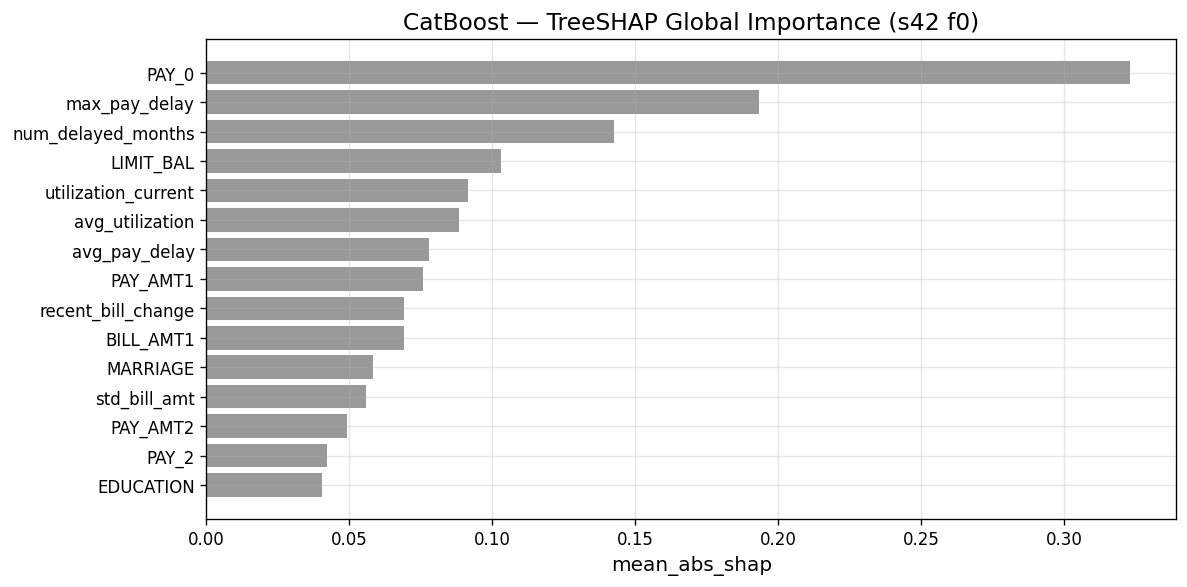

  Figure saved → importance_CatBoost_s42_f0.png & .pdf
  TreeSHAP runtime: 0.44s

--- Explaining: LightGBM_s42_f0 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


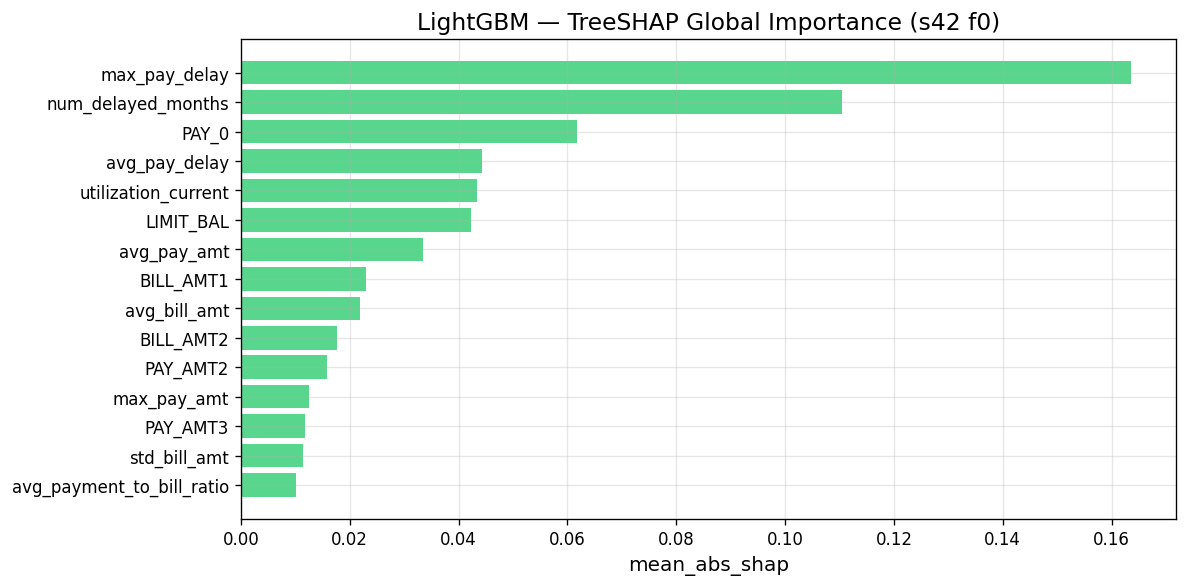

  Figure saved → importance_LightGBM_s42_f0.png & .pdf
  TreeSHAP runtime: 0.03s

--- Explaining: MLP_s42_f0 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


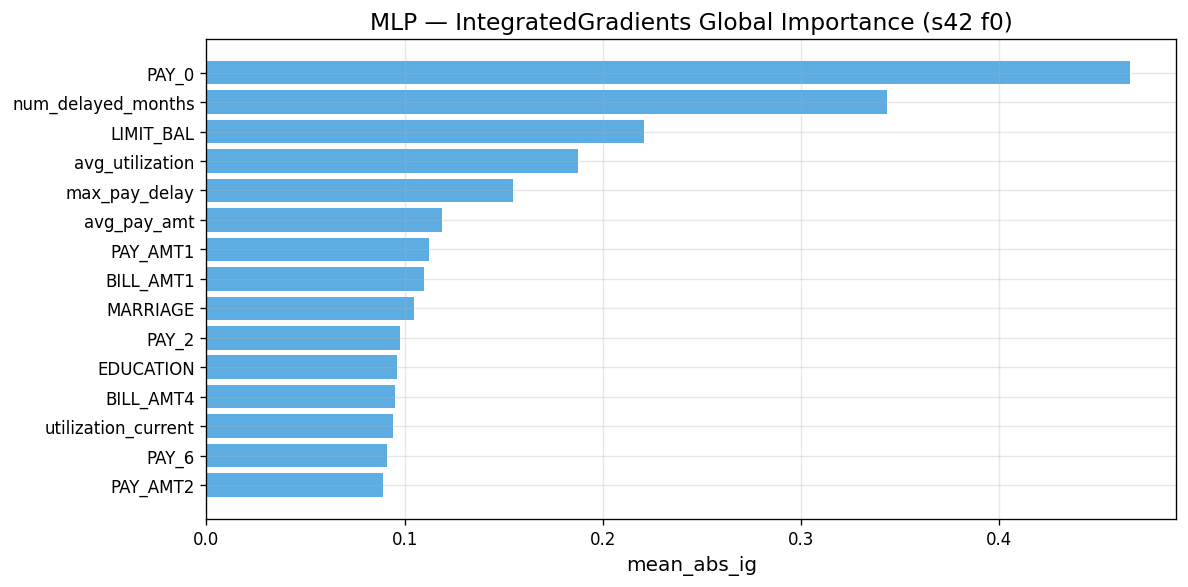

  Figure saved → importance_MLP_s42_f0.png & .pdf
  IntegratedGradients runtime: 0.30s

--- Explaining: TabNet_s42_f0 (500 samples) ---


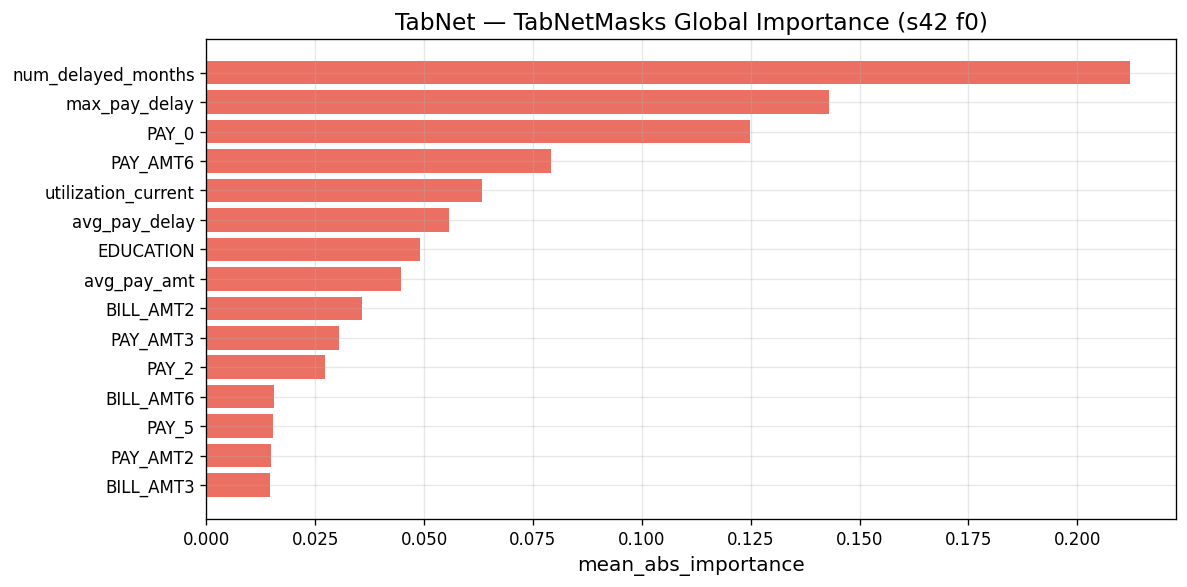

  Figure saved → importance_TabNet_s42_f0.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s42_f1 (500 samples) ---

--- Explaining: CatBoost_s42_f1 (500 samples) ---


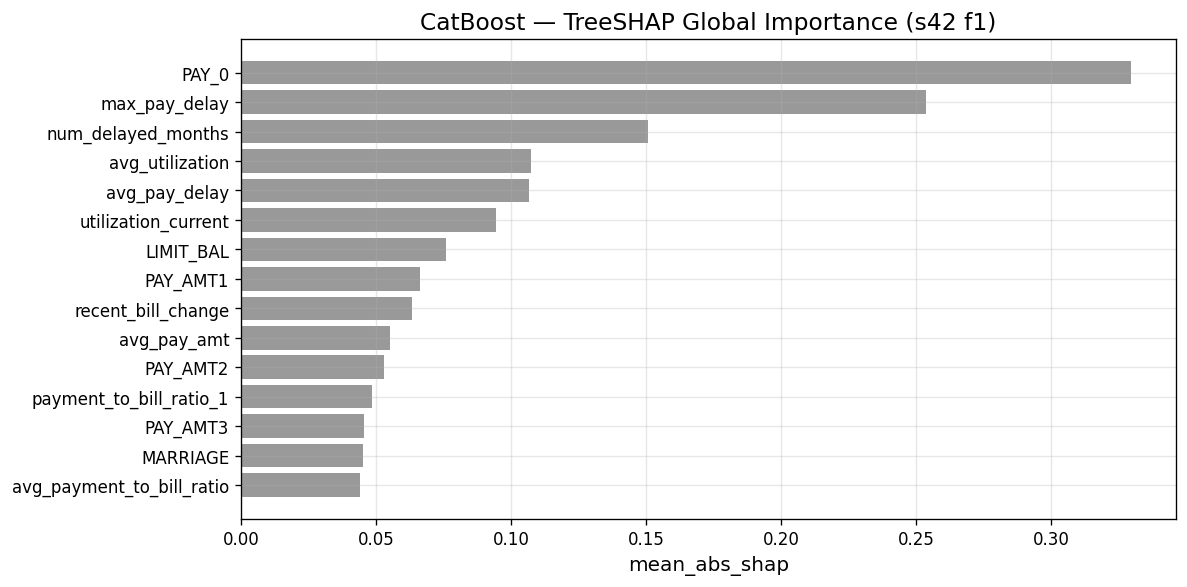

  Figure saved → importance_CatBoost_s42_f1.png & .pdf
  TreeSHAP runtime: 0.39s

--- Explaining: LightGBM_s42_f1 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


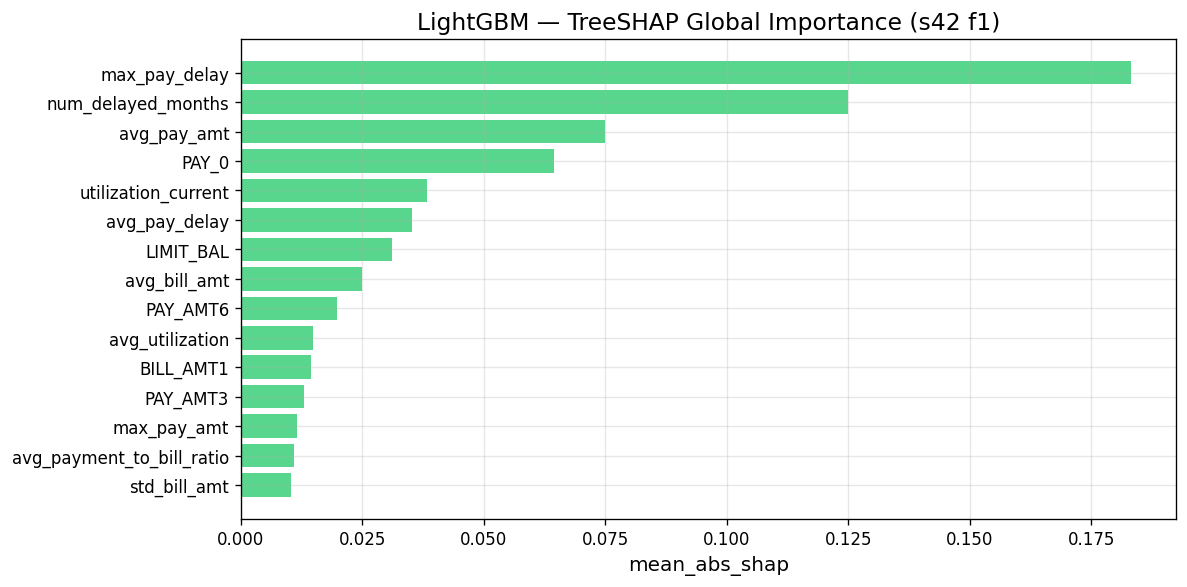

  Figure saved → importance_LightGBM_s42_f1.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s42_f1 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


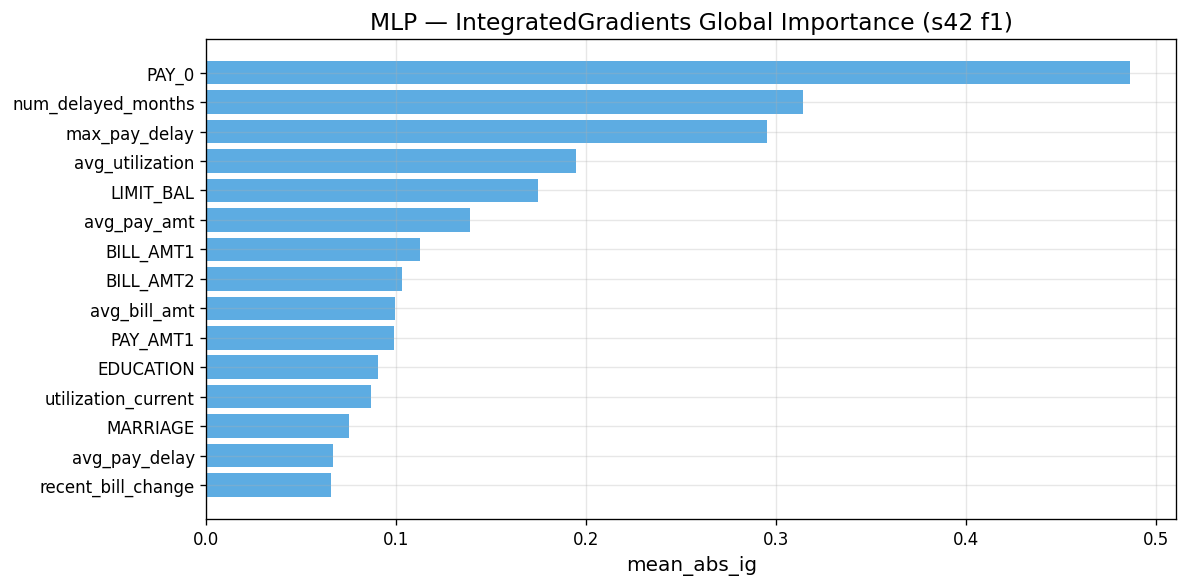

  Figure saved → importance_MLP_s42_f1.png & .pdf
  IntegratedGradients runtime: 0.30s

--- Explaining: TabNet_s42_f1 (500 samples) ---


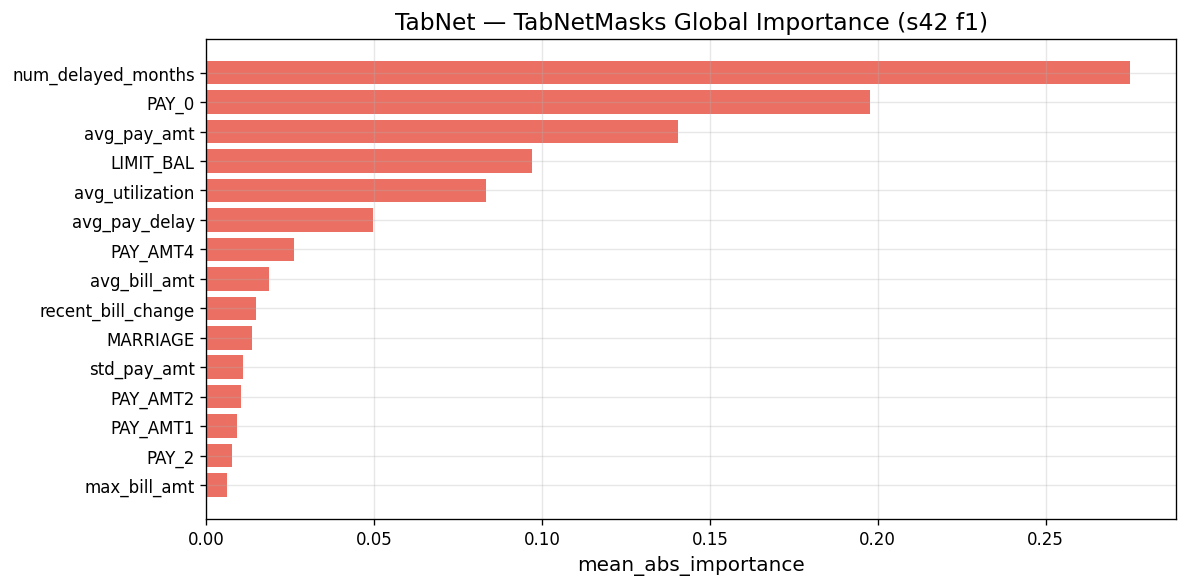

  Figure saved → importance_TabNet_s42_f1.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s42_f2 (500 samples) ---

--- Explaining: CatBoost_s42_f2 (500 samples) ---


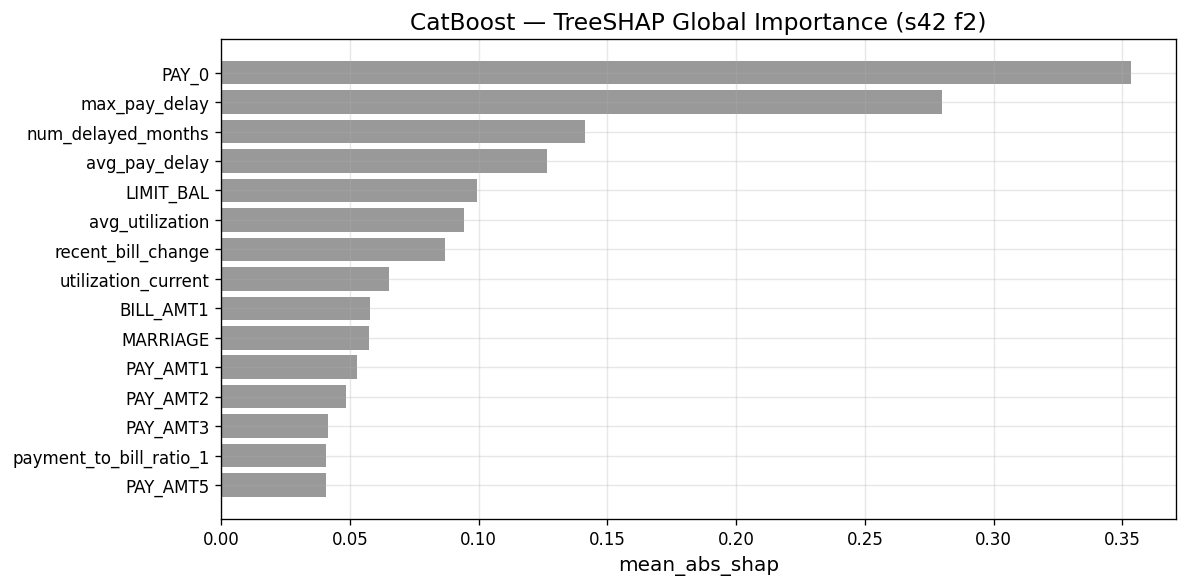

  Figure saved → importance_CatBoost_s42_f2.png & .pdf
  TreeSHAP runtime: 0.46s

--- Explaining: LightGBM_s42_f2 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


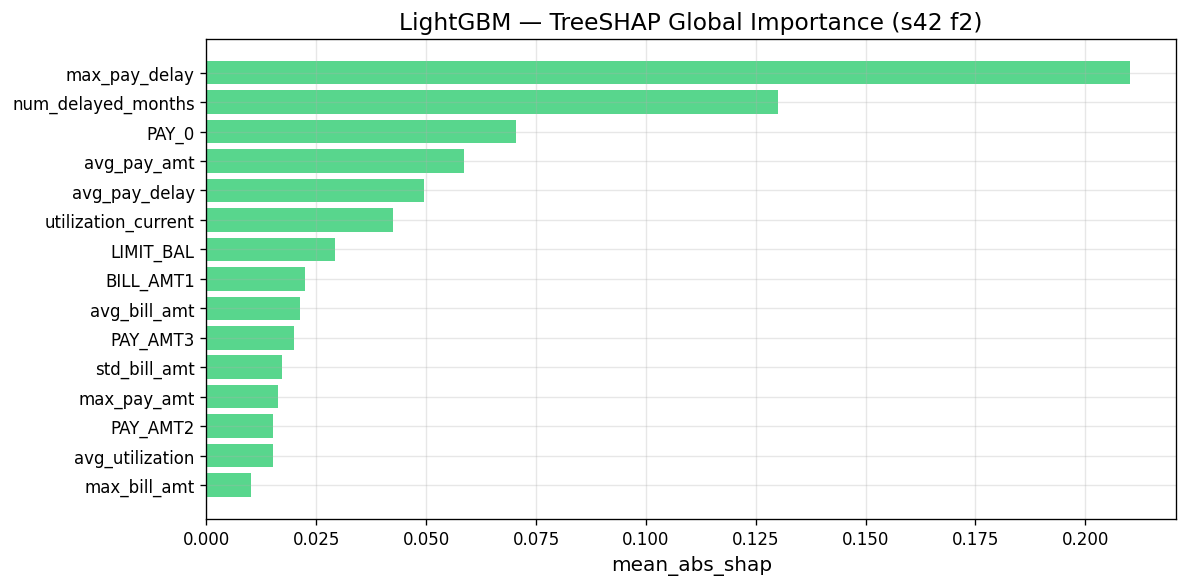

  Figure saved → importance_LightGBM_s42_f2.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s42_f2 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


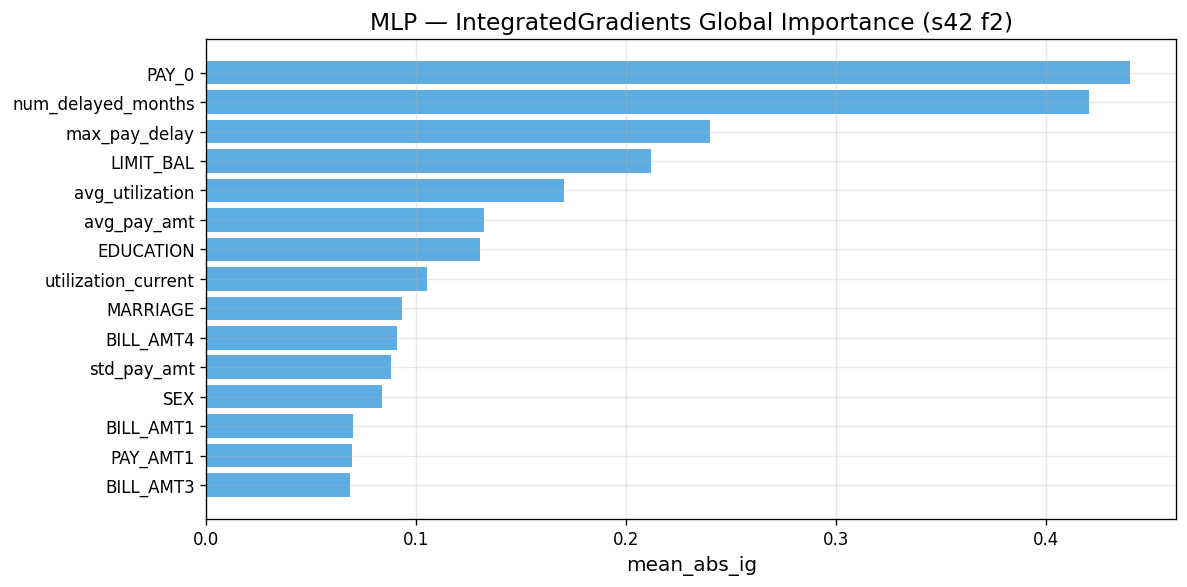

  Figure saved → importance_MLP_s42_f2.png & .pdf
  IntegratedGradients runtime: 0.30s

--- Explaining: TabNet_s42_f2 (500 samples) ---


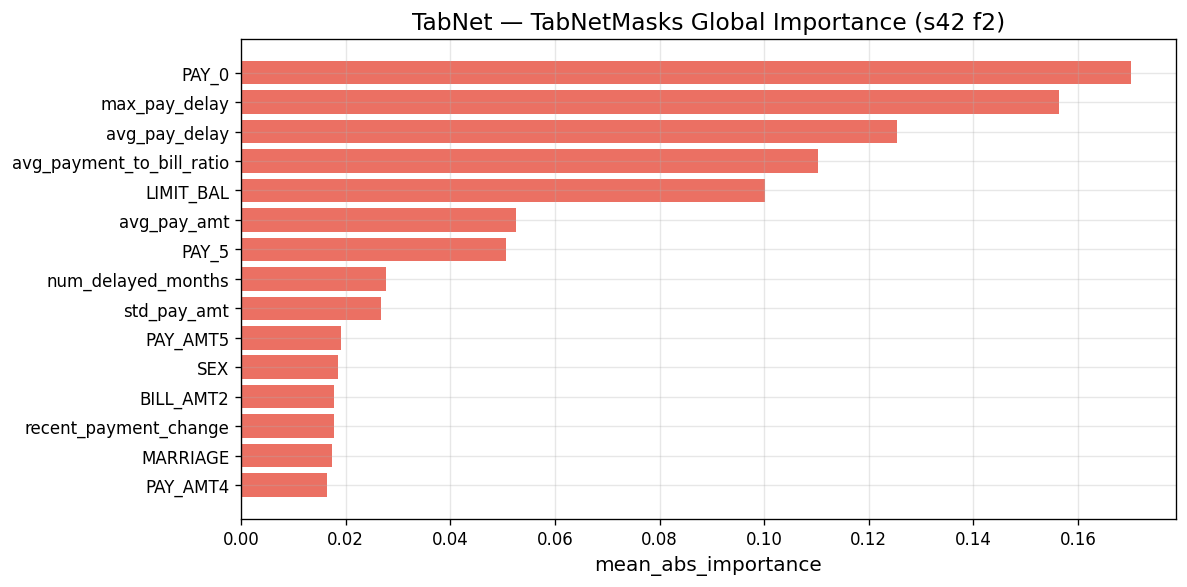

  Figure saved → importance_TabNet_s42_f2.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s42_f3 (500 samples) ---

--- Explaining: CatBoost_s42_f3 (500 samples) ---


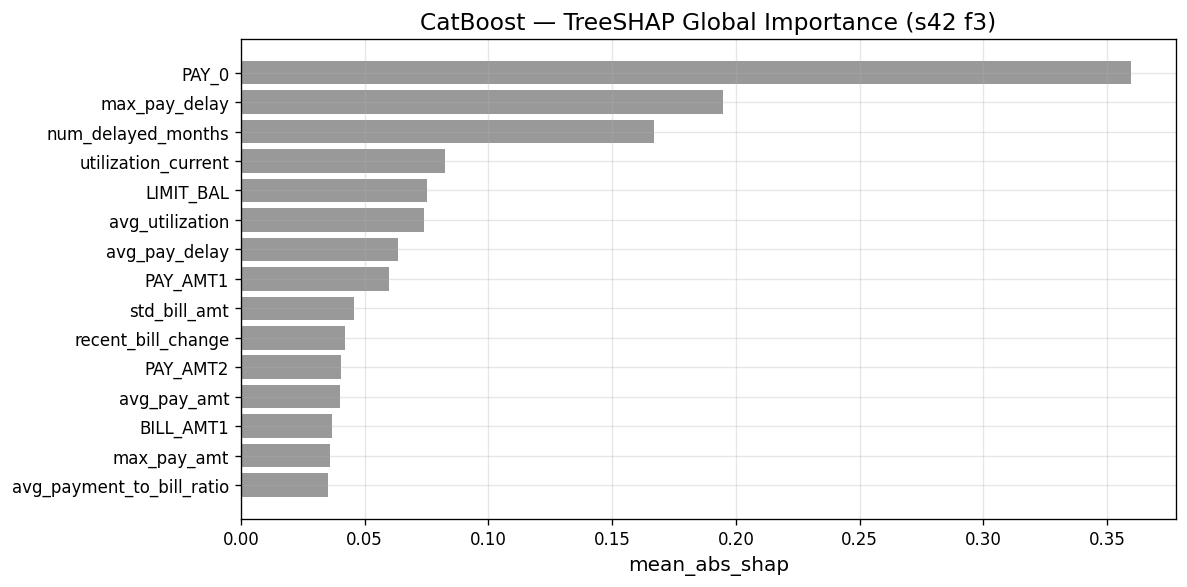

  Figure saved → importance_CatBoost_s42_f3.png & .pdf
  TreeSHAP runtime: 0.20s

--- Explaining: LightGBM_s42_f3 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


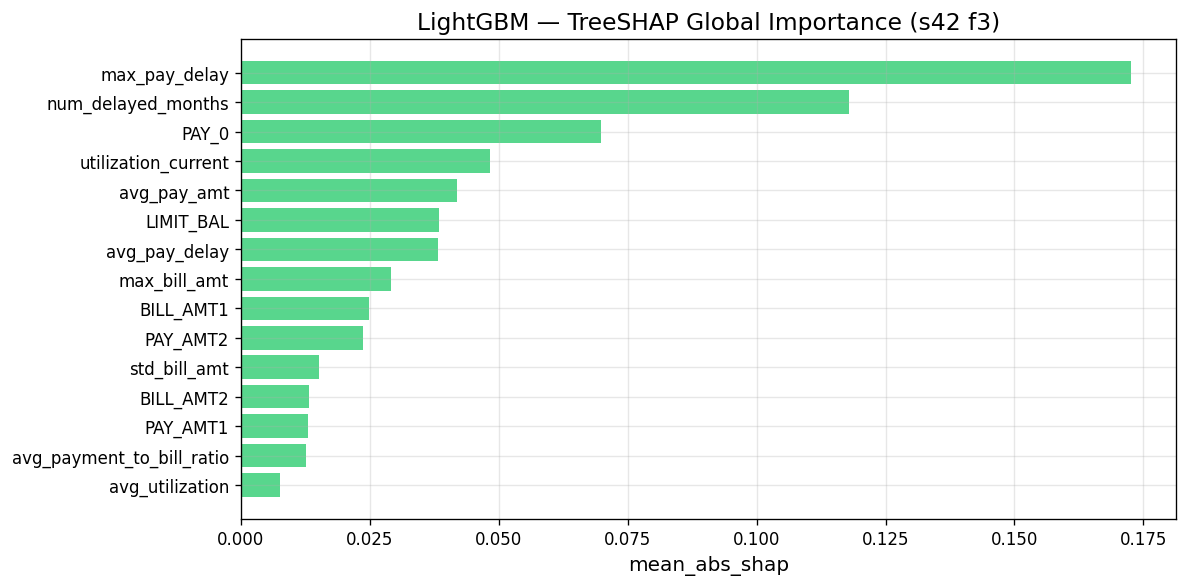

  Figure saved → importance_LightGBM_s42_f3.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s42_f3 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


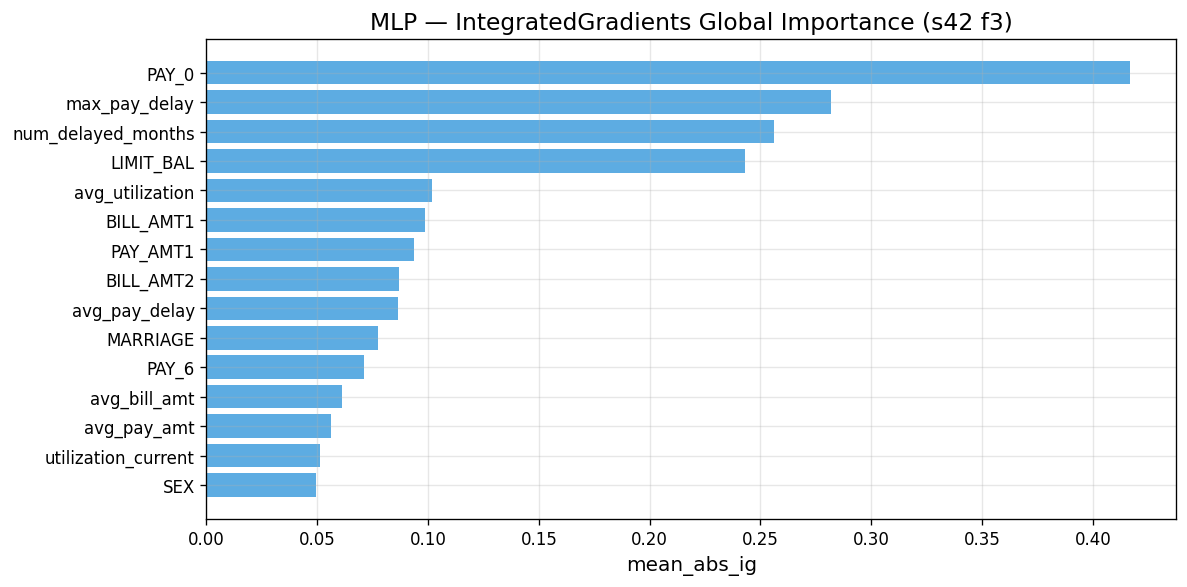

  Figure saved → importance_MLP_s42_f3.png & .pdf
  IntegratedGradients runtime: 0.30s

--- Explaining: TabNet_s42_f3 (500 samples) ---


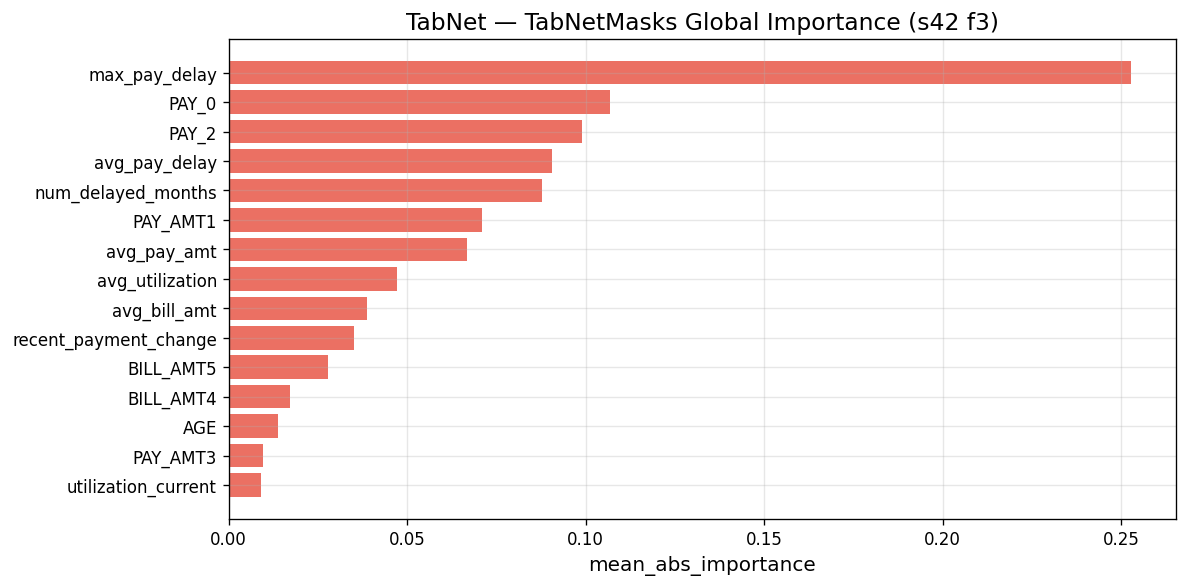

  Figure saved → importance_TabNet_s42_f3.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s42_f4 (500 samples) ---

--- Explaining: CatBoost_s42_f4 (500 samples) ---


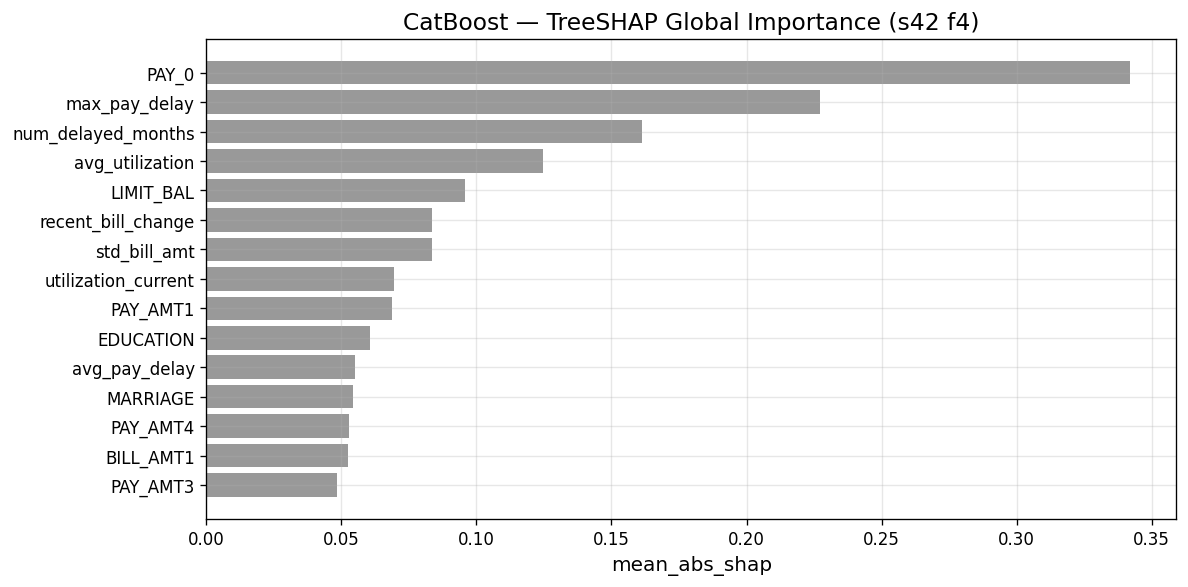

  Figure saved → importance_CatBoost_s42_f4.png & .pdf
  TreeSHAP runtime: 0.43s

--- Explaining: LightGBM_s42_f4 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


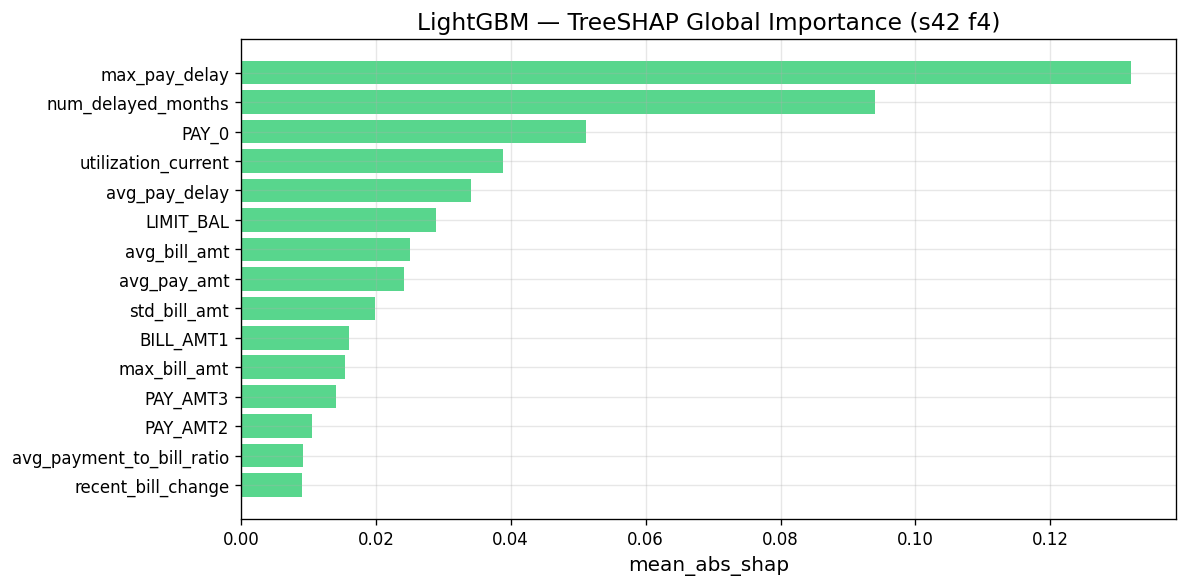

  Figure saved → importance_LightGBM_s42_f4.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s42_f4 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


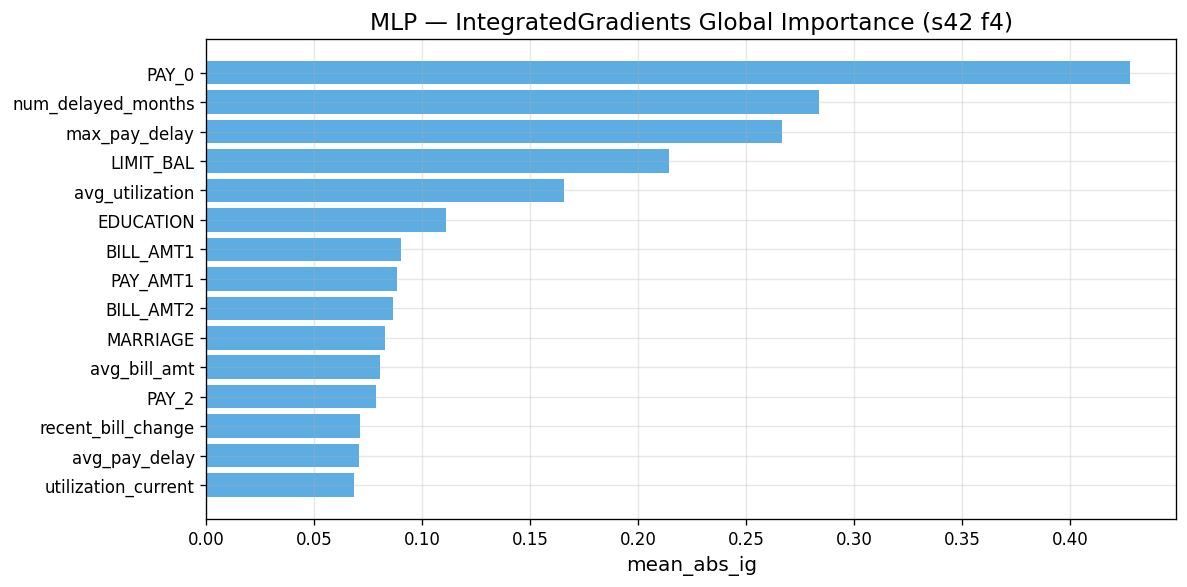

  Figure saved → importance_MLP_s42_f4.png & .pdf
  IntegratedGradients runtime: 0.32s

--- Explaining: TabNet_s42_f4 (500 samples) ---


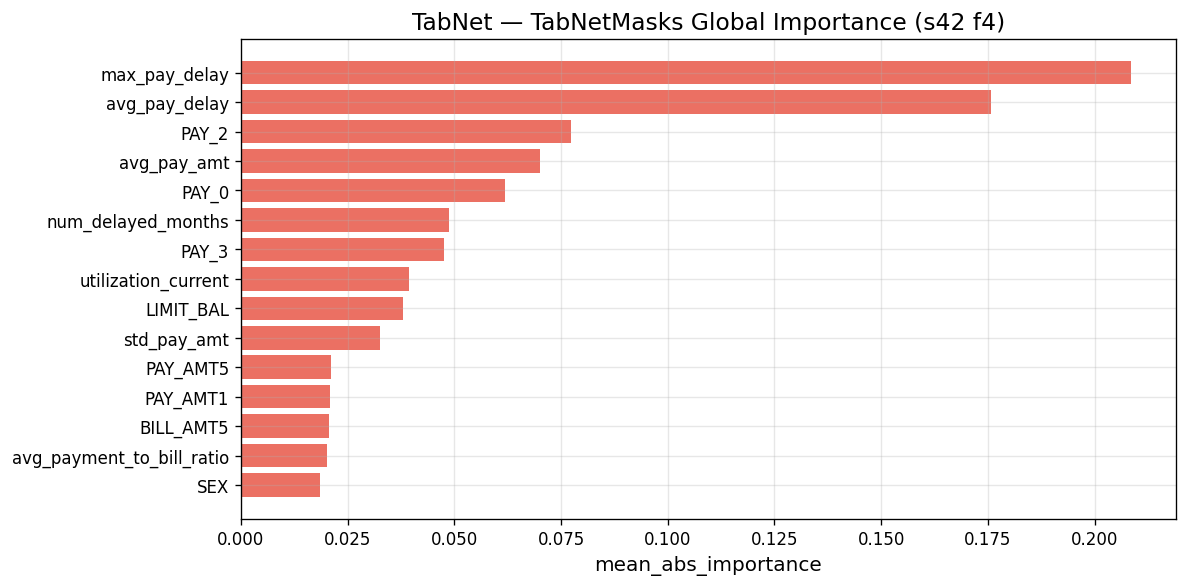

  Figure saved → importance_TabNet_s42_f4.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s2024_f0 (500 samples) ---

--- Explaining: CatBoost_s2024_f0 (500 samples) ---


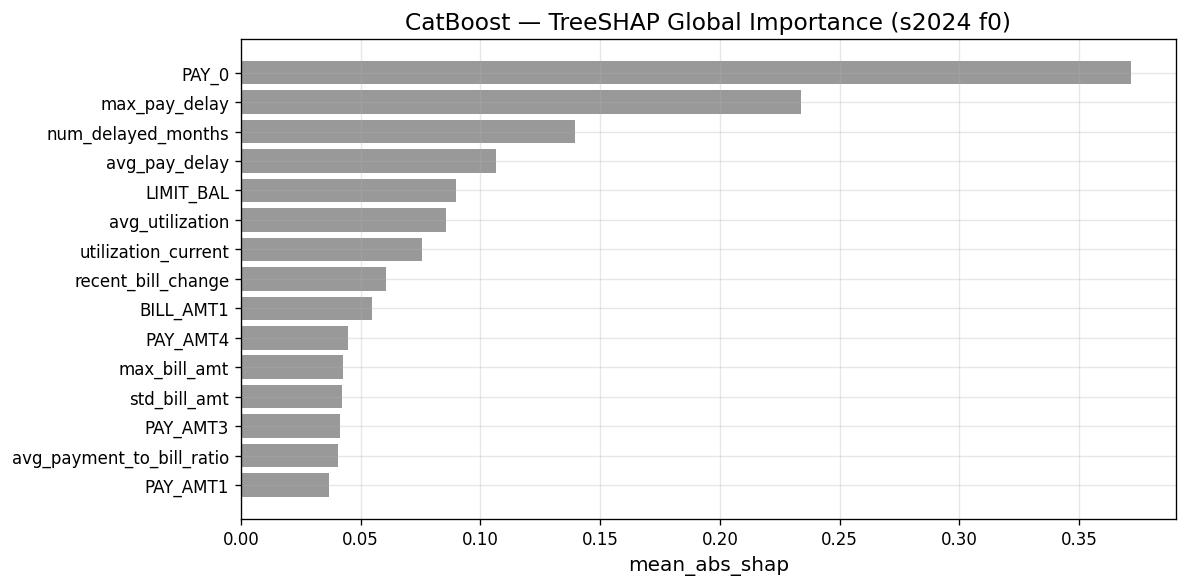

  Figure saved → importance_CatBoost_s2024_f0.png & .pdf
  TreeSHAP runtime: 0.28s

--- Explaining: LightGBM_s2024_f0 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


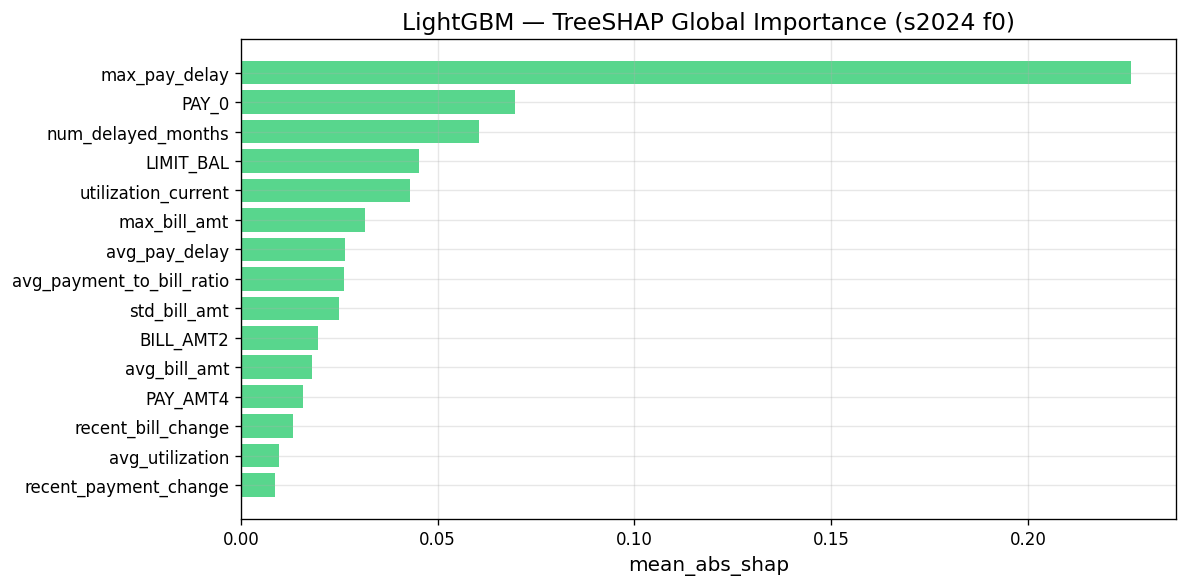

  Figure saved → importance_LightGBM_s2024_f0.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s2024_f0 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


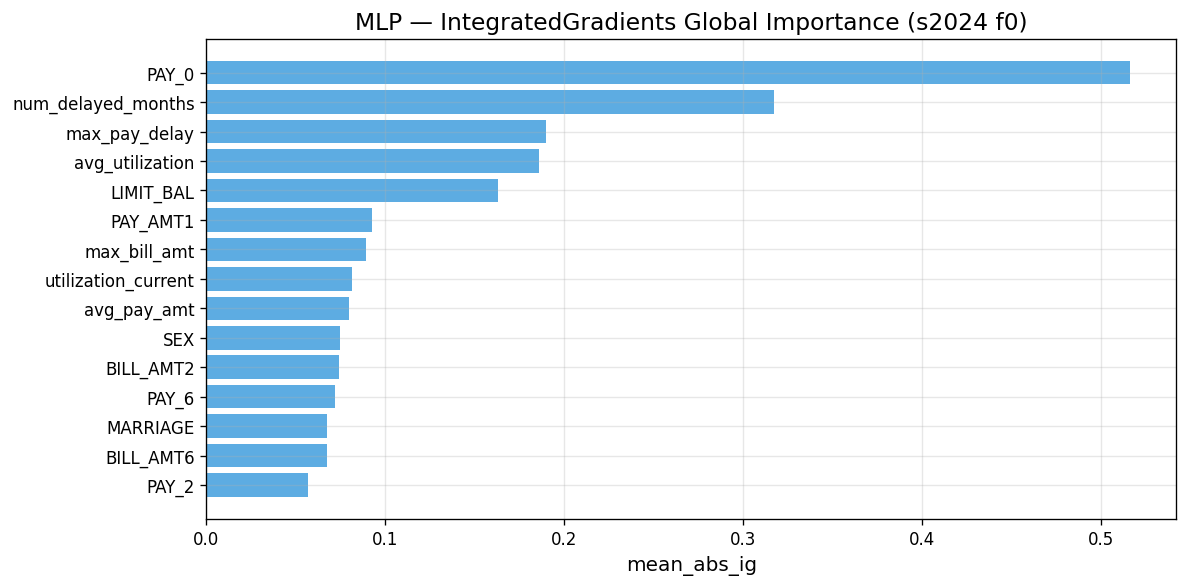

  Figure saved → importance_MLP_s2024_f0.png & .pdf
  IntegratedGradients runtime: 0.30s

--- Explaining: TabNet_s2024_f0 (500 samples) ---


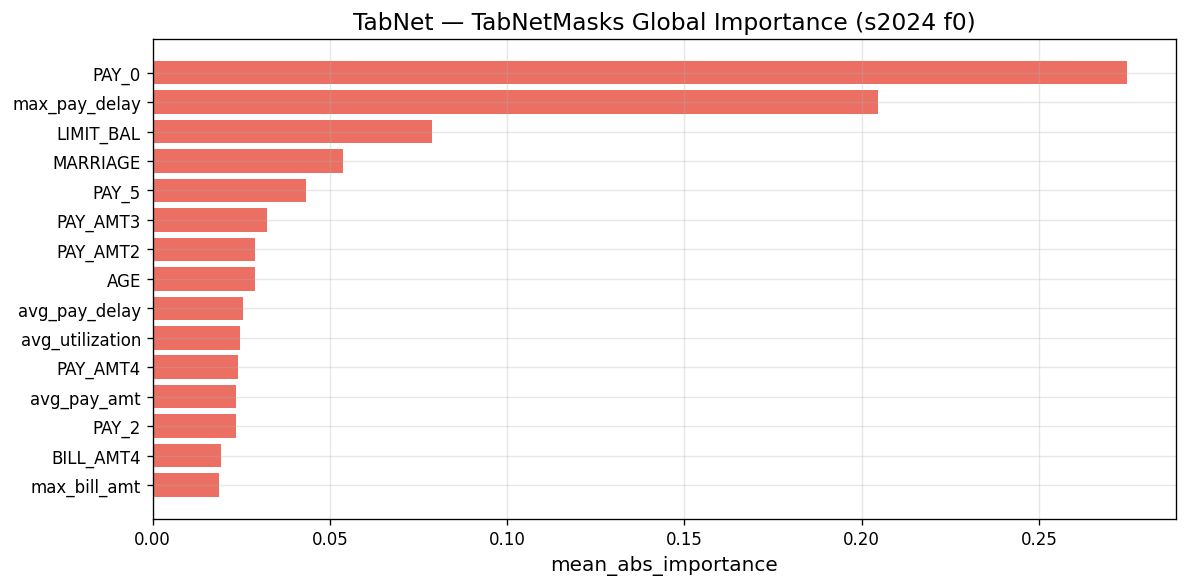

  Figure saved → importance_TabNet_s2024_f0.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s2024_f1 (500 samples) ---

--- Explaining: CatBoost_s2024_f1 (500 samples) ---


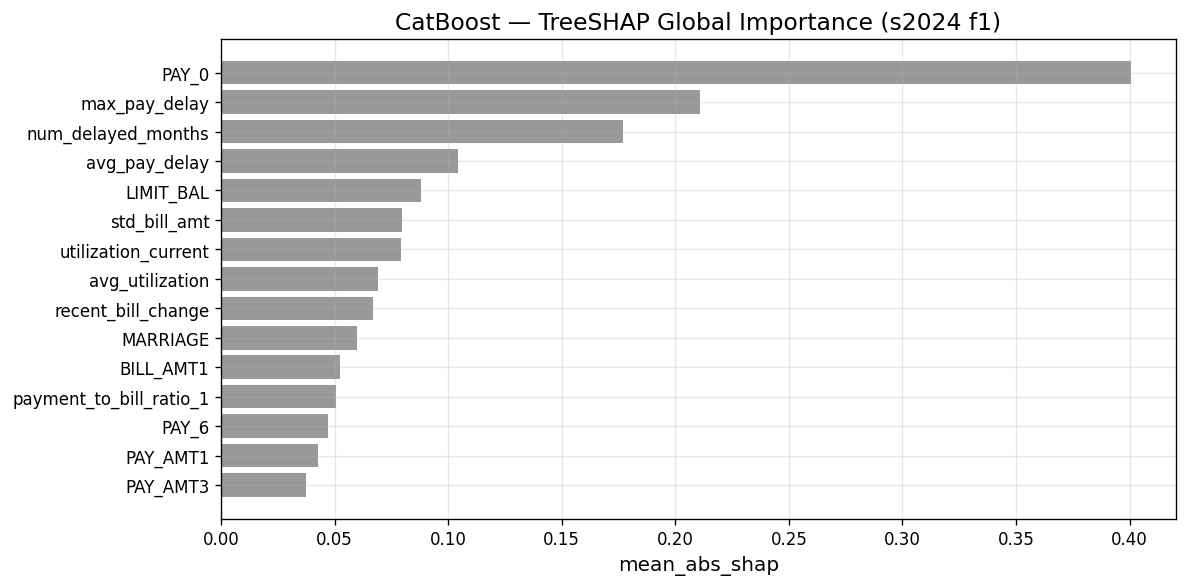

  Figure saved → importance_CatBoost_s2024_f1.png & .pdf
  TreeSHAP runtime: 0.33s

--- Explaining: LightGBM_s2024_f1 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


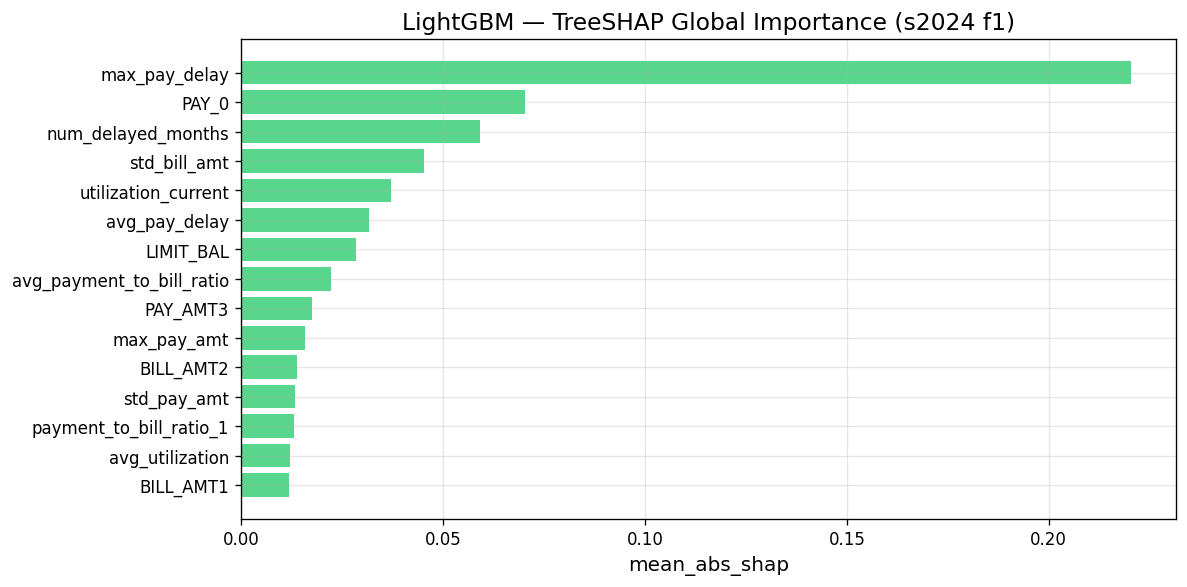

  Figure saved → importance_LightGBM_s2024_f1.png & .pdf
  TreeSHAP runtime: 0.03s

--- Explaining: MLP_s2024_f1 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


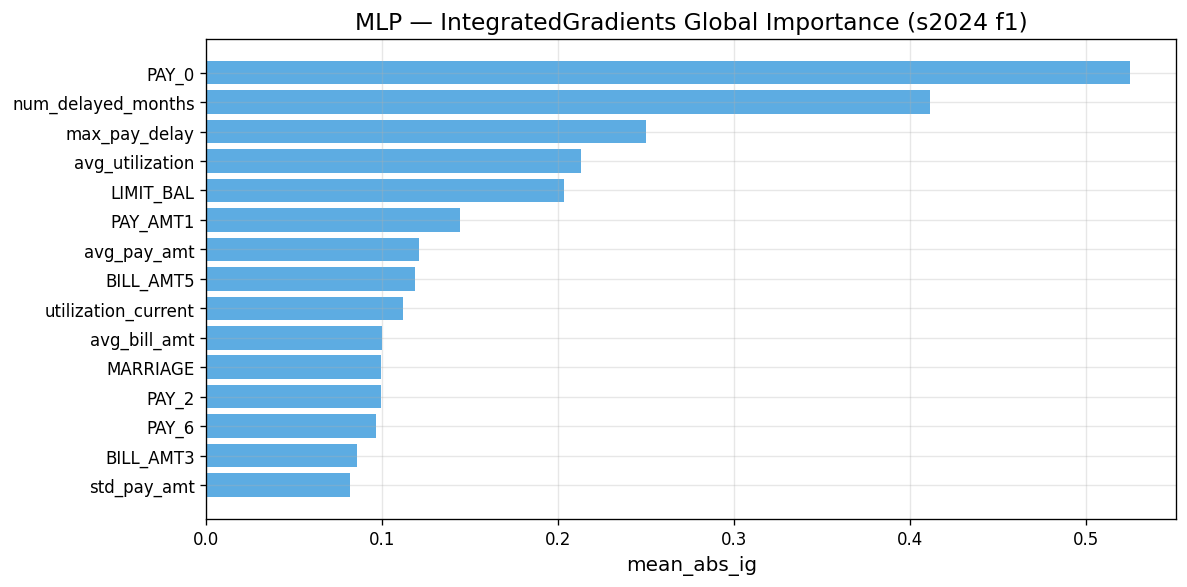

  Figure saved → importance_MLP_s2024_f1.png & .pdf
  IntegratedGradients runtime: 0.30s

--- Explaining: TabNet_s2024_f1 (500 samples) ---


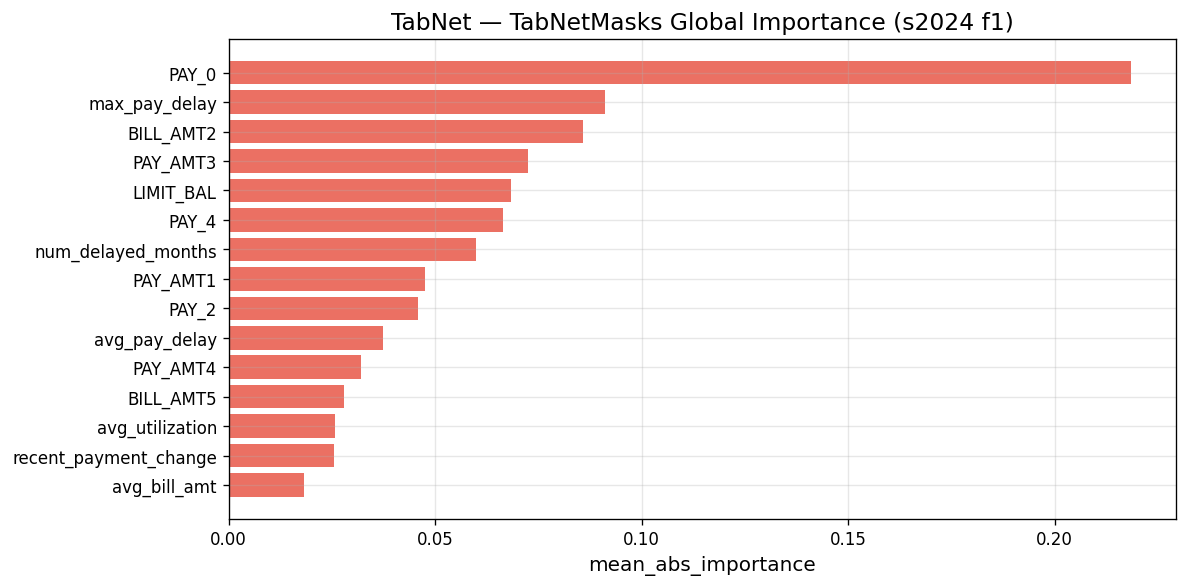

  Figure saved → importance_TabNet_s2024_f1.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s2024_f2 (500 samples) ---

--- Explaining: CatBoost_s2024_f2 (500 samples) ---


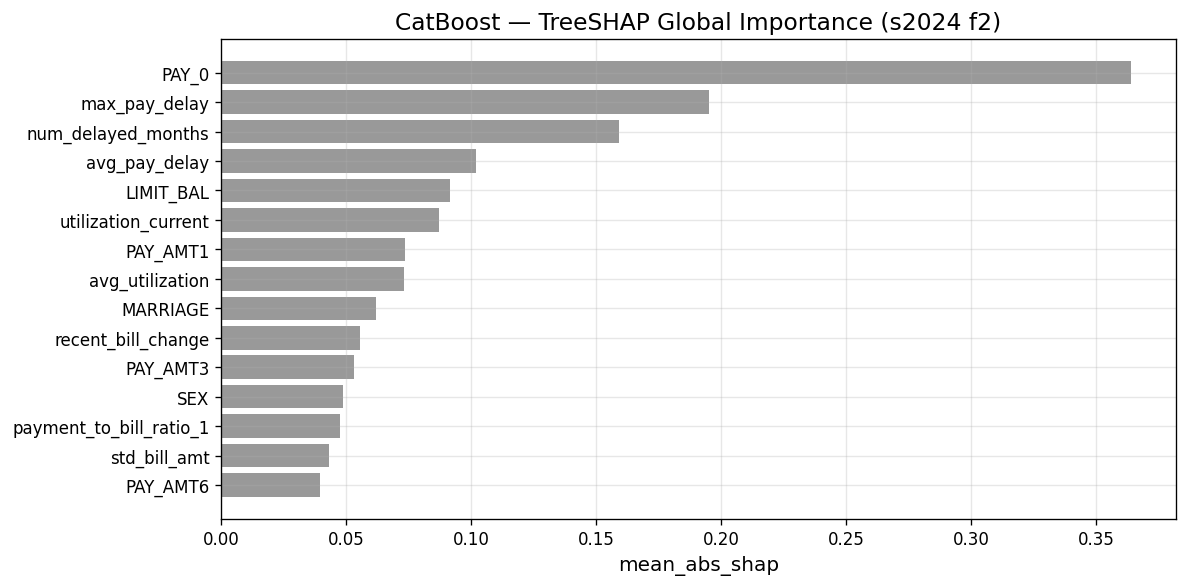

  Figure saved → importance_CatBoost_s2024_f2.png & .pdf
  TreeSHAP runtime: 0.36s

--- Explaining: LightGBM_s2024_f2 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


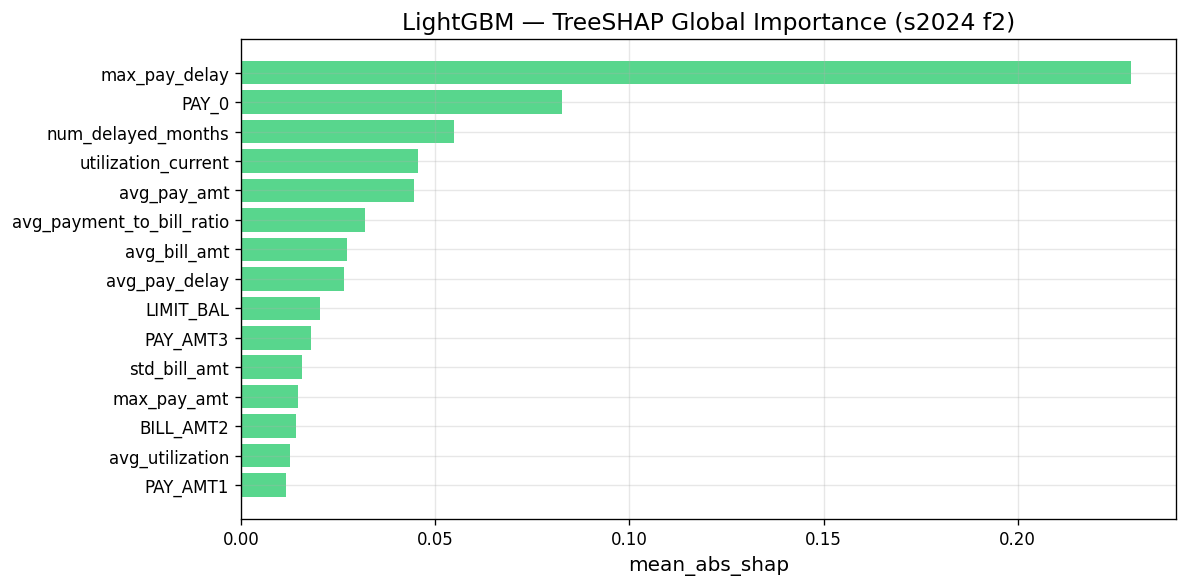

  Figure saved → importance_LightGBM_s2024_f2.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s2024_f2 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


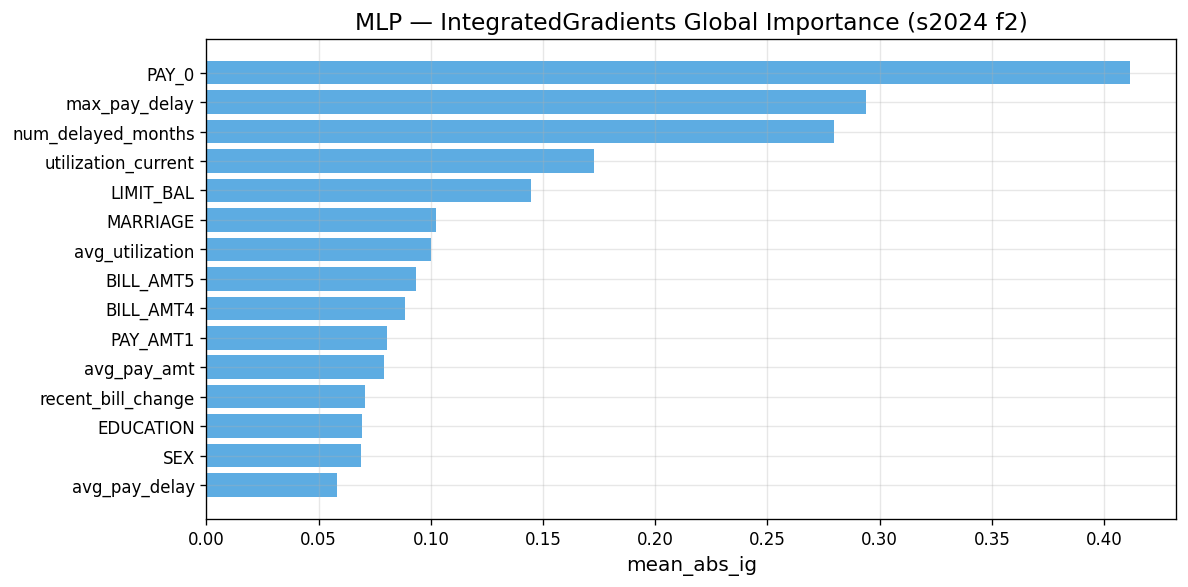

  Figure saved → importance_MLP_s2024_f2.png & .pdf
  IntegratedGradients runtime: 0.31s

--- Explaining: TabNet_s2024_f2 (500 samples) ---


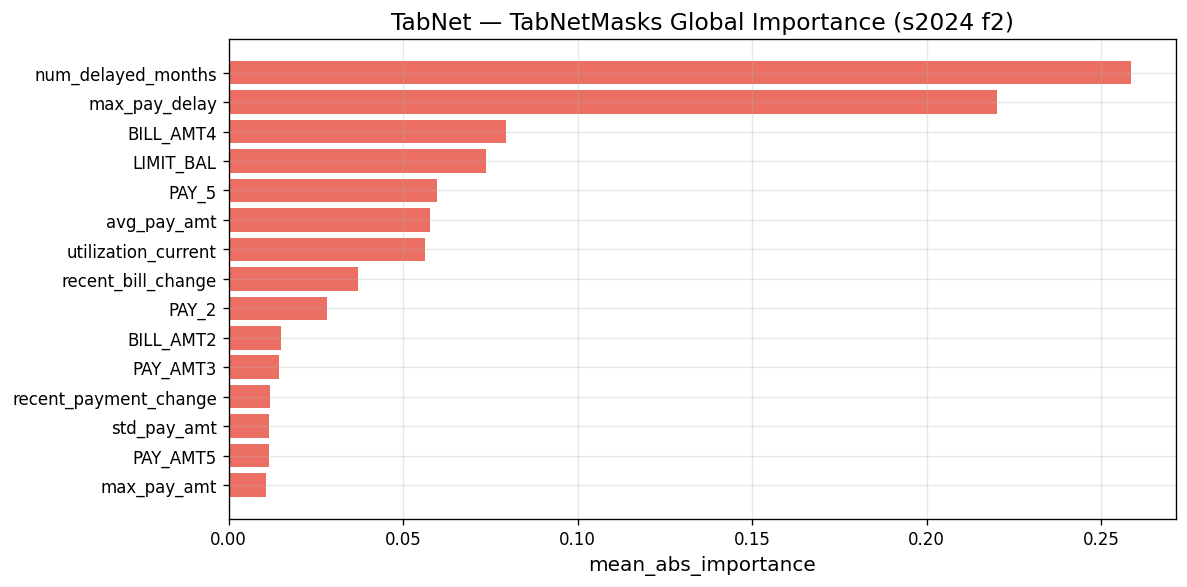

  Figure saved → importance_TabNet_s2024_f2.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s2024_f3 (500 samples) ---

--- Explaining: CatBoost_s2024_f3 (500 samples) ---


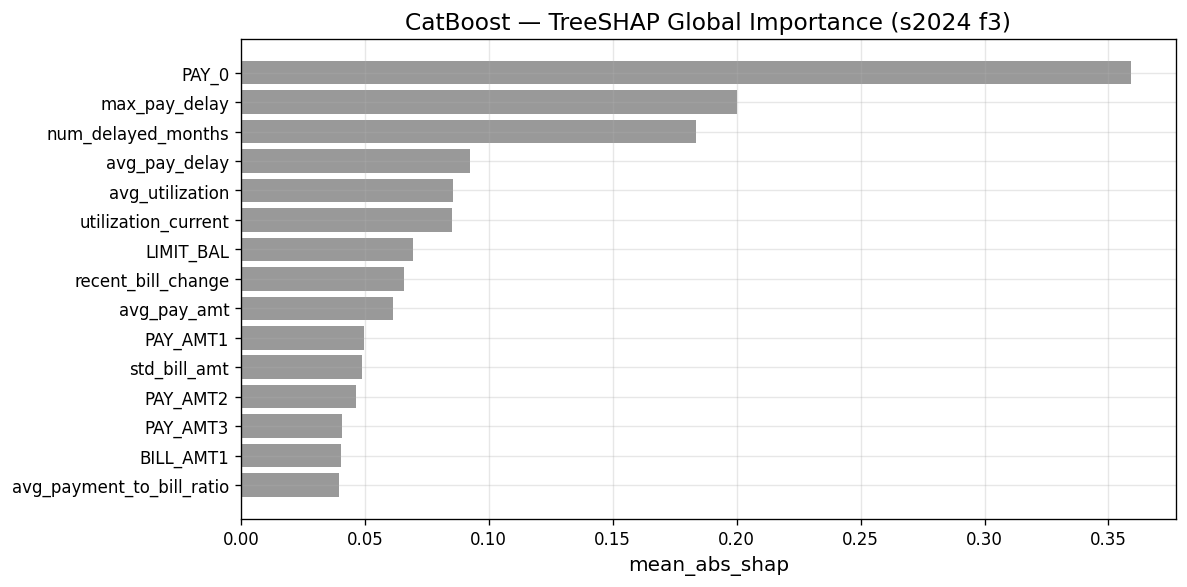

  Figure saved → importance_CatBoost_s2024_f3.png & .pdf
  TreeSHAP runtime: 0.35s

--- Explaining: LightGBM_s2024_f3 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


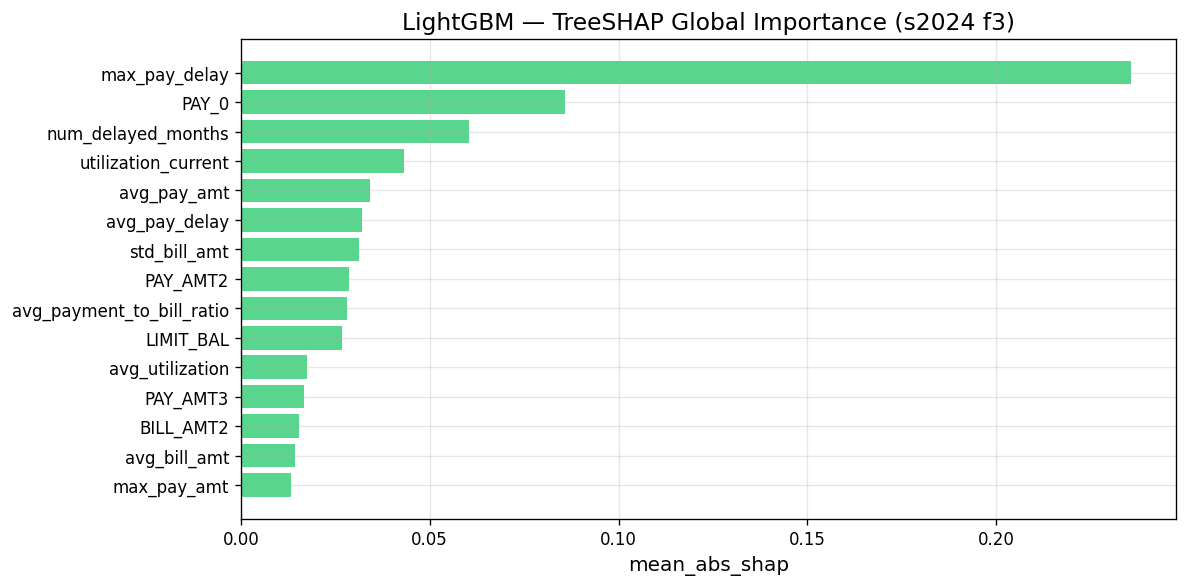

  Figure saved → importance_LightGBM_s2024_f3.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s2024_f3 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


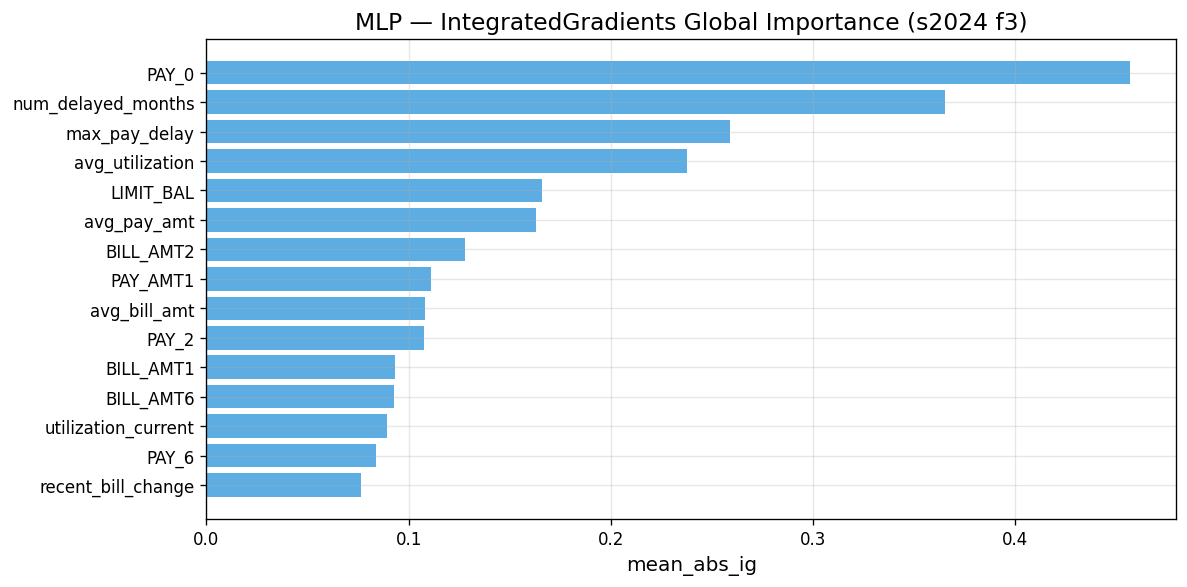

  Figure saved → importance_MLP_s2024_f3.png & .pdf
  IntegratedGradients runtime: 0.30s

--- Explaining: TabNet_s2024_f3 (500 samples) ---


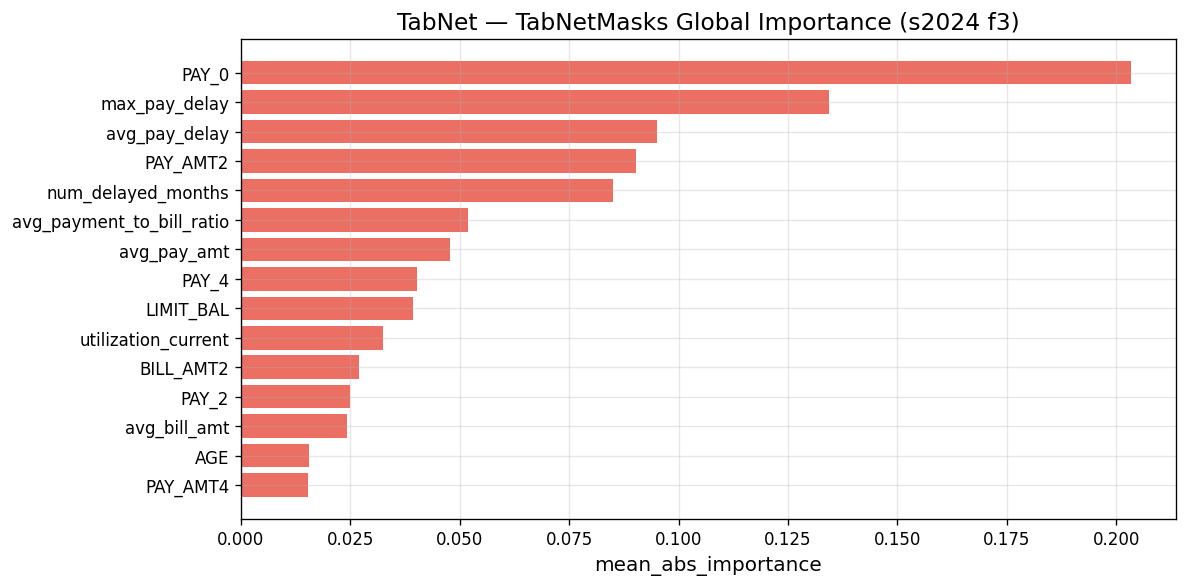

  Figure saved → importance_TabNet_s2024_f3.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s2024_f4 (500 samples) ---

--- Explaining: CatBoost_s2024_f4 (500 samples) ---


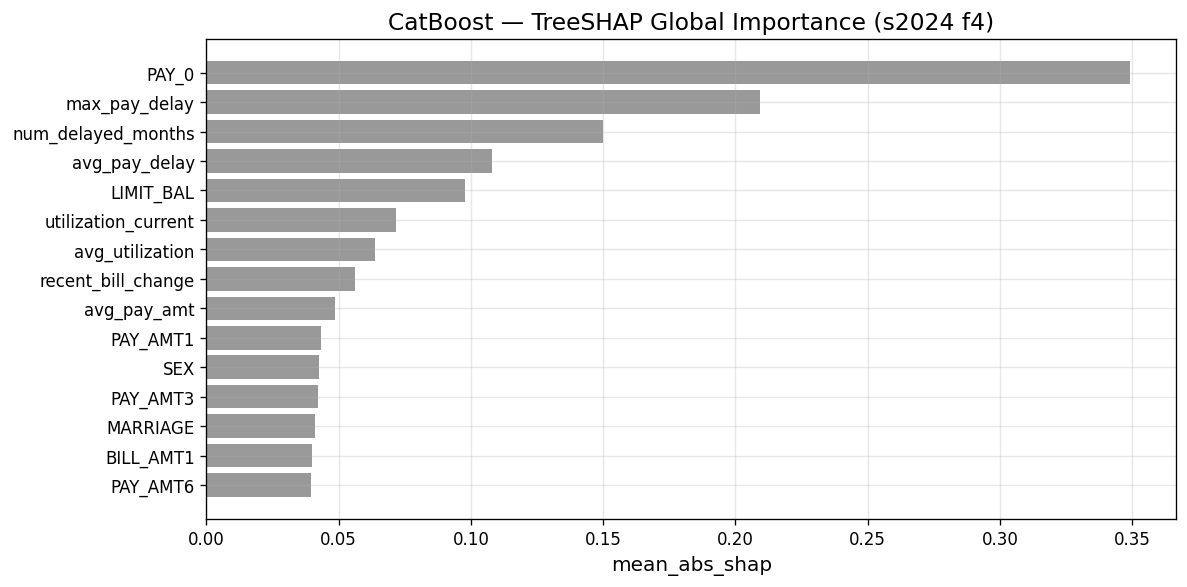

  Figure saved → importance_CatBoost_s2024_f4.png & .pdf
  TreeSHAP runtime: 0.30s

--- Explaining: LightGBM_s2024_f4 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


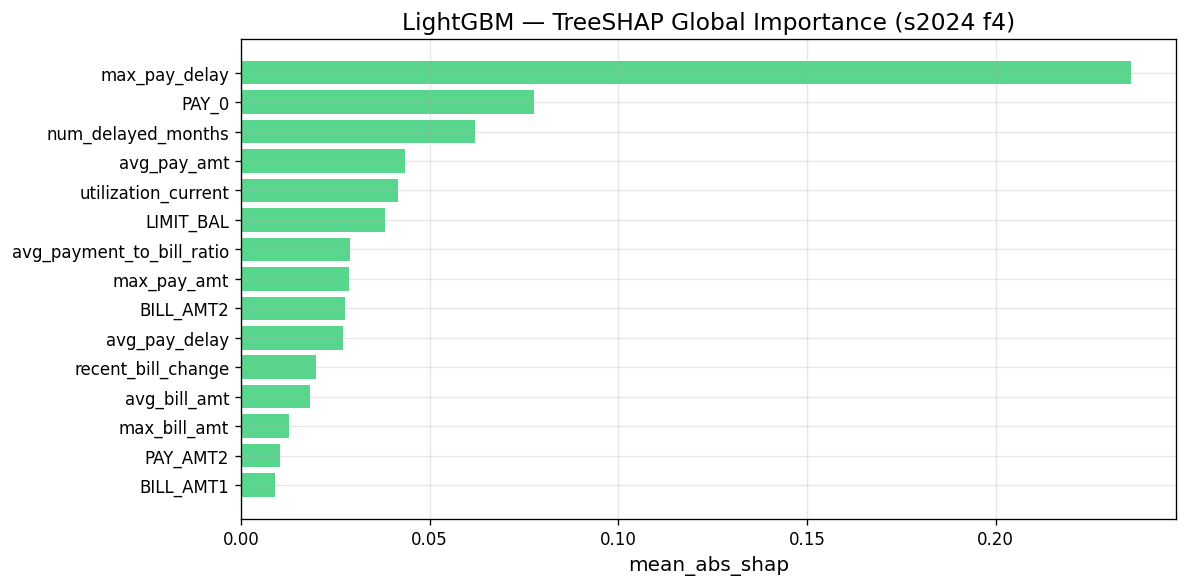

  Figure saved → importance_LightGBM_s2024_f4.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s2024_f4 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


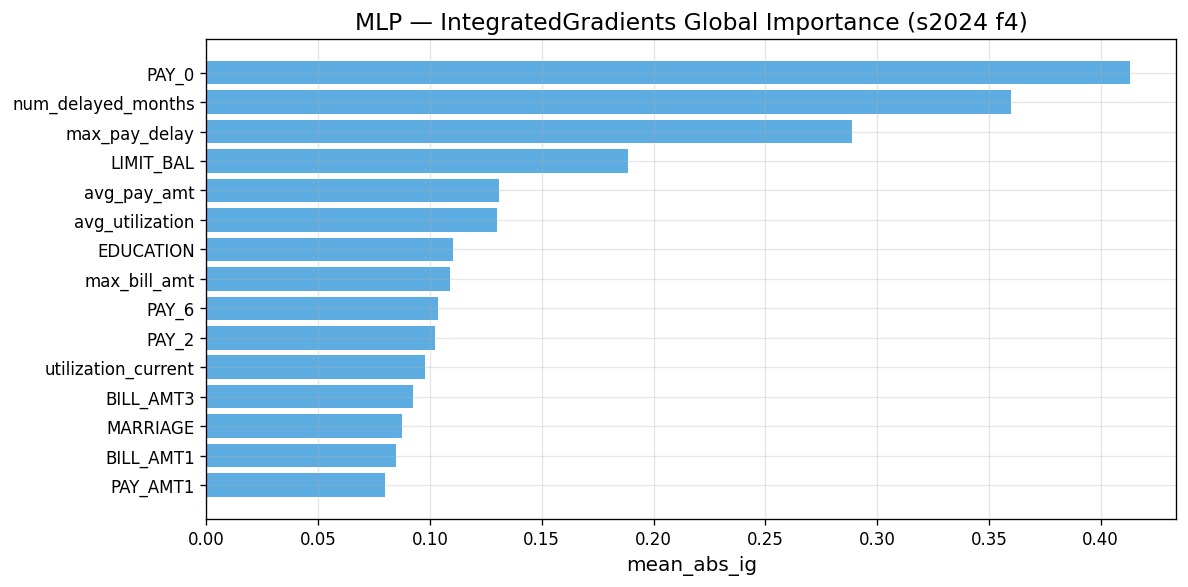

  Figure saved → importance_MLP_s2024_f4.png & .pdf
  IntegratedGradients runtime: 0.30s

--- Explaining: TabNet_s2024_f4 (500 samples) ---


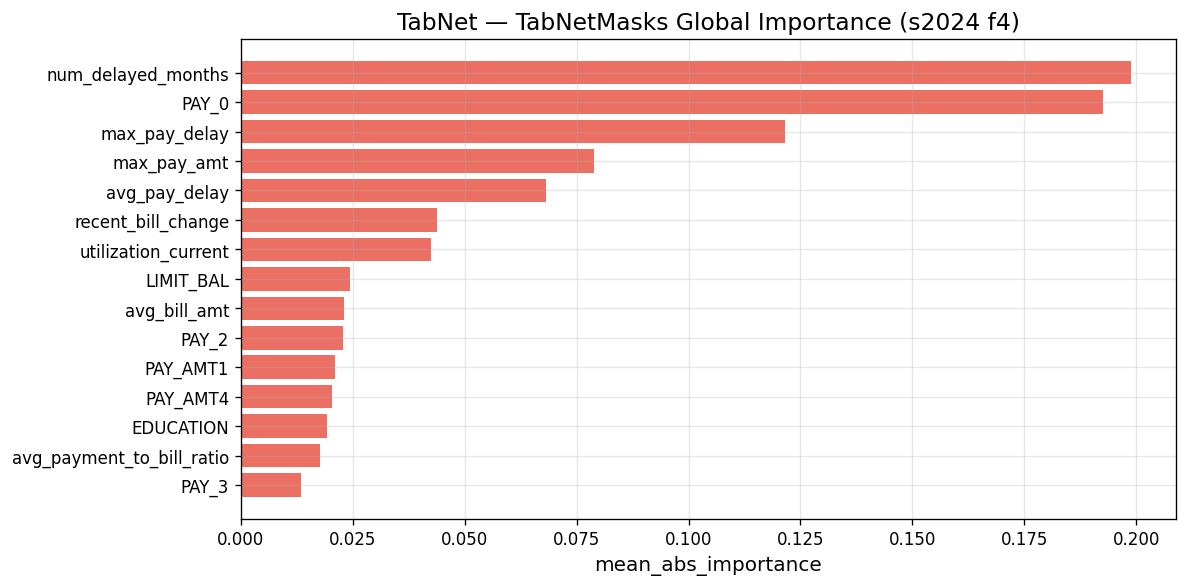

  Figure saved → importance_TabNet_s2024_f4.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s7_f0 (500 samples) ---

--- Explaining: CatBoost_s7_f0 (500 samples) ---


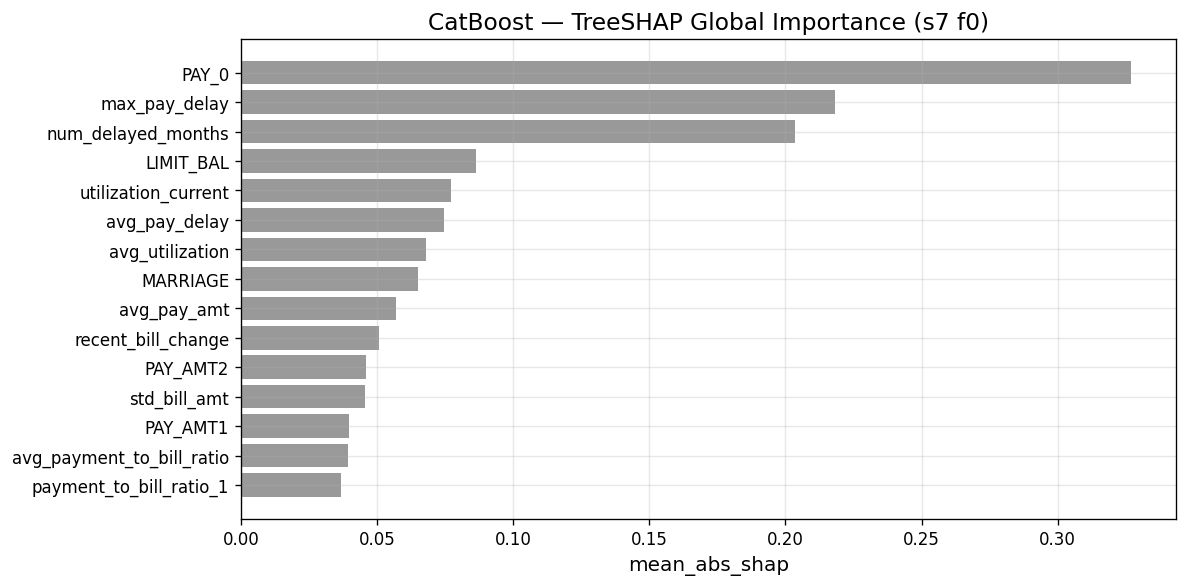

  Figure saved → importance_CatBoost_s7_f0.png & .pdf
  TreeSHAP runtime: 0.33s

--- Explaining: LightGBM_s7_f0 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


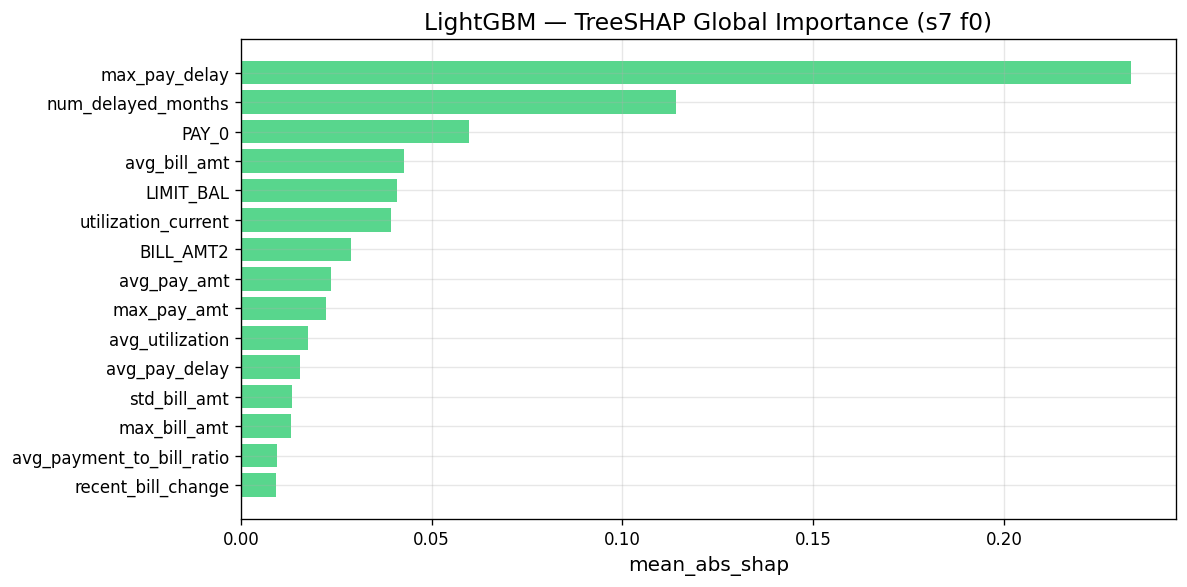

  Figure saved → importance_LightGBM_s7_f0.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s7_f0 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


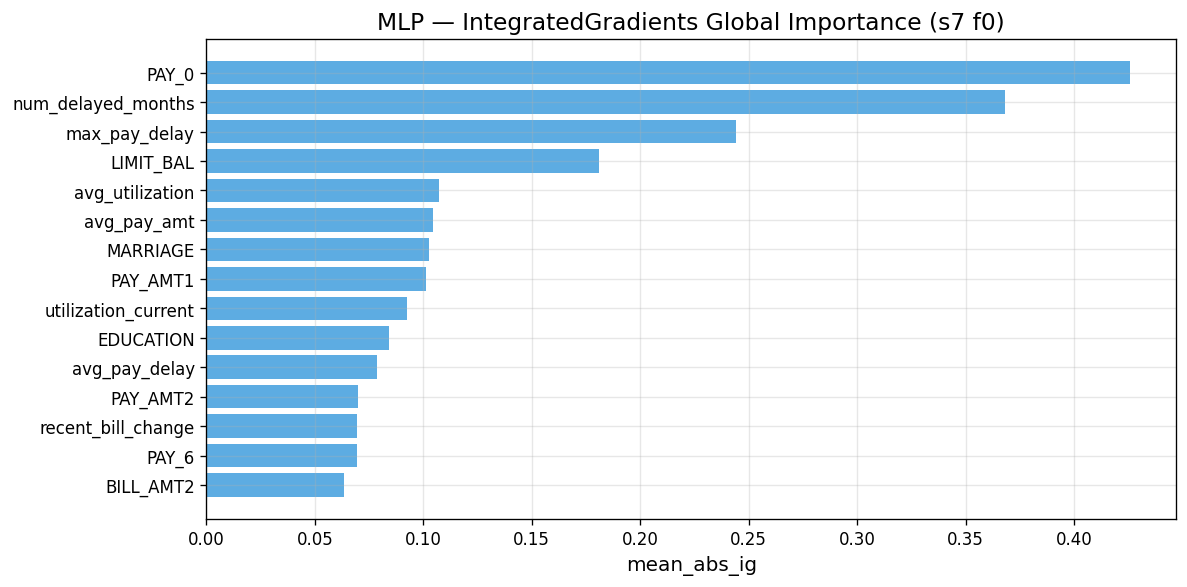

  Figure saved → importance_MLP_s7_f0.png & .pdf
  IntegratedGradients runtime: 0.30s

--- Explaining: TabNet_s7_f0 (500 samples) ---


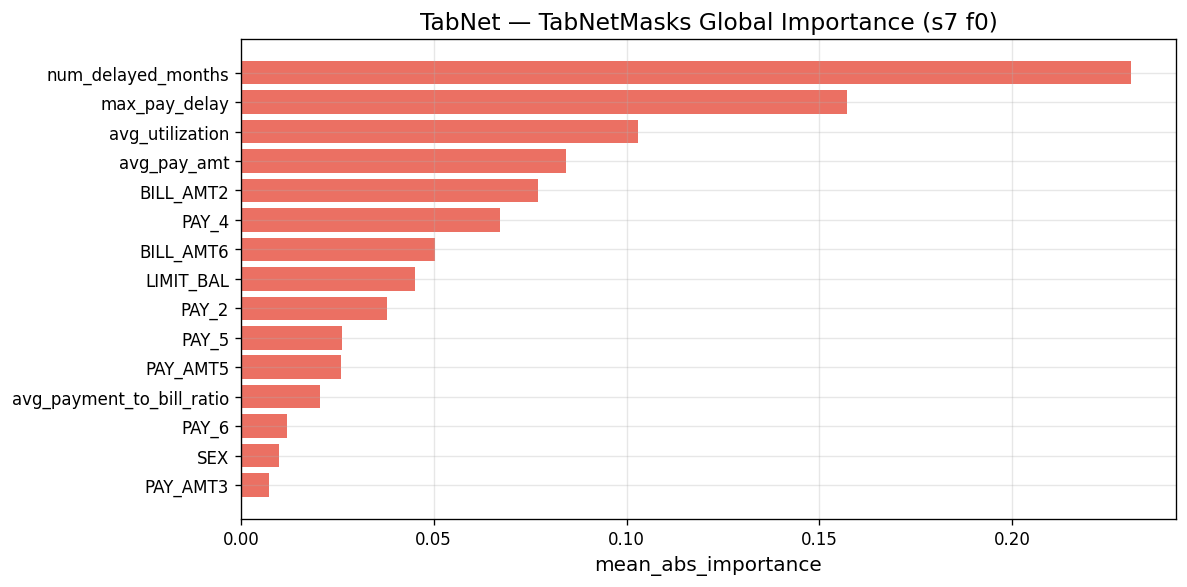

  Figure saved → importance_TabNet_s7_f0.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s7_f1 (500 samples) ---

--- Explaining: CatBoost_s7_f1 (500 samples) ---


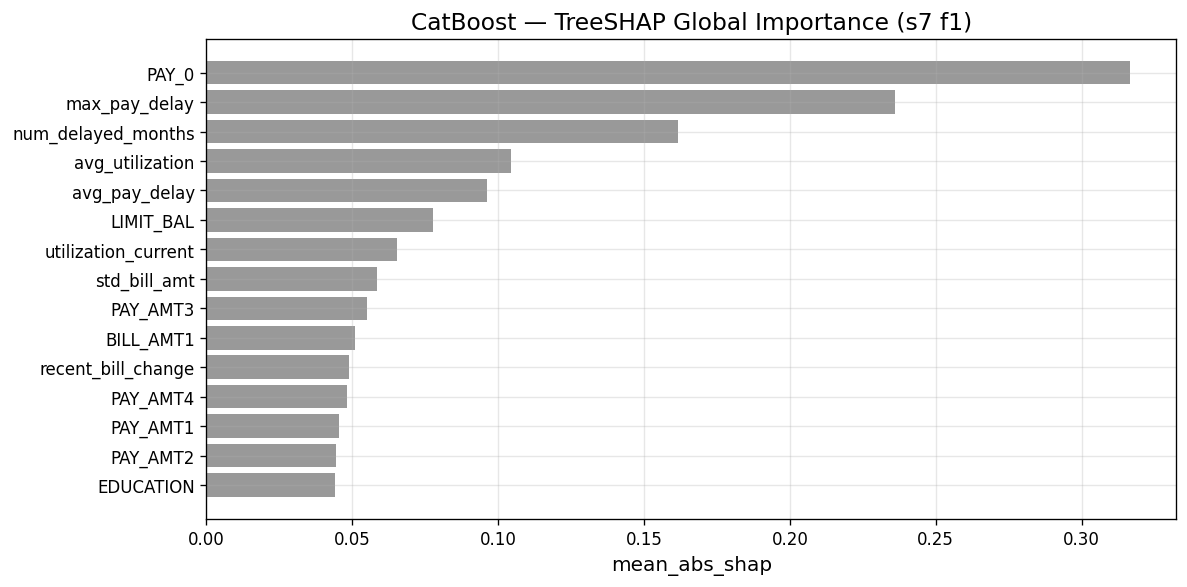

  Figure saved → importance_CatBoost_s7_f1.png & .pdf
  TreeSHAP runtime: 0.36s

--- Explaining: LightGBM_s7_f1 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


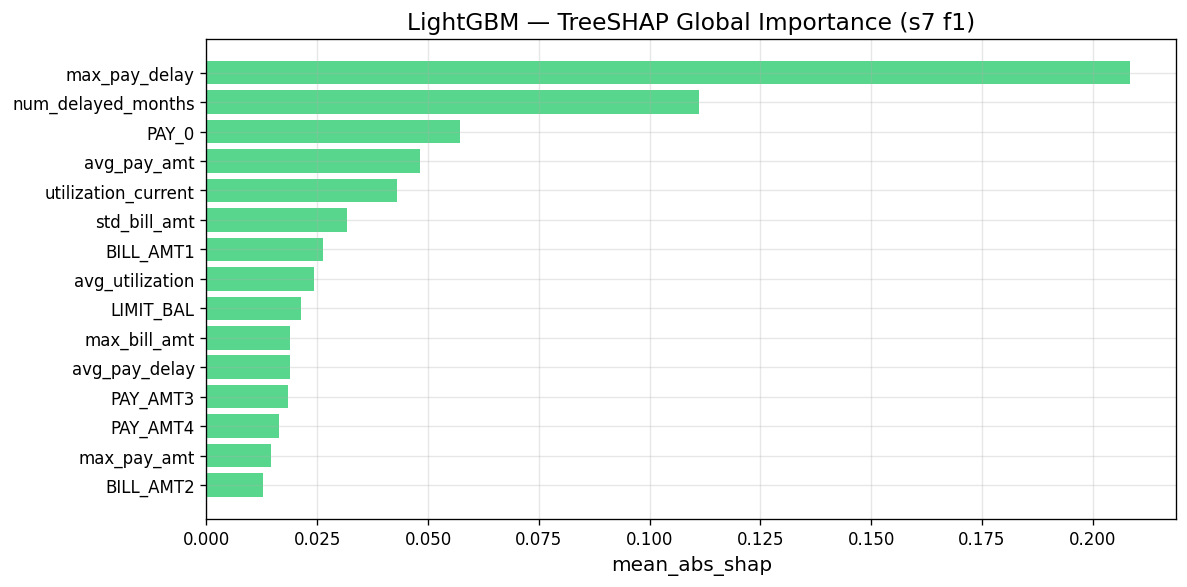

  Figure saved → importance_LightGBM_s7_f1.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s7_f1 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


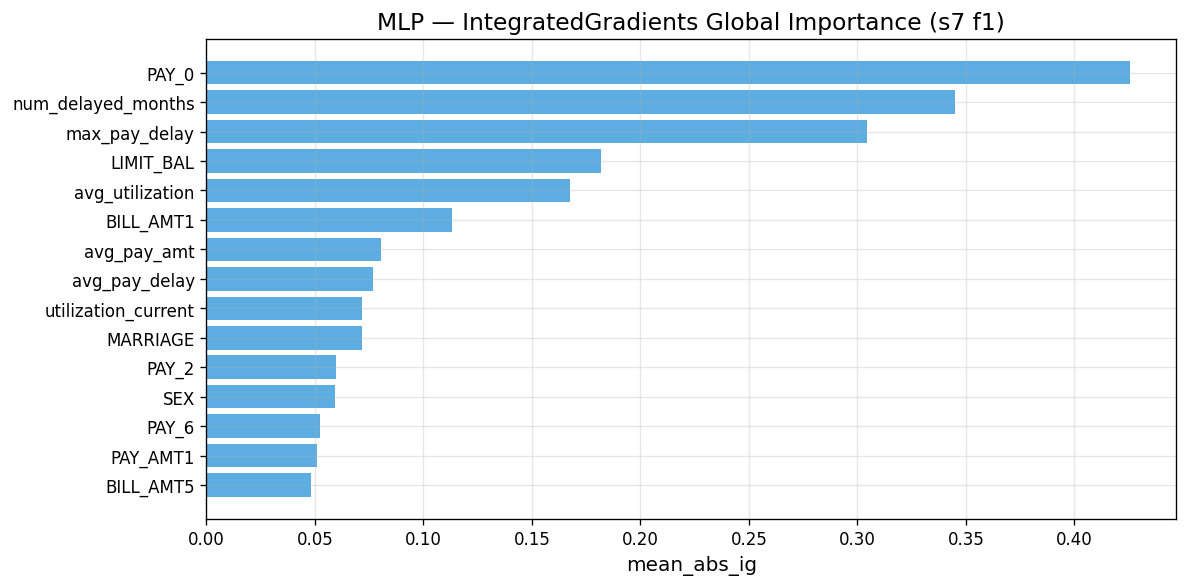

  Figure saved → importance_MLP_s7_f1.png & .pdf
  IntegratedGradients runtime: 0.32s

--- Explaining: TabNet_s7_f1 (500 samples) ---


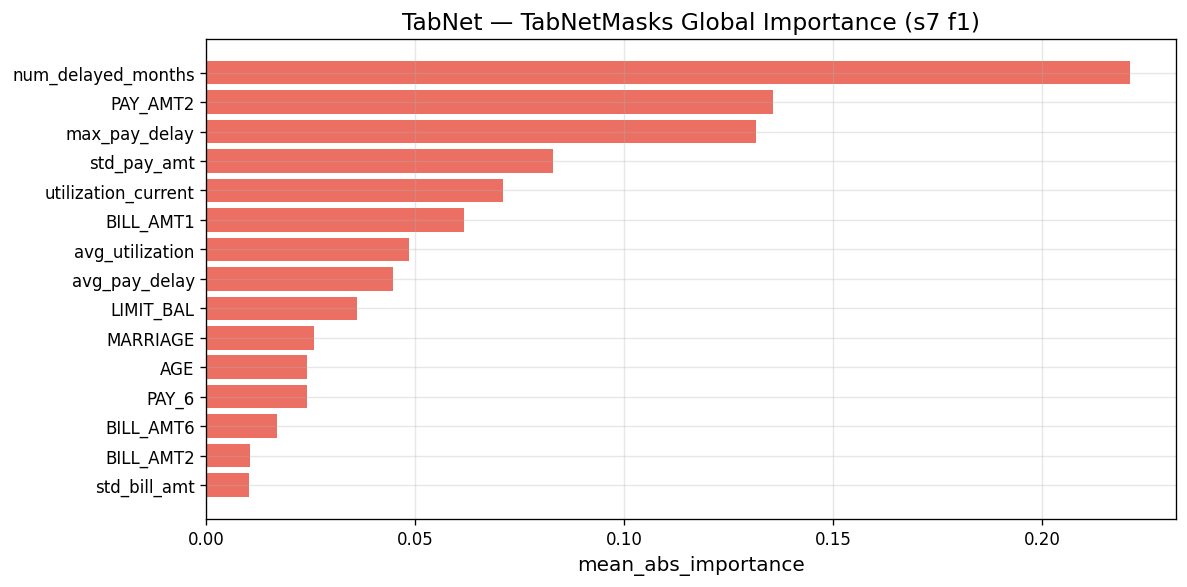

  Figure saved → importance_TabNet_s7_f1.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s7_f2 (500 samples) ---

--- Explaining: CatBoost_s7_f2 (500 samples) ---


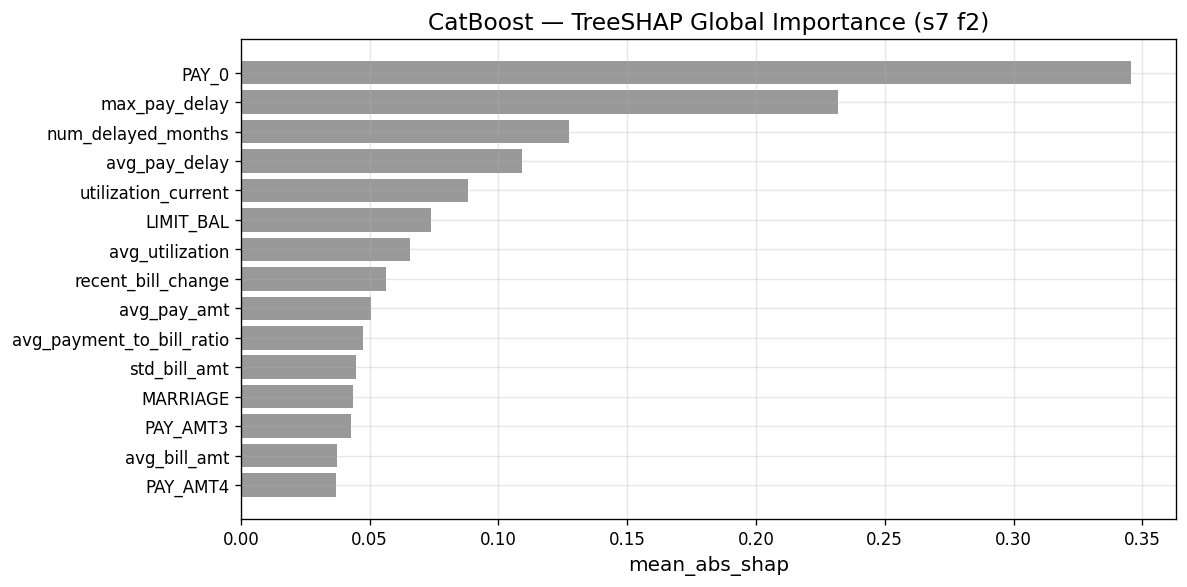

  Figure saved → importance_CatBoost_s7_f2.png & .pdf
  TreeSHAP runtime: 0.27s

--- Explaining: LightGBM_s7_f2 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


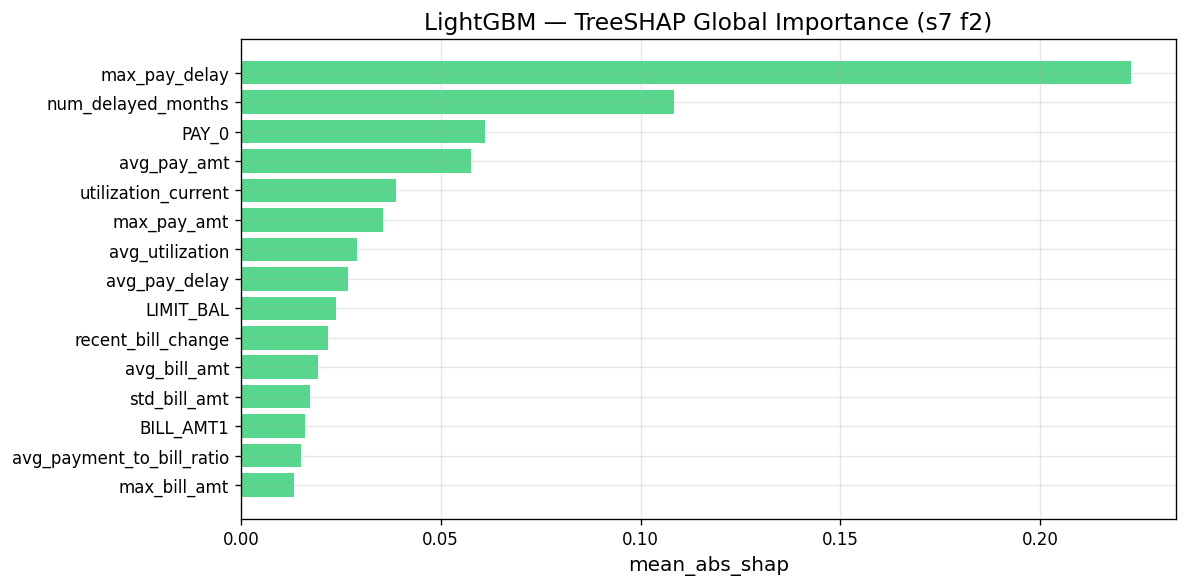

  Figure saved → importance_LightGBM_s7_f2.png & .pdf
  TreeSHAP runtime: 0.02s

--- Explaining: MLP_s7_f2 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


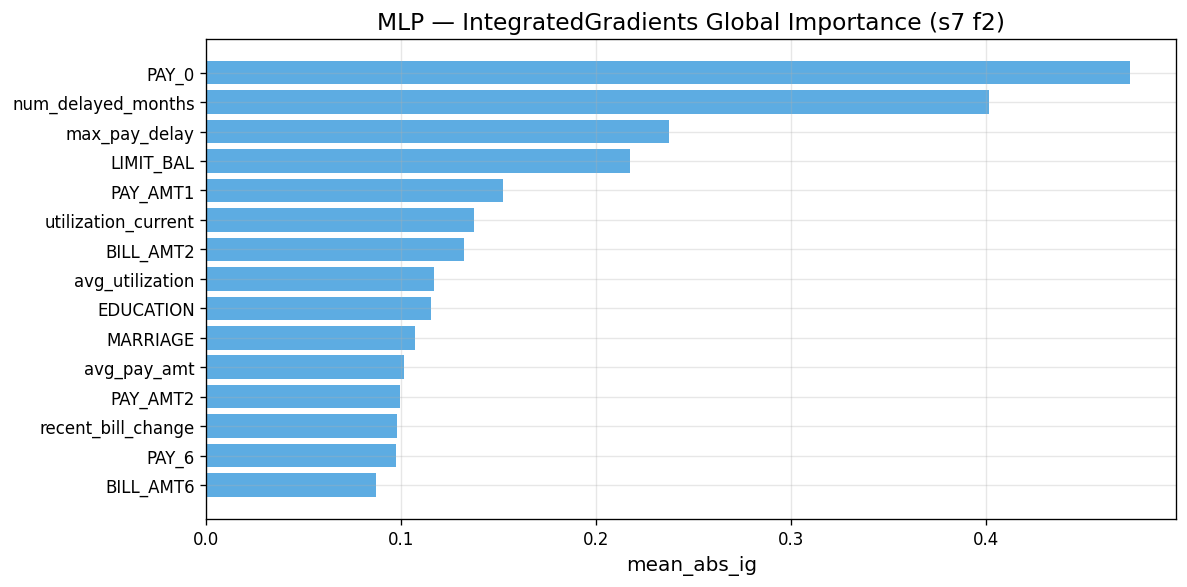

  Figure saved → importance_MLP_s7_f2.png & .pdf
  IntegratedGradients runtime: 0.30s

--- Explaining: TabNet_s7_f2 (500 samples) ---


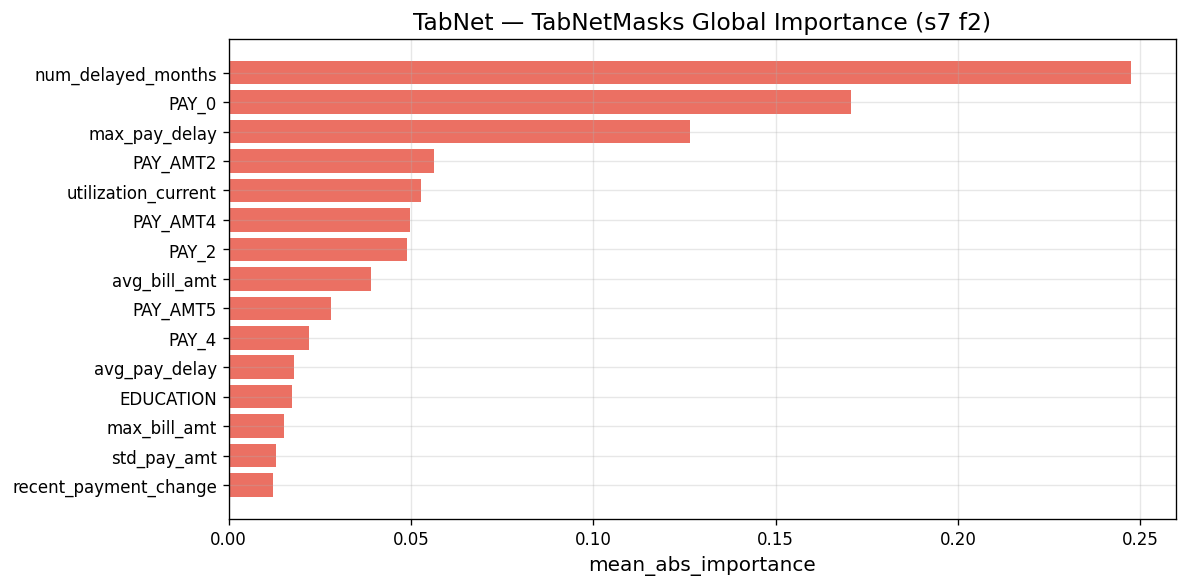

  Figure saved → importance_TabNet_s7_f2.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s7_f3 (500 samples) ---

--- Explaining: CatBoost_s7_f3 (500 samples) ---


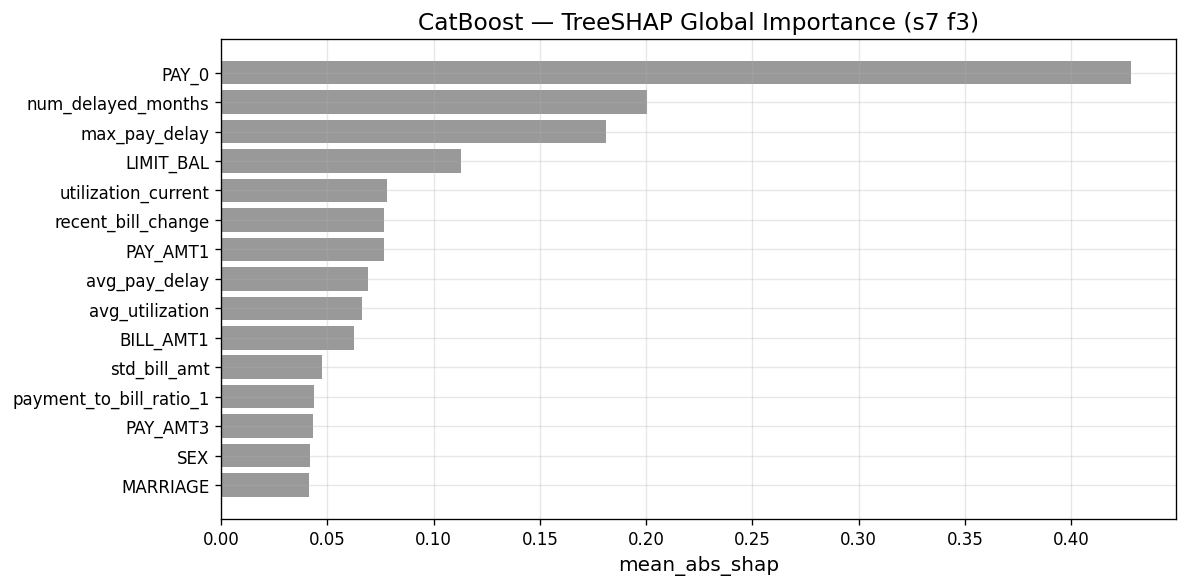

  Figure saved → importance_CatBoost_s7_f3.png & .pdf
  TreeSHAP runtime: 0.42s

--- Explaining: LightGBM_s7_f3 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


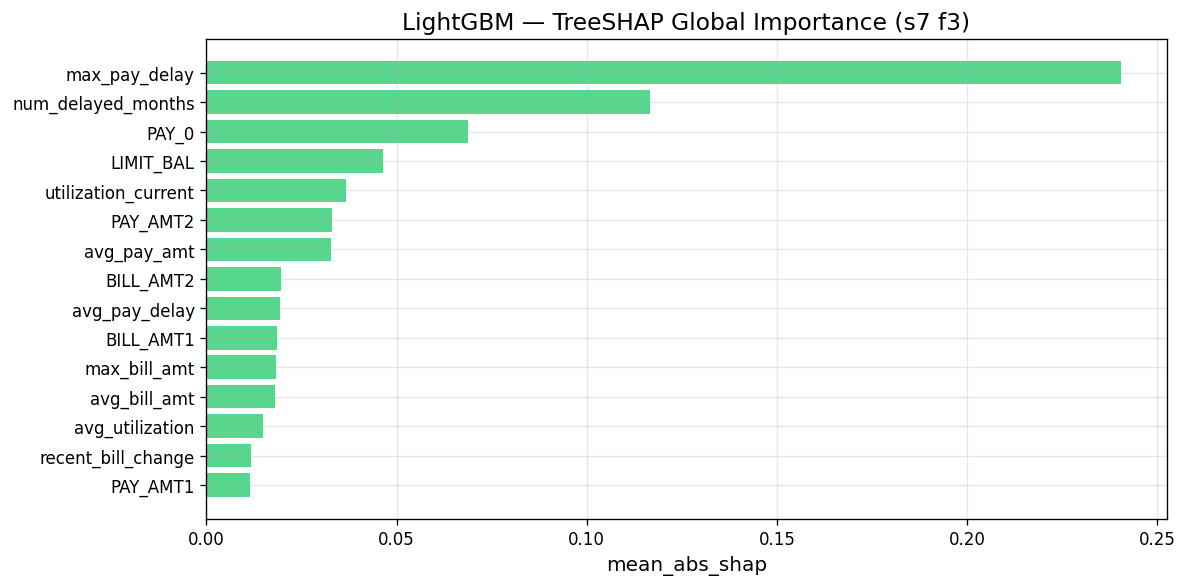

  Figure saved → importance_LightGBM_s7_f3.png & .pdf
  TreeSHAP runtime: 0.03s

--- Explaining: MLP_s7_f3 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


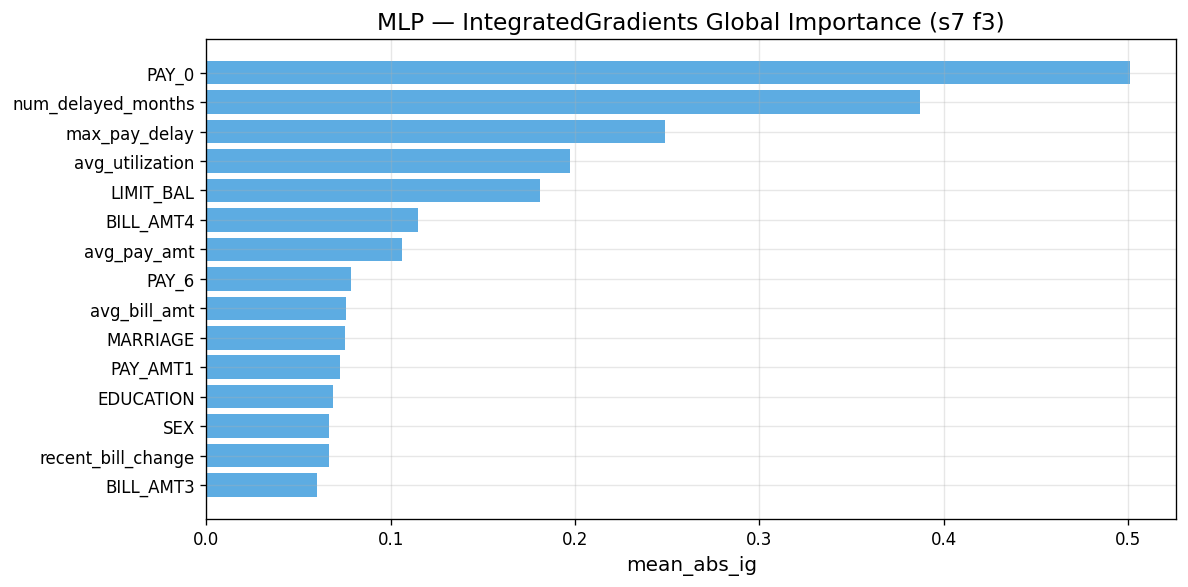

  Figure saved → importance_MLP_s7_f3.png & .pdf
  IntegratedGradients runtime: 0.35s

--- Explaining: TabNet_s7_f3 (500 samples) ---


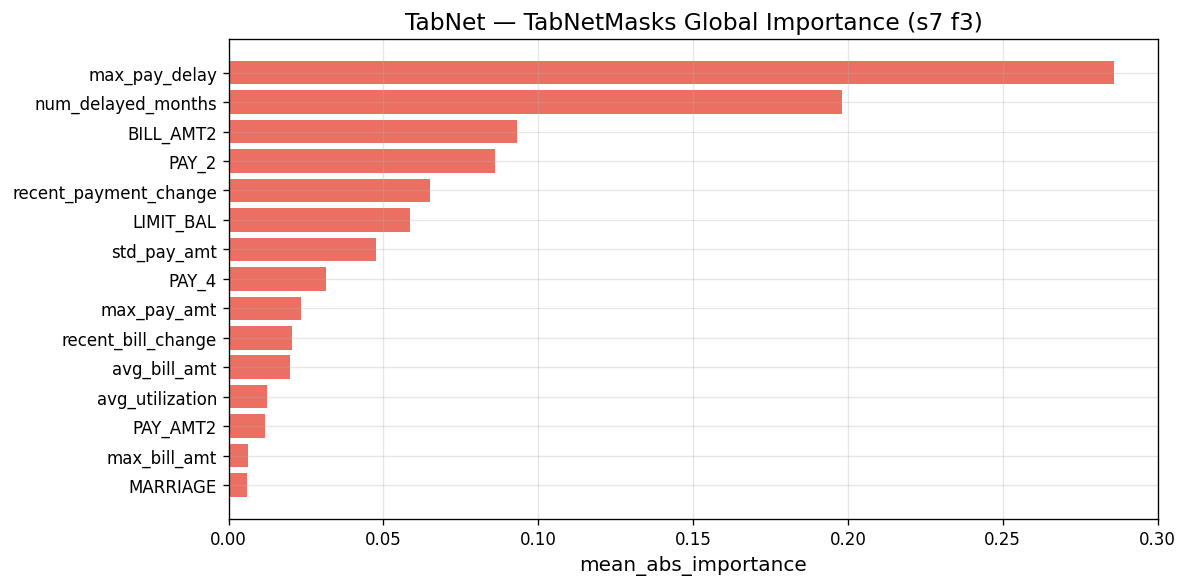

  Figure saved → importance_TabNet_s7_f3.png & .pdf
  TabNetMasks runtime: 0.02s

--- Explaining: LogisticRegression_s7_f4 (500 samples) ---

--- Explaining: CatBoost_s7_f4 (500 samples) ---


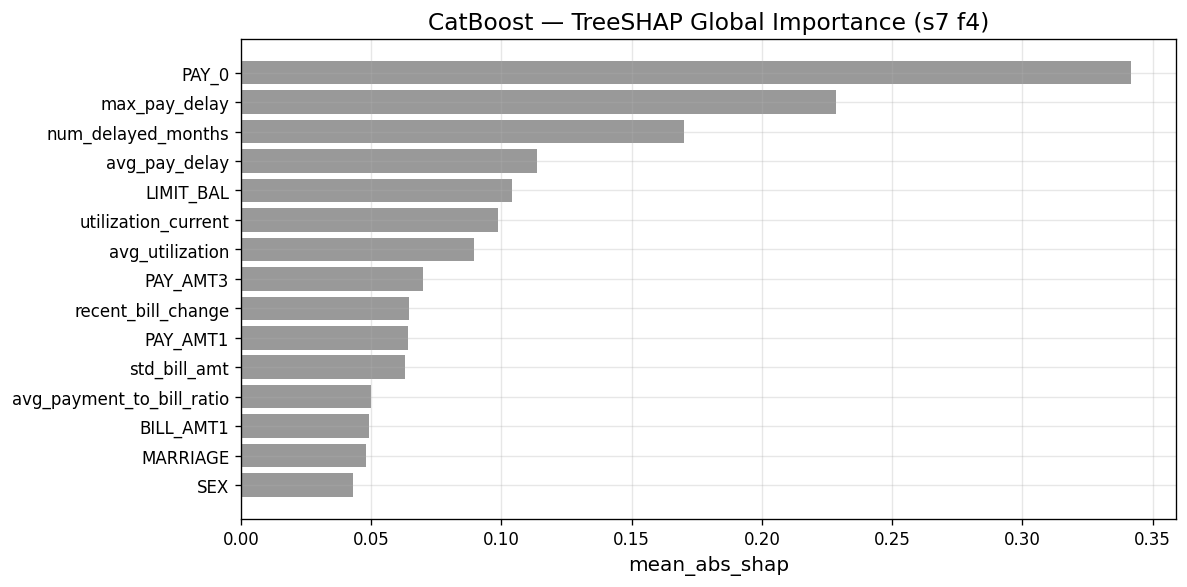

  Figure saved → importance_CatBoost_s7_f4.png & .pdf
  TreeSHAP runtime: 0.50s

--- Explaining: LightGBM_s7_f4 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


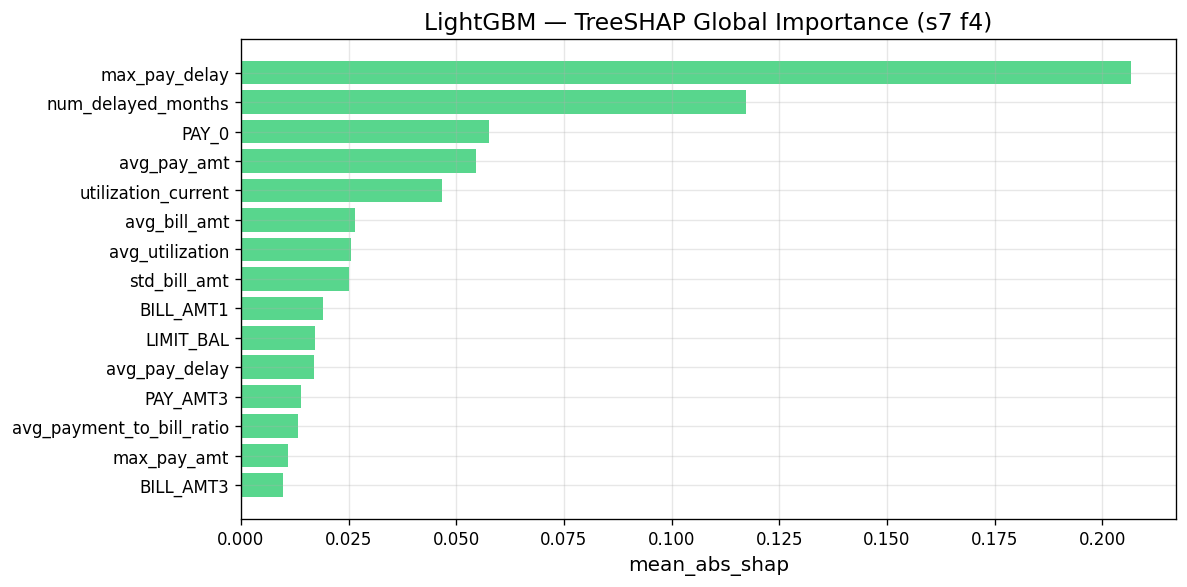

  Figure saved → importance_LightGBM_s7_f4.png & .pdf
  TreeSHAP runtime: 0.03s

--- Explaining: MLP_s7_f4 (500 samples) ---


/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 500 equal to the number of examples.
  warnings.warn(


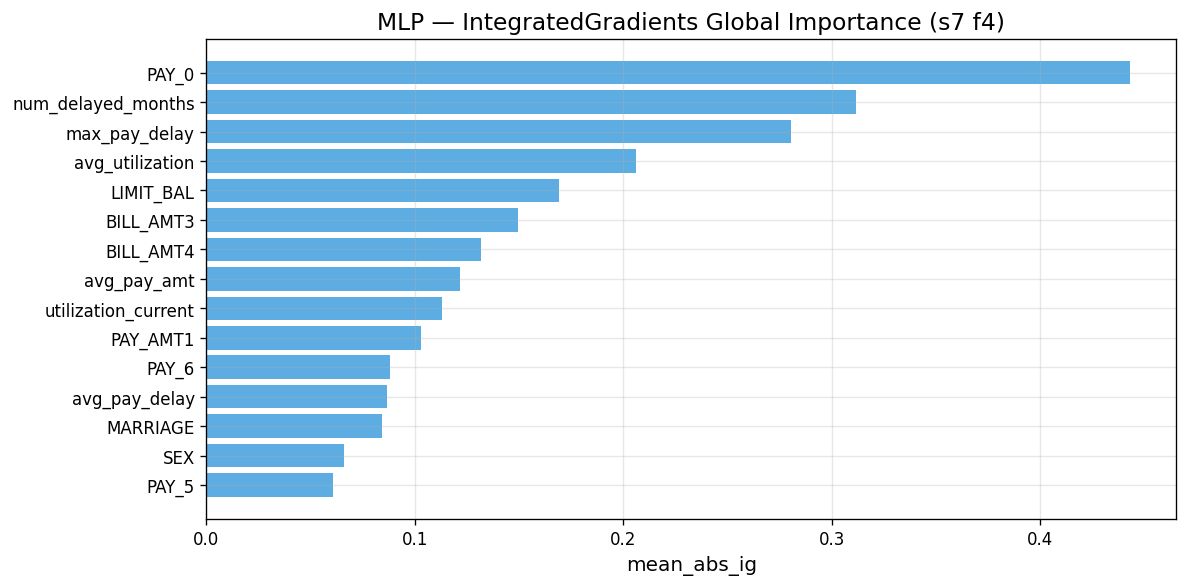

  Figure saved → importance_MLP_s7_f4.png & .pdf
  IntegratedGradients runtime: 0.31s

--- Explaining: TabNet_s7_f4 (500 samples) ---


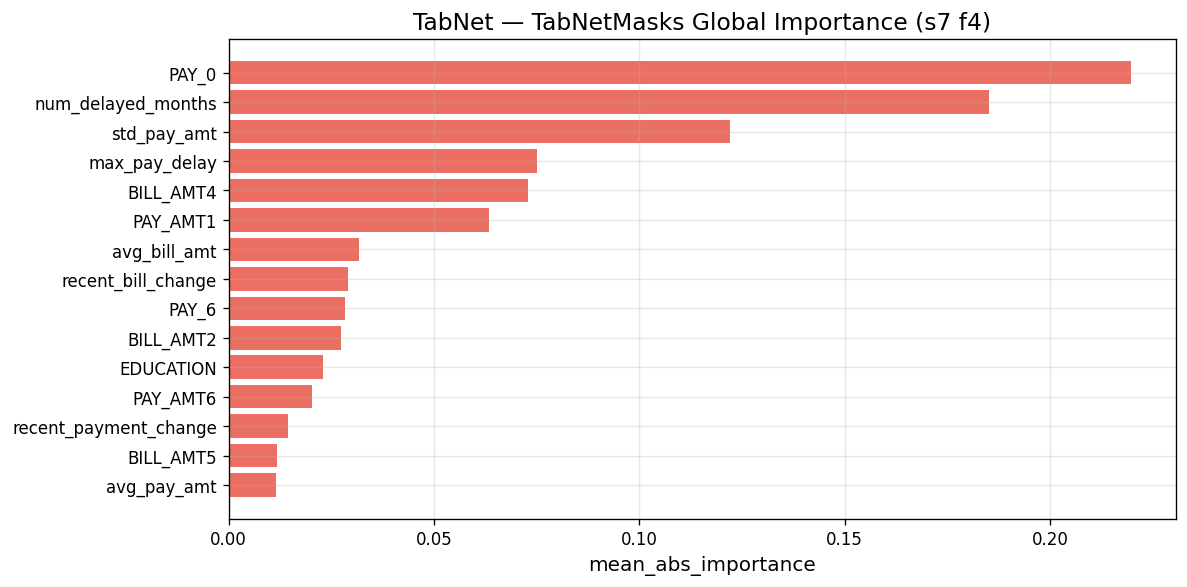

  Figure saved → importance_TabNet_s7_f4.png & .pdf
  TabNetMasks runtime: 0.02s

✓ All explanations computed: 120 method‑runs


In [122]:
# ──────────────────────────────────────────────────────────────
# 17‑B  Run all explanations
# ──────────────────────────────────────────────────────────────
explanation_results = []

for res in all_results:
    mn = res["model_name"]
    seed = res["seed"]
    fold_idx = res["fold"]
    tag = f"{mn}_s{seed}_f{fold_idx}"

    pp   = res["_preprocessor"]
    test_data = res["_test_data"]
    train_data = res["_train_data"]
    model_obj = res["_model_obj"]
    feature_names = pp.num_cols + pp.cat_cols

    # Select samples
    sample_idx = select_explanation_samples(
        test_data["y"], CFG.explanation_samples, seed=seed
    )

    print(f"\n--- Explaining: {tag} ({len(sample_idx)} samples) ---")

    if mn in ["LightGBM", "CatBoost"]:
        X_bg = None
        X_exp = pd.DataFrame(test_data["X_full"][sample_idx], columns=feature_names)
        if mn == "CatBoost":
            for c in pp.cat_cols:
                X_exp[c] = X_exp[c].astype(int)
        attrs, imp_df, rt = explain_tree_model(model_obj, X_bg, X_exp, feature_names)
        method = "TreeSHAP"

    elif mn == "MLP":
        X_num_exp = test_data["X_num"][sample_idx]
        X_cat_exp = test_data["X_cat"][sample_idx]
        attrs, imp_df, rt = explain_mlp_ig(
            model_obj, X_num_exp, X_cat_exp, pp,
            n_steps=CFG.ig_n_steps
        )
        method = "IntegratedGradients"

    elif mn == "TabNet":
        X_exp = test_data["X_full"][sample_idx]
        attrs, imp_df, rt = explain_tabnet_masks(model_obj, X_exp, feature_names)
        method = "TabNetMasks"

    elif mn == "LogisticRegression":
        continue
    else:
        continue
        
    # Add Model-Specific Random Baseline
    X_exp_rand = test_data["X_full"][sample_idx]
    attrs_rand, imp_df_rand, rt_rand = explain_random_baseline(X_exp_rand, feature_names, seed)
    explanation_results.append({
        "model_name": f"Random-{mn}", "method": "Random",
        "reference_model_name": mn,
        "seed": seed, "fold": fold_idx,
        "n_samples": len(sample_idx),
        "runtime": rt_rand,
        "attrs": attrs_rand,
        "feature_names": feature_names,
        "sample_idx": sample_idx,
    })

    if attrs is not None:
        # Save attributions
        attr_df = pd.DataFrame(attrs, columns=feature_names)
        attr_df.to_csv(OUTPUT / "explanations" / f"attributions_{tag}.csv", index=False)

        # Save importance
        imp_df.to_csv(OUTPUT / "explanations" / f"importance_{tag}.csv", index=False)

        # Importance bar plot
        fig, ax = plt.subplots(figsize=(10, 5))
        top_n = min(15, len(imp_df))
        plot_data = imp_df.head(top_n).iloc[::-1]
        imp_col = [c for c in plot_data.columns if c != "feature"][0]
        ax.barh(plot_data["feature"], plot_data[imp_col],
                color=MODEL_COLORS.get(mn, "gray"), alpha=0.8)
        ax.set_xlabel(imp_col)
        ax.set_title(f"{mn} — {method} Global Importance (s{seed} f{fold_idx})")
        fig.tight_layout()
        save_fig(fig, f"importance_{tag}", "figures/xai")

    explanation_results.append({
        "model_name": mn, "method": method,
        "reference_model_name": mn,
        "seed": seed, "fold": fold_idx,
        "n_samples": len(sample_idx),
        "runtime": rt,
        "attrs": attrs,
        "feature_names": feature_names,
        "sample_idx": sample_idx,
    })
    print(f"  {method} runtime: {rt:.2f}s")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\n✓ All explanations computed: {len(explanation_results)} method‑runs")

## ***Section 18 — Faithfulness Metric***

### ***What this cell does***
Measures whether explanations **correctly identify features that genuinely affect the model’s
prediction**.  For each sample and top‑k value (k = 1, 3, 5, 10):
1. **Rank** features by absolute attribution.
2. **Mask** the top‑k features by replacing them with training‑fold medians (numerical) or
   modes (categorical).
3. **Recompute** the predicted probability.
4. **Faithfulness** = |original probability − masked probability| (higher ⇒ more faithful).

### ***Why it is needed***
An explanation is only useful if the features it highlights **actually matter** for the
prediction.  Faithfulness quantifies this:
- A high faithfulness score means masking the top‑k features substantially changes the
  prediction — confirming the explanation correctly identified influential features.
- A low faithfulness score suggests the explanation misidentifies feature importance.

**Masking design**: We replace masked features with **realistic baseline values** (training
medians/modes) rather than zeros, which could produce out‑of‑distribution inputs and
inflate faithfulness scores artificially.

### ***Expected output***
- `faithfulness_raw.csv` — per‑sample, per‑k probability changes.
- `faithfulness_summary.csv` — mean ± std per model/method/k.
- Faithfulness curve plot (x = k, y = mean |probability change|, one line per method).

In [123]:
# ──────────────────────────────────────────────────────────────
# 18‑A  Feature masking utility
# ──────────────────────────────────────────────────────────────
def mask_top_k_features_original_space(df_samples, explanation_row, feature_names, k, numeric_cols, categorical_cols, numeric_replacements, categorical_replacements):
    """Replace top‑k features (by ranking) with masking values in original DataFrame space.

    Args:
        df_samples: DataFrame of shape (n_samples, n_features)
        explanation_row: 1D array of shape (n_features,) representing feature attributions
        feature_names: list of feature names
        k: number of features to mask
        numeric_cols, categorical_cols: lists of feature names by type
        numeric_replacements, categorical_replacements: dicts mapping feature -> replacement value
    Returns:
        df_masked: DataFrame with top‑k features replaced.
        top_features: List of the top k feature names masked.
    """
    df_masked = df_samples.copy()
    ranked_idx = np.argsort(-np.abs(explanation_row))
    top_features = [feature_names[i] for i in ranked_idx[:k]]

    for feature in top_features:
        if feature in numeric_cols:
            df_masked[feature] = numeric_replacements[feature]
        elif feature in categorical_cols:
            df_masked[feature] = categorical_replacements[feature]
        else:
            raise ValueError(f"Unknown feature during masking: {feature}")

    return df_masked, top_features

print("✓ Feature masking utility defined.")

✓ Feature masking utility defined.


In [124]:
# ──────────────────────────────────────────────────────────────
# 18‑B  Predict wrapper for each model
# ──────────────────────────────────────────────────────────────
def get_predict_fn(model, model_name, preprocessor, device="cpu"):
    """Return a function: original space DataFrame -> probabilities."""
    if model_name in ["LightGBM", "LogisticRegression"]:
        return lambda df_x: model.predict_proba(pd.DataFrame(preprocessor.transform(df_x)["X_full"], columns=preprocessor.feature_names))[:, 1]
    elif model_name == "CatBoost":
        def catboost_predict(df_x):
            trans = preprocessor.transform(df_x)
            X_df = pd.DataFrame(trans["X_full"], columns=preprocessor.feature_names)
            for c in preprocessor.cat_cols:
                X_df[c] = X_df[c].astype(int)
            return model.predict_proba(X_df)[:, 1]
        return catboost_predict
    elif model_name == "TabNet":
        return lambda df_x: model.predict_proba(preprocessor.transform(df_x)["X_full"].astype(np.float32))[:, 1]
    elif model_name == "MLP":
        dev = next(model.parameters()).device
        def predict_fn(df_x):
            model.eval()
            trans = preprocessor.transform(df_x)
            with torch.no_grad():
                x_num = torch.tensor(trans["X_num"], dtype=torch.float32, device=dev)
                x_cat = torch.tensor(trans["X_cat"].astype(np.int64), dtype=torch.long, device=dev)
                logits = model(x_num, x_cat)
                return torch.sigmoid(logits).cpu().numpy()
        return predict_fn
    else:
        raise ValueError(f"Unknown model: {model_name}")

print("✓ Predict wrapper defined.")

✓ Predict wrapper defined.


In [125]:
# ──────────────────────────────────────────────────────────────
# 18‑C  Compute faithfulness
# ──────────────────────────────────────────────────────────────
faithfulness_records = []

for exp_res in explanation_results:
    mn = exp_res["model_name"]
    method = exp_res["method"]
    seed = exp_res["seed"]
    fold_idx = exp_res["fold"]
    attrs = exp_res["attrs"]
    sample_idx = exp_res["sample_idx"]

    if attrs is None:
        continue

    tag = f"{mn}_s{seed}_f{fold_idx}"

    # Get the matching model result
    model_name_for_pred = mn.split("-")[1] if mn.startswith("Random-") else mn
    model_res = [r for r in all_results
                 if r["model_name"] == model_name_for_pred and r["seed"] == seed and r["fold"] == fold_idx][0]
    model_obj = model_res["_model_obj"]
    pp = model_res["_preprocessor"]
    test_data = model_res["_test_data"]

    # Get masking values and predict function
    num_repl = pp.num_medians
    cat_repl = pp.cat_modes
    predict_fn = get_predict_fn(model_obj, model_name_for_pred, pp)

    # Get full feature dataframe for explanation samples in original space
    df_sample = df.iloc[model_res["_test_idx"]].iloc[sample_idx].copy().reset_index(drop=True)

    # Original predictions
    orig_probs = predict_fn(df_sample)
    feature_names = pp.num_cols + pp.cat_cols

    for k in CFG.top_k_values:
        if k > attrs.shape[1]:
            continue
            
        prob_drops = []
        abs_changes = []
        
        # Mask and predict row by row because we need to use the specific attribution row
        for i in range(len(sample_idx)):
            single_row = df_sample.iloc[[i]].copy()
            masked_row, masked_feats = mask_top_k_features_original_space(
                single_row, attrs[i], feature_names, k, pp.num_cols, pp.cat_cols, num_repl, cat_repl
            )
            masked_prob = predict_fn(masked_row)[0]
            
            orig_p = orig_probs[i]
            p_drop = orig_p - masked_prob
            
            prob_drops.append(p_drop)
            abs_changes.append(np.abs(p_drop))
            
            faithfulness_records.append({
                "model_name": mn, "method": method,
                "reference_model_name": model_name_for_pred,
                "seed": seed, "fold": fold_idx,
                "sample_local_idx": i, "k": k,
                "original_prob": orig_p,
                "masked_prob": masked_prob,
                "signed_drop": p_drop,
                "abs_change": np.abs(p_drop),
                "masked_features": ", ".join(masked_feats)
            })

    print(f"  Faithfulness computed: {tag} ({method})")

faith_df = pd.DataFrame(faithfulness_records)
faith_df.to_csv(OUTPUT / "metrics" / "faithfulness_raw.csv", index=False)

# Summary
if not faith_df.empty:
    faith_summary = faith_df.groupby(["model_name", "reference_model_name", "method", "k"]).agg(
        abs_change_mean=("abs_change", "mean"),
        abs_change_std=("abs_change", "std"),
        signed_drop_mean=("signed_drop", "mean"),
        signed_drop_std=("signed_drop", "std"),
        n_samples=("sample_local_idx", "count"),
    ).reset_index()
    faith_summary.to_csv(OUTPUT / "metrics" / "faithfulness_summary.csv", index=False)

    real_faith = faith_summary[~faith_summary["model_name"].str.startswith("Random-")].copy()
    random_faith = faith_summary[faith_summary["model_name"].str.startswith("Random-")].copy()
    if not real_faith.empty and not random_faith.empty:
        model_specific_random_df = real_faith.merge(
            random_faith[
                [
                    "reference_model_name",
                    "k",
                    "abs_change_mean",
                    "abs_change_std",
                    "signed_drop_mean",
                    "signed_drop_std",
                    "n_samples",
                ]
            ].rename(
                columns={
                    "abs_change_mean": "random_abs_change_mean",
                    "abs_change_std": "random_abs_change_std",
                    "signed_drop_mean": "random_signed_drop_mean",
                    "signed_drop_std": "random_signed_drop_std",
                    "n_samples": "random_n_samples",
                }
            ),
            on=["reference_model_name", "k"],
            how="left",
        )
        model_specific_random_df["delta_vs_random_abs_change"] = (
            model_specific_random_df["abs_change_mean"] - model_specific_random_df["random_abs_change_mean"]
        )
        model_specific_random_df["delta_vs_random_signed_drop"] = (
            model_specific_random_df["signed_drop_mean"] - model_specific_random_df["random_signed_drop_mean"]
        )
        model_specific_random_df.to_csv(
            OUTPUT / "metrics" / "model_specific_random_faithfulness.csv",
            index=False,
        )

    print("\n📊 Faithfulness Summary:")
    print(faith_summary.to_string(index=False, float_format="%.4f"))

  Faithfulness computed: Random-CatBoost_s42_f0 (Random)
  Faithfulness computed: CatBoost_s42_f0 (TreeSHAP)
  Faithfulness computed: Random-LightGBM_s42_f0 (Random)
  Faithfulness computed: LightGBM_s42_f0 (TreeSHAP)
  Faithfulness computed: Random-MLP_s42_f0 (Random)
  Faithfulness computed: MLP_s42_f0 (IntegratedGradients)
  Faithfulness computed: Random-TabNet_s42_f0 (Random)
  Faithfulness computed: TabNet_s42_f0 (TabNetMasks)
  Faithfulness computed: Random-CatBoost_s42_f1 (Random)
  Faithfulness computed: CatBoost_s42_f1 (TreeSHAP)
  Faithfulness computed: Random-LightGBM_s42_f1 (Random)
  Faithfulness computed: LightGBM_s42_f1 (TreeSHAP)
  Faithfulness computed: Random-MLP_s42_f1 (Random)
  Faithfulness computed: MLP_s42_f1 (IntegratedGradients)
  Faithfulness computed: Random-TabNet_s42_f1 (Random)
  Faithfulness computed: TabNet_s42_f1 (TabNetMasks)
  Faithfulness computed: Random-CatBoost_s42_f2 (Random)
  Faithfulness computed: CatBoost_s42_f2 (TreeSHAP)
  Faithfulness comp

  Faithfulness computed: LightGBM_s42_f0 (TreeSHAP)


  Faithfulness computed: Random-MLP_s42_f0 (Random)


  Faithfulness computed: MLP_s42_f0 (IntegratedGradients)


  Faithfulness computed: Random-TabNet_s42_f0 (Random)


  Faithfulness computed: TabNet_s42_f0 (TabNetMasks)

📊 Faithfulness Summary:
     model_name reference_model_name              method  k  abs_change_mean  abs_change_std  signed_drop_mean  signed_drop_std  n_samples
       CatBoost             CatBoost            TreeSHAP  1           0.1027          0.1091            0.0851           0.1236         50
       CatBoost             CatBoost            TreeSHAP  3           0.1883          0.1488            0.1499           0.1881         50
       CatBoost             CatBoost            TreeSHAP  5           0.2379          0.1837            0.1940           0.2304         50
       CatBoost             CatBoost            TreeSHAP 10           0.2686          0.2143            0.2324           0.2538         50
       LightGBM             LightGBM            TreeSHAP  1           0.0445          0.0685            0.0438           0.0689         50
       LightGBM             LightGBM            TreeSHAP  3           0.0809          0.

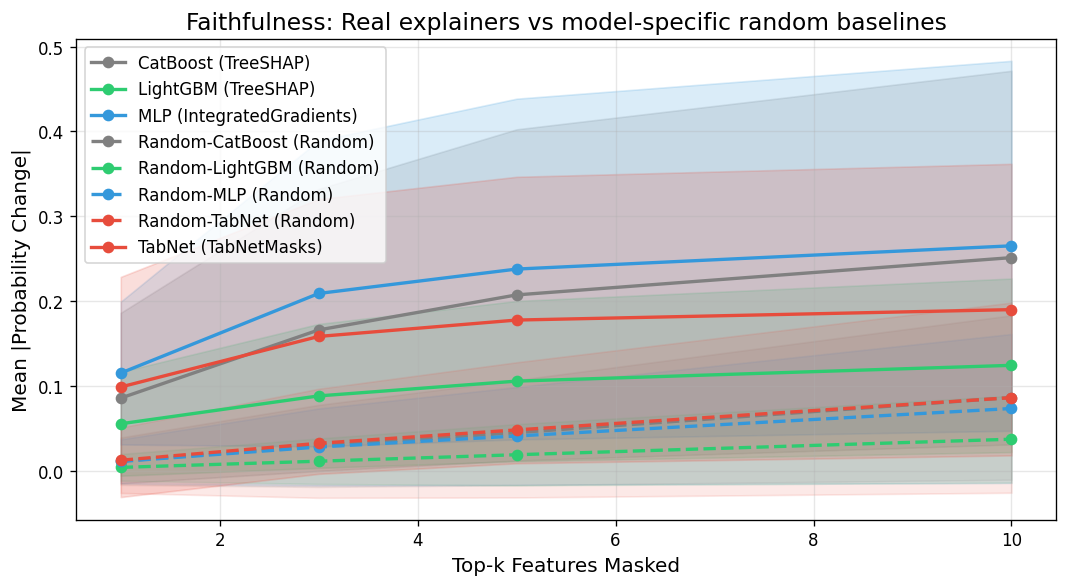

  Figure saved → faithfulness_curves.png & .pdf
✓ Faithfulness plot saved.


In [126]:
# ──────────────────────────────────────────────────────────────
# 18‑D  Faithfulness curve plot
# ──────────────────────────────────────────────────────────────
if not faith_df.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    for (mn, method), grp in faith_summary.groupby(["model_name", "method"]):
        label = f"{mn} ({method})"
        base_name = mn.replace("Random-", "")
        linestyle = "--" if mn.startswith("Random-") else "-"
        ax.plot(grp["k"], grp["abs_change_mean"], marker="o",
                label=label, color=MODEL_COLORS.get(base_name, "gray"), linewidth=2,
                linestyle=linestyle)
        ax.fill_between(grp["k"],
                        grp["abs_change_mean"] - grp["abs_change_std"],
                        grp["abs_change_mean"] + grp["abs_change_std"],
                        alpha=0.12 if mn.startswith("Random-") else 0.18,
                        color=MODEL_COLORS.get(base_name, "gray"))

    ax.set_xlabel("Top‑k Features Masked")
    ax.set_ylabel("Mean |Probability Change|")
    ax.set_title("Faithfulness: Real explainers vs model-specific random baselines")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, "faithfulness_curves", "figures/xai")
    print("✓ Faithfulness plot saved.")

## ***Section 19 — Stability Metric***

### ***What this cell does***
Measures explanation stability using **Spearman rank correlation (ρ)** between global
feature‑importance rankings across different random seeds and folds.

### ***Why it is needed***
A stable explanation method must produce **consistent feature rankings** regardless of the
data split.  Stability is a prerequisite for trustworthiness in production environments:
- **Low stability**: Explanations that fluctuate wildly are a liability for regulatory
  compliance and stakeholder trust.
- **High stability**: Ensures consistent, actionable insights across multiple training runs.

We compute pairwise Spearman ρ values; a value approaching **1.0 indicates maximum
stability**.

### ***Expected output***
- Pairwise stability metrics per model/method.
- `stability_summary.csv` — mean ± std Spearman ρ.
- Stability comparison bar chart (summarizing cross‑run consistency).

In [127]:
# ──────────────────────────────────────────────────────────────
# 19‑A  Compute stability
# ──────────────────────────────────────────────────────────────
stability_records = []

# Group explanation results by (model, method)
from collections import defaultdict
exp_groups = defaultdict(list)
for exp_res in explanation_results:
    if exp_res["attrs"] is not None:
        key = (exp_res["model_name"], exp_res["method"])
        # Compute global importance for this run
        global_imp = np.abs(exp_res["attrs"]).mean(axis=0)
        exp_groups[key].append({
            "seed": exp_res["seed"],
            "fold": exp_res["fold"],
            "global_importance": global_imp,
        })

for (mn, method), runs in exp_groups.items():
    if len(runs) < 2:
        stability_records.append({
            "model_name": mn, "method": method,
            "n_pairs": 0, "mean_spearman": np.nan, "std_spearman": np.nan,
            "status": "insufficient_data"
        })
        msg = f"Stability requires ≥2 runs. Insufficient data for {mn} ({method})."
        print(f"  ⚠ {msg}")
        if "EXECUTION_WARNINGS_ERRORS" in globals():
            EXECUTION_WARNINGS_ERRORS.append({"type": "stability", "message": msg})
        continue

    correlations = []
    for i in range(len(runs)):
        for j in range(i + 1, len(runs)):
            rho, _ = spearmanr(runs[i]["global_importance"],
                               runs[j]["global_importance"])
            correlations.append(rho)

    stability_records.append({
        "model_name": mn, "method": method,
        "n_pairs": len(correlations),
        "mean_spearman": np.mean(correlations),
        "std_spearman": np.std(correlations),
        "min_spearman": np.min(correlations),
        "max_spearman": np.max(correlations),
    })

stability_df = pd.DataFrame(stability_records)
stability_df.to_csv(OUTPUT / "metrics" / "stability_summary.csv", index=False)

print("\n📊 Explanation Stability (Spearman Rank Correlation):")
print(stability_df.to_string(index=False, float_format="%.4f"))


📊 Explanation Stability (Spearman Rank Correlation):
     model_name              method  n_pairs  mean_spearman  std_spearman  min_spearman  max_spearman
Random-CatBoost              Random      105         0.3494        0.4273       -0.0697        1.0000
       CatBoost            TreeSHAP      105         0.8584        0.0310        0.7744        0.9188
Random-LightGBM              Random      105         0.3494        0.4273       -0.0697        1.0000
       LightGBM            TreeSHAP      105         0.8683        0.0418        0.7226        0.9547
     Random-MLP              Random      105         0.3494        0.4273       -0.0697        1.0000
            MLP IntegratedGradients      105         0.7877        0.0571        0.6087        0.9179
  Random-TabNet              Random      105         0.3494        0.4273       -0.0697        1.0000
         TabNet         TabNetMasks      105         0.2394        0.1234       -0.0117        0.5931


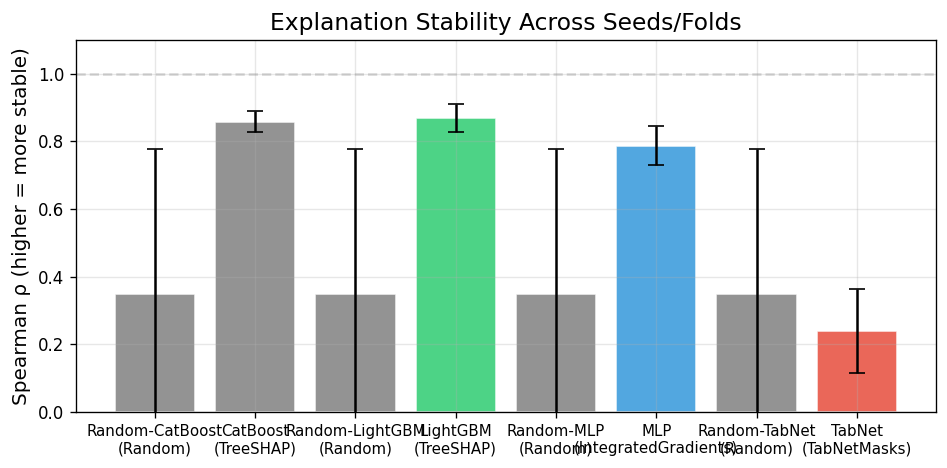

  Figure saved → stability_comparison.png & .pdf
✓ Stability plot saved.


In [128]:
# ──────────────────────────────────────────────────────────────
# 19‑B  Stability comparison plot
# ──────────────────────────────────────────────────────────────
if not stability_df.empty and stability_df["mean_spearman"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4))
    valid = stability_df.dropna(subset=["mean_spearman"])
    labels = [f"{r['model_name']}\n({r['method']})" for _, r in valid.iterrows()]
    means = valid["mean_spearman"].values
    stds  = valid["std_spearman"].fillna(0).values
    colors_bar = [MODEL_COLORS.get(r["model_name"], "gray") for _, r in valid.iterrows()]

    bars = ax.bar(range(len(labels)), means, yerr=stds, color=colors_bar,
                  capsize=5, alpha=0.85, edgecolor="white")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Spearman ρ (higher = more stable)")
    ax.set_title("Explanation Stability Across Seeds/Folds")
    ax.set_ylim(0, 1.1)
    ax.axhline(1.0, color="gray", linestyle="--", alpha=0.3)
    fig.tight_layout()
    save_fig(fig, "stability_comparison", "figures/xai")
    print("✓ Stability plot saved.")
else:
    print("⚠ Not enough runs to compute stability (need ≥2 folds/seeds).")

## ***Section 20 — Runtime Efficiency Analysis***

### ***What this cell does***
Aggregates and visualises training and explanation runtimes across all models and methods.

### ***Why it is needed***
Runtime is a **key contribution** of this study: we demonstrate that rigorous XAI evaluation
is feasible under Kaggle Free Tier compute constraints.  The analysis answers:
- **Training cost**: Which model family is cheapest to train?
- **Explanation cost**: What is the per‑sample cost of each explanation method?
- **Deployment trade‑offs**: A faster explanation with similar faithfulness is more
  deployment‑friendly for real‑time credit‑scoring systems.

### ***Expected output***
- `runtime_summary.csv` — training times per model.
- `explanation_runtime_summary.csv` — explanation times per method.
- Training runtime bar chart and explanation cost per sample bar chart.

In [129]:
# ──────────────────────────────────────────────────────────────
# 20‑A  Aggregate runtimes
# ──────────────────────────────────────────────────────────────
# Training runtimes
train_rt = results_df.groupby("model_name")["runtime"].agg(["mean", "std"]).reset_index()
train_rt.columns = ["model", "train_time_mean", "train_time_std"]

# Explanation runtimes
exp_rt_records = []
for exp_res in explanation_results:
    exp_rt_records.append({
        "model_name": exp_res["model_name"],
        "method": exp_res["method"],
        "explain_runtime": exp_res["runtime"],
        "n_samples": exp_res["n_samples"],
        "time_per_sample": exp_res["runtime"] / max(exp_res["n_samples"], 1),
    })
exp_rt_df = pd.DataFrame(exp_rt_records)

if not exp_rt_df.empty:
    exp_rt_summary = exp_rt_df.groupby(["model_name", "method"]).agg(
        explain_time_mean=("explain_runtime", "mean"),
        explain_time_std=("explain_runtime", "std"),
        time_per_sample_mean=("time_per_sample", "mean"),
    ).reset_index()
else:
    exp_rt_summary = pd.DataFrame()

# Merge into one table
runtime_full = train_rt.copy()
runtime_full.to_csv(OUTPUT / "metrics" / "runtime_summary.csv", index=False)
if not exp_rt_summary.empty:
    exp_rt_summary.to_csv(OUTPUT / "metrics" / "explanation_runtime_summary.csv", index=False)

print("\n📊 Training Runtimes:")
print(train_rt.to_string(index=False, float_format="%.2f"))
if not exp_rt_summary.empty:
    print("\n📊 Explanation Runtimes:")
    print(exp_rt_summary.to_string(index=False, float_format="%.4f"))


📊 Training Runtimes:
             model  train_time_mean  train_time_std
          CatBoost            10.70            2.31
          LightGBM             0.21            0.02
LogisticRegression             1.69            0.19
               MLP             9.91            2.74
            TabNet            30.85            7.36

📊 Explanation Runtimes:
     model_name              method  explain_time_mean  explain_time_std  time_per_sample_mean
       CatBoost            TreeSHAP             0.3609            0.0796                0.0007
       LightGBM            TreeSHAP             0.0232            0.0031                0.0000
            MLP IntegratedGradients             0.3068            0.0141                0.0006
Random-CatBoost              Random             0.0000            0.0000                0.0000
Random-LightGBM              Random             0.0000            0.0000                0.0000
     Random-MLP              Random             0.0000            0.000

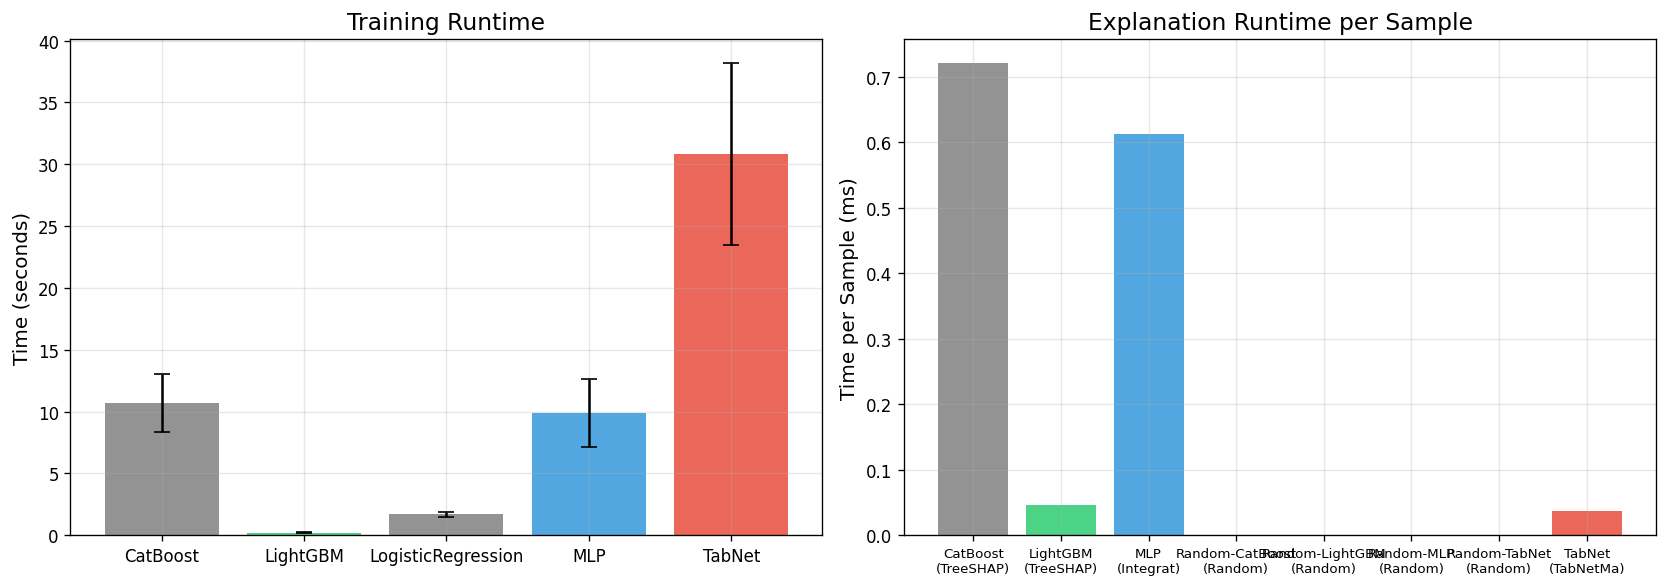

  Figure saved → runtime_comparison.png & .pdf
✓ Runtime plots saved.


In [130]:
# ──────────────────────────────────────────────────────────────
# 20‑B  Runtime bar charts
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training time
ax = axes[0]
for i, row in train_rt.iterrows():
    ax.bar(row["model"], row["train_time_mean"],
           yerr=row["train_time_std"], color=MODEL_COLORS.get(row["model"], "gray"),
           capsize=5, alpha=0.85)
ax.set_ylabel("Time (seconds)")
ax.set_title("Training Runtime")

# Explanation time per sample
ax = axes[1]
if not exp_rt_summary.empty:
    labels = [f"{r['model_name']}\n({r['method'][:8]})" for _, r in exp_rt_summary.iterrows()]
    vals = exp_rt_summary["time_per_sample_mean"].values
    colors_rt = [MODEL_COLORS.get(r["model_name"], "gray") for _, r in exp_rt_summary.iterrows()]
    ax.bar(range(len(labels)), vals * 1000, color=colors_rt, alpha=0.85)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Time per Sample (ms)")
    ax.set_title("Explanation Runtime per Sample")

fig.tight_layout()
save_fig(fig, "runtime_comparison", "figures/xai")
print("✓ Runtime plots saved.")

## ***Section 21 — Permutation Importance Alignment***

### ***What this cell does***
Calculates the model-agnostic Permutation Importance for each model on the test set, and measures how well each explanation method's global feature ranking aligns with this true performance-drop ranking using top-K overlap and Spearman correlation.

### ***Why it is needed***
A faithful explanation should assign high importance to features that actually degrade predictive performance when permuted. This provides a ground-truth global ranking to evaluate explanation quality.

In [131]:
# ──────────────────────────────────────────────────────────────
# 21‑A  Compute Permutation Importance Alignment
# ──────────────────────────────────────────────────────────────
from sklearn.inspection import permutation_importance

perm_records = []

for exp_res in explanation_results:
    mn = exp_res["model_name"]
    method = exp_res["method"]
    seed = exp_res["seed"]
    fold_idx = exp_res["fold"]
    
    if exp_res["attrs"] is None: continue
    
    # Get model and data
    model_name_for_pred = mn.split("-")[1] if mn.startswith("Random-") else mn
    model_res = [r for r in all_results if r["model_name"] == model_name_for_pred and r["seed"] == seed and r["fold"] == fold_idx][0]
    model_obj = model_res["_model_obj"]
    pp = model_res["_preprocessor"]
    test_data = model_res["_test_data"]
    feature_names = pp.num_cols + pp.cat_cols
    
    # Predict wrapper for sklearn permutation_importance
    df_test = df.iloc[model_res["_test_idx"]].copy().reset_index(drop=True)
    predict_fn = get_predict_fn(model_obj, model_name_for_pred, pp)
    
    class ModelWrapper:
        def __init__(self):
            self.classes_ = np.array([0, 1])
            self._estimator_type = "classifier"
        def fit(self, X, y=None):
            return self
        def predict(self, X):
            return (predict_fn(pd.DataFrame(X, columns=feature_names)) >= 0.5).astype(int)
            
    # Calculate permutation importance on a small sample to save time
    sub_idx = select_explanation_samples(test_data["y"], 500, seed=seed) if len(test_data["y"]) > 500 else np.arange(len(test_data["y"]))
    df_sub = df_test.iloc[sub_idx]
    y_sub = test_data["y"][sub_idx]
    
    wrapper = ModelWrapper()
    pi = permutation_importance(wrapper, df_sub[feature_names].values, y_sub, n_repeats=5, random_state=seed, scoring="f1")
    
    pi_ranking = np.argsort(-pi.importances_mean)
    exp_global = np.abs(exp_res["attrs"]).mean(axis=0)
    exp_ranking = np.argsort(-exp_global)
    
    # Top-K overlap
    for k in [3, 5, 10]:
        overlap = len(set(pi_ranking[:k]).intersection(set(exp_ranking[:k]))) / k
        perm_records.append({
            "model_name": mn, "method": method, "seed": seed, "fold": fold_idx,
            "k": k, "overlap": overlap
        })

perm_df = pd.DataFrame(perm_records)
if not perm_df.empty:
    perm_df.to_csv(OUTPUT / "metrics" / "permutation_alignment.csv", index=False)
    perm_summary = perm_df.groupby(["model_name", "method", "k"])["overlap"].mean().reset_index()
    print("\n📊 Permutation Importance Alignment (Top-K Overlap):")
    print(perm_summary.pivot(index=["model_name", "method"], columns="k", values="overlap").to_string(float_format="%.4f"))



📊 Permutation Importance Alignment (Top-K Overlap):
k                                       3      5      10
model_name      method                                  
CatBoost        TreeSHAP            0.4444 0.3467 0.4200
LightGBM        TreeSHAP            0.8444 0.6000 0.5533
MLP             IntegratedGradients 0.4889 0.5200 0.4733
Random-CatBoost Random              0.0000 0.0667 0.3400
Random-LightGBM Random              0.0000 0.0000 0.2400
Random-MLP      Random              0.0444 0.0933 0.2333
Random-TabNet   Random              0.0222 0.0800 0.2867
TabNet          TabNetMasks         0.6667 0.5867 0.5267


## ***Section 22 — Local Case Studies***

### ***What this cell does***
Extracts specific True Positive, True Negative, False Positive, and False Negative examples for the best predictive model. Compares the top-5 features highlighted by different explanation methods for these individual cases.

### ***Why it is needed***
Global metrics are abstract. Providing concrete local examples of where the model succeeded and failed, along with what features drove those specific decisions, demonstrates the real-world utility of the XAI tools.

In [132]:
# ──────────────────────────────────────────────────────────────
# 22‑A  Extract Local Case Studies
# ──────────────────────────────────────────────────────────────
try:
    best_res = sorted(all_results, key=lambda x: x.get("test_roc_auc", 0), reverse=True)[0]
    best_mn = best_res["model_name"]
    best_seed = best_res["seed"]
    best_fold = best_res["fold"]
    best_tag = f"{best_mn}_s{best_seed}_f{best_fold}"
    
    preds = pd.read_csv(OUTPUT / "metrics" / f"predictions_{best_tag}.csv")
    test_idx_global = best_res["_test_idx"]
    df_test_raw = df_raw_features.iloc[test_idx_global].reset_index(drop=True)
    
    # Try to find CatBoost, MLP, TabNet explanations for this fold
    exp_cb = [e for e in explanation_results if e["model_name"] == "CatBoost" and e["seed"] == best_seed and e["fold"] == best_fold]
    exp_mlp = [e for e in explanation_results if e["model_name"] == "MLP" and e["seed"] == best_seed and e["fold"] == best_fold]
    exp_tab = [e for e in explanation_results if e["model_name"] == "TabNet" and e["seed"] == best_seed and e["fold"] == best_fold]
    
    if exp_cb and exp_mlp and exp_tab:
        cb_res = exp_cb[0]
        mlp_res = exp_mlp[0]
        tab_res = exp_tab[0]
        
        sample_indices = cb_res["sample_idx"]
        feature_names = cb_res["feature_names"]
        
        preds_subset = preds.iloc[sample_indices].copy().reset_index(drop=True)
        preds_subset["local_idx"] = np.arange(len(sample_indices))
        preds_subset["test_row_idx"] = sample_indices
        
        tp_subset = preds_subset[(preds_subset["y_true"] == 1) & (preds_subset["y_pred"] == 1)]
        tn_subset = preds_subset[(preds_subset["y_true"] == 0) & (preds_subset["y_pred"] == 0)]
        fp_subset = preds_subset[(preds_subset["y_true"] == 0) & (preds_subset["y_pred"] == 1)]
        fn_subset = preds_subset[(preds_subset["y_true"] == 1) & (preds_subset["y_pred"] == 0)]
        
        cases = {}
        if not tp_subset.empty: cases["TP"] = tp_subset.iloc[0]
        if not tn_subset.empty: cases["TN"] = tn_subset.iloc[0]
        if not fp_subset.empty: cases["FP"] = fp_subset.iloc[0]
        if not fn_subset.empty: cases["FN"] = fn_subset.iloc[0]
        
        case_records = []
        md_lines = ["# Local Case Studies\n"]
        
        print(f"\n🔎 Local Case Studies for {best_tag}:")
        for case_type, row in cases.items():
            loc_idx = int(row["local_idx"])
            test_row_idx = int(row["test_row_idx"])
            prob = row["y_prob"]
            true_label = row["y_true"]
            pred_label = row["y_pred"]
            
            # Raw features
            raw_features = df_test_raw.iloc[test_row_idx].to_dict()
            
            # Top 5 CatBoost
            cb_attr = np.abs(cb_res["attrs"][loc_idx])
            cb_top5 = [feature_names[i] for i in np.argsort(-cb_attr)[:5]]
            
            # Top 5 MLP
            mlp_attr = np.abs(mlp_res["attrs"][loc_idx])
            mlp_top5 = [feature_names[i] for i in np.argsort(-mlp_attr)[:5]]
            
            # Top 5 TabNet
            tab_attr = np.abs(tab_res["attrs"][loc_idx])
            tab_top5 = [feature_names[i] for i in np.argsort(-tab_attr)[:5]]
            
            record = {
                "case_type": case_type,
                "true_label": true_label,
                "pred_label": pred_label,
                "probability": prob,
                "CatBoost_Top5": ", ".join(cb_top5),
                "MLP_Top5": ", ".join(mlp_top5),
                "TabNet_Top5": ", ".join(tab_top5),
                "raw_features_json": json.dumps(raw_features, ensure_ascii=False),
            }
            record.update({f"raw_{feature}": value for feature, value in raw_features.items()})
            case_records.append(record)
            
            print(f"  {case_type} - Prob={prob:.4f}")
            
            md_lines.append(f"## {case_type} Case")
            md_lines.append(f"- **True Label**: {true_label}")
            md_lines.append(f"- **Predicted Label**: {pred_label} (Prob: {prob:.4f})")
            md_lines.append("- **Raw feature values:**")
            for feature, value in raw_features.items():
                md_lines.append(f"  - `{feature}`: {value}")
            md_lines.append(f"- **Top 5 CatBoost (SHAP)**: {', '.join(cb_top5)}")
            md_lines.append(f"- **Top 5 MLP (IG)**: {', '.join(mlp_top5)}")
            md_lines.append(f"- **Top 5 TabNet (Masks)**: {', '.join(tab_top5)}\n")
            
        case_df = pd.DataFrame(case_records)
        case_df.to_csv(OUTPUT / "metrics" / "local_case_studies_detailed.csv", index=False)
        with open(OUTPUT / "metrics" / "local_case_studies.md", "w") as f:
            f.write("\n".join(md_lines))
        print("✓ Detailed local case studies saved to CSV and MD.")
    else:
        print("Not all models had explanations to extract cases.")
except Exception as e:
    print(f"Could not extract case studies: {e}")



🔎 Local Case Studies for CatBoost_s2024_f2:
  TP - Prob=0.8978
  TN - Prob=0.2949
  FP - Prob=0.5512
  FN - Prob=0.2809
✓ Detailed local case studies saved to CSV and MD.


## ***Section 21 — Optional SMOTE‑NC / SMOTE‑ENN Ablation***

### ***What this cell does***
Only executed when `CFG.use_smote_ablation = True` (EXTENDED mode).

### ***Why it is needed***
SMOTE‑ENN can improve recall for the minority class, but it may **distort the training
distribution** and harm probability calibration.  This ablation compares:
- **No resampling + class weights** (our default approach)
- **SMOTE‑ENN + no class weights**

This is treated as an **optional ablation** — not the main experiment — because
class‑weighting is generally safer for credit‑risk applications where calibrated
probabilities are needed for risk scoring.

In [133]:
# ──────────────────────────────────────────────────────────────
# 21‑A  SMOTE ablation (optional)
# ──────────────────────────────────────────────────────────────
if CFG.use_smote_ablation and HAS_IMBLEARN:
    print("Running SMOTE‑ENN ablation ...")
    smote_results = []
    ft0 = fold_tasks[0]
    pp = TabularPreprocessor(CATEGORICAL_COLS, NUMERICAL_COLS)
    train_df_s = df.iloc[ft0["train_idx"]]
    val_df_s   = df.iloc[ft0["val_idx"]]
    test_df_s  = df.iloc[ft0["test_idx"]]

    train_data_s = pp.fit_transform(train_df_s)
    val_data_s   = pp.transform(val_df_s)
    test_data_s  = pp.transform(test_df_s)

    cat_idx = train_data_s["cat_col_indices_in_full"]

    try:
        smote_enn = SMOTEENN(
            smote=SMOTENC(categorical_features=cat_idx, random_state=42),
            random_state=42
        )
        X_res, y_res = smote_enn.fit_resample(train_data_s["X_full"], train_data_s["y"])

        # Train LightGBM on resampled data
        if HAS_LGB:
            model_smote = lgb.LGBMClassifier(
                n_estimators=500, learning_rate=0.05, max_depth=5,
                random_state=42, n_jobs=-1, verbose=-1,
            )
            model_smote.fit(X_res, y_res,
                           eval_set=[(val_data_s["X_full"], val_data_s["y"])],
                           eval_metric="auc",
                           callbacks=[lgb.early_stopping(20, verbose=False),
                                     lgb.log_evaluation(0)])

            y_test_prob_smote = model_smote.predict_proba(test_data_s["X_full"])[:, 1]
            thr = tune_threshold_on_val(val_data_s["y"],
                                        model_smote.predict_proba(val_data_s["X_full"])[:, 1])
            metrics_smote = evaluate_binary_predictions(test_data_s["y"], y_test_prob_smote, thr)
            metrics_smote["method"] = "SMOTE‑ENN + LightGBM"
            smote_results.append(metrics_smote)

            print(f"  SMOTE‑ENN resampled: {len(X_res)} (from {len(train_data_s['y'])})")
            print(f"  Test ROC‑AUC: {metrics_smote['roc_auc']:.4f}")
    except Exception as e:
        print(f"  SMOTE ablation failed: {e}")

    if smote_results:
        pd.DataFrame(smote_results).to_csv(OUTPUT / "metrics" / "smote_ablation.csv", index=False)
else:
    print("SMOTE ablation skipped (disabled or imbalanced‑learn not installed).")

Running SMOTE‑ENN ablation ...
  SMOTE‑ENN resampled: 19647 (from 20376)
  Test ROC‑AUC: 0.7796


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## ***Section 22 — Optional Infidelity Metric***

### ***What this cell does***
Only executed when `CFG.use_infidelity = True`.

### ***Why it is needed***
Infidelity (Yeh et al., 2019) measures whether the dot product of explanations and
random perturbations correctly predicts the actual model output change.  Lower infidelity
values indicate more faithful explanations.  This is computationally expensive, so it is
treated as an **optional supplement** to the main faithfulness metric.

In [134]:
# ──────────────────────────────────────────────────────────────
# 22‑A  Approximate infidelity (optional)
# ──────────────────────────────────────────────────────────────
if CFG.use_infidelity:
    print("Computing approximate infidelity ...")
    infidelity_records = []
    n_perturbations = 20

    for exp_res in explanation_results:
        if exp_res["attrs"] is None:
            continue
        mn = exp_res["model_name"]
        attrs = exp_res["attrs"]
        sample_idx = exp_res["sample_idx"]

        model_name_for_pred = mn.split("-")[1] if mn.startswith("Random-") else mn
        model_res = [r for r in all_results
                     if r["model_name"] == model_name_for_pred and r["seed"] == exp_res["seed"]
                     and r["fold"] == exp_res["fold"]][0]
        pp = model_res["_preprocessor"]
        test_data = model_res["_test_data"]
        model_obj = model_res["_model_obj"]

        def predict_transformed(X):
            if model_name_for_pred in ["LightGBM", "LogisticRegression"]:
                return model_obj.predict_proba(pd.DataFrame(X, columns=pp.feature_names))[:, 1]
            elif model_name_for_pred == "CatBoost":
                X_df = pd.DataFrame(X, columns=pp.feature_names)
                for c in pp.cat_cols:
                    X_df[c] = X_df[c].astype(int)
                return model_obj.predict_proba(X_df)[:, 1]
            elif model_name_for_pred == "TabNet":
                return model_obj.predict_proba(X.astype(np.float32))[:, 1]
            elif model_name_for_pred == "MLP":
                dev = next(model_obj.parameters()).device
                model_obj.eval()
                with torch.no_grad():
                    x_num = torch.tensor(X[:, :len(pp.num_cols)], dtype=torch.float32, device=dev)
                    x_cat = torch.tensor(X[:, len(pp.num_cols):].astype(np.int64), dtype=torch.long, device=dev)
                    return torch.sigmoid(model_obj(x_num, x_cat)).cpu().numpy()
            return None

        X_sample = test_data["X_full"][sample_idx]
        orig_probs = predict_transformed(X_sample)
        n_features = X_sample.shape[1]
        n_num = len(pp.num_cols)

        rng = np.random.RandomState(42)
        infid_scores = []

        for _ in range(n_perturbations):
            # Gaussian perturbation for numerical, random swap for categorical
            perturbation = np.zeros_like(X_sample)
            perturbation[:, :n_num] = rng.normal(0, 0.1, size=(len(X_sample), n_num))
            X_perturbed = X_sample.copy()
            X_perturbed[:, :n_num] += perturbation[:, :n_num]

            perturbed_probs = predict_transformed(X_perturbed)
            actual_change = orig_probs - perturbed_probs
            predicted_change = (attrs * perturbation[:, :attrs.shape[1]]).sum(axis=1)
            infid_scores.append(((actual_change - predicted_change) ** 2).mean())

        mean_infid = np.mean(infid_scores)
        infidelity_records.append({
            "model_name": mn, "method": exp_res["method"],
            "seed": exp_res["seed"], "fold": exp_res["fold"],
            "infidelity": mean_infid,
        })
        print(f"  {mn} infidelity: {mean_infid:.6f}")

    if infidelity_records:
        infid_df = pd.DataFrame(infidelity_records)
        infid_df.to_csv(OUTPUT / "metrics" / "infidelity.csv", index=False)
else:
    print("Infidelity computation skipped (disabled).")

Computing approximate infidelity ...
  Random-CatBoost infidelity: 0.293059
  CatBoost infidelity: 0.005898
  Random-LightGBM infidelity: 0.291047
  LightGBM infidelity: 0.002513
  Random-MLP infidelity: 0.289414
  MLP infidelity: 0.011155
  Random-TabNet infidelity: 0.289929
  TabNet infidelity: 0.003128
  Random-CatBoost infidelity: 0.294635
  CatBoost infidelity: 0.007071
  Random-LightGBM infidelity: 0.291363
  LightGBM infidelity: 0.002729
  Random-MLP infidelity: 0.289181
  MLP infidelity: 0.010721
  Random-TabNet infidelity: 0.291264
  TabNet infidelity: 0.003498
  Random-CatBoost infidelity: 0.295122
  CatBoost infidelity: 0.007930
  Random-LightGBM infidelity: 0.291879
  LightGBM infidelity: 0.003525
  Random-MLP infidelity: 0.289269
  MLP infidelity: 0.011343
  Random-TabNet infidelity: 0.289645
  TabNet infidelity: 0.002761
  Random-CatBoost infidelity: 0.290960
  CatBoost infidelity: 0.003523
  Random-LightGBM infidelity: 0.291643
  LightGBM infidelity: 0.002911
  Random-ML

## ***Section 21.5 — Group-wise Fairness Diagnostics***

### ***What this cell does***
Calculates disparate impact and equal opportunity metrics for a protected attribute (e.g., SEX or AGE), showing whether predictive performance and positive prediction rates are equitable across demographic groups.

### ***Why it is needed***
A credit risk model must not only be accurate and explainable, but also auditable. These groupwise diagnostics provide a descriptive view of performance differences across demographic attributes without making causal fairness claims.

In [135]:
# ──────────────────────────────────────────────────────────────
# 21.5-A  Compute Fairness Diagnostics
# ──────────────────────────────────────────────────────────────
fairness_records = []

protected_attrs = [attr for attr in ["SEX", "EDUCATION", "MARRIAGE"] if attr in df.columns]

if protected_attrs:
    for mn in MODEL_NAMES:
        mn_results = [r for r in all_results if r["model_name"] == mn]
        if not mn_results: continue
        
        y_true_all = []
        y_pred_all = []
        y_prob_all = []
        group_data = {attr: [] for attr in protected_attrs}
        
        for r in mn_results:
            preds = pd.read_csv(OUTPUT / "metrics" / f"predictions_{mn}_s{r['seed']}_f{r['fold']}.csv")
            y_true_all.extend(preds["y_true"].values)
            y_pred_all.extend(preds["y_pred"].values)
            y_prob_all.extend(preds["y_prob"].values)
            
            test_idx = r["_test_idx"]
            for attr in protected_attrs:
                group_data[attr].extend(df.iloc[test_idx][attr].values)
            
        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)
        y_prob_all = np.array(y_prob_all)
        
        for attr in protected_attrs:
            group_all = np.array(group_data[attr])
            groups = np.unique(group_all)
            for g in groups:
                mask = (group_all == g)
                yt = y_true_all[mask]
                yp = y_pred_all[mask]
                yprob = y_prob_all[mask]
                
                if len(yt) > 0:
                    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

                    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
                    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
                    fnr = fn / (tp + fn) if (tp + fn) > 0 else np.nan
                    ppr = (tp + fp) / len(yt)
                    dr = np.mean(yt)
                    
                    brier = brier_score_loss(yt, yprob) if len(np.unique(yt)) > 1 else np.nan
                    try:
                        auc = roc_auc_score(yt, yprob) if len(np.unique(yt)) > 1 else np.nan
                    except ValueError:
                        auc = np.nan
                    
                    fairness_records.append({
                        "model_name": mn,
                        "attribute": attr,
                        "group": f"{attr}={g}",
                        "group_value": g,
                        "group_size": len(yt),
                        "default_rate": dr,
                        "predicted_positive_rate": ppr,
                        "recall_tpr": tpr,
                        "fpr": fpr,
                        "fnr": fnr,
                        "brier_score": brier, "roc_auc": auc
                    })

if fairness_records:
    fair_df = pd.DataFrame(fairness_records)
    fair_df.to_csv(OUTPUT / "metrics" / "fairness_groupwise_diagnostics_extended.csv", index=False)
    fair_df.to_csv(OUTPUT / "tables" / "08_fairness_summary.csv", index=False)
    print("\n📊 Group-wise Fairness Diagnostics (Extended):")
    print(
        fair_df.groupby(["model_name", "attribute"])[["recall_tpr", "predicted_positive_rate", "default_rate"]]
        .mean()
        .to_string(float_format="%.4f")
    )
else:
    print("Fairness diagnostics skipped (protected attributes not found).")


📊 Group-wise Fairness Diagnostics (Extended):
                              recall_tpr  predicted_positive_rate  default_rate
model_name         attribute                                                   
CatBoost           EDUCATION      0.4796                   0.2050        0.1880
                   MARRIAGE       0.5661                   0.2565        0.2267
                   SEX            0.5814                   0.2516        0.2248
LightGBM           EDUCATION      0.4826                   0.2145        0.1880
                   MARRIAGE       0.5595                   0.2527        0.2267
                   SEX            0.5653                   0.2428        0.2248
LogisticRegression EDUCATION      0.4807                   0.2068        0.1880
                   MARRIAGE       0.5637                   0.2581        0.2267
                   SEX            0.5695                   0.2517        0.2248
MLP                EDUCATION      0.4730                   0.2015        

## ***Section 21.6 — Raw vs. Engineered Feature Ablation***

### ***What this cell does***
Trains and evaluates models on both the raw dataset (23 features) and the engineered dataset (38 features) using the first fold to provide a controlled feature ablation study.

### ***Why it is needed***
Demonstrates empirically whether the domain-specific feature engineering actually improved predictive performance over the raw benchmark data, or if the models are capable of learning the interactions automatically.

Running Raw vs Engineered Feature Ablation (shared split, single fold)...
  Evaluating raw features...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    Early stop epoch 46 (best AUC=0.7749)
  MLP trained in 12.9s (best AUC=0.7749)
  Evaluating engineered features...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    Early stop epoch 49 (best AUC=0.7767)
  MLP trained in 13.8s (best AUC=0.7767)


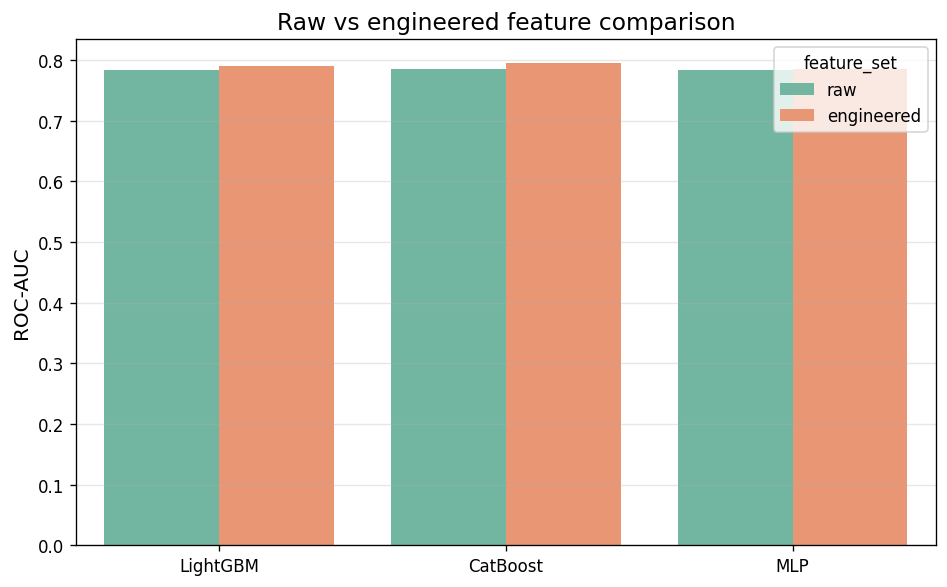

  Figure saved → raw_vs_engineered_comparison.png & .pdf

📊 Raw vs Engineered Feature Ablation:
feature_set  engineered    raw
model                         
CatBoost         0.7951 0.7857
LightGBM         0.7904 0.7840
MLP              0.7859 0.7831


C:\Users\huzaifakhallid\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C:\Users\huzaifakhallid\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C:\Users\huzaifakhallid\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C:\Users\huzaifakhallid\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C:\Users\huzaifakhallid\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C:\Users\huzaifakhallid\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  MLP trained in 5.6s (best AUC=0.7993)


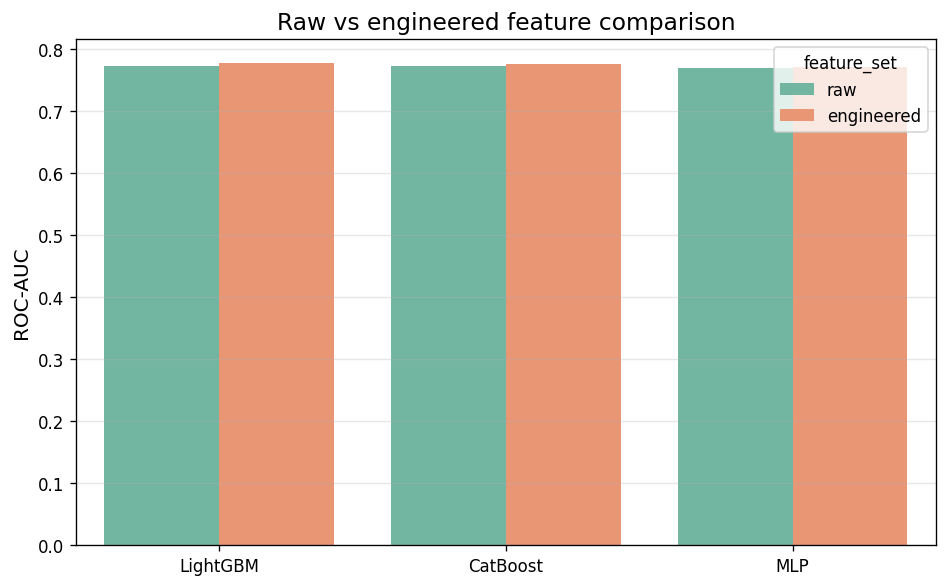

  Figure saved → raw_vs_engineered_comparison.png & .pdf

📊 Raw vs Engineered Feature Ablation:
feature_set  engineered    raw
model                         
CatBoost         0.7759 0.7728
LightGBM         0.7777 0.7727
MLP              0.7721 0.7700


In [136]:
# ──────────────────────────────────────────────────────────────
# 21.6-A  Feature Ablation (Raw vs Engineered)
# ──────────────────────────────────────────────────────────────
print("Running Raw vs Engineered Feature Ablation (shared split, single fold)...")
ablation_records = []
ft0 = fold_tasks[0]

def run_ablation_mode(mode_name):
    print(f"  Evaluating {mode_name} features...")
    df_abl = df_raw_features.copy()
    if mode_name == "engineered":
        df_abl = add_credit_risk_features(df_abl)

    cat_cols_abl = list(CATEGORICAL_COLS)
    num_cols_abl = [c for c in df_abl.columns if c not in cat_cols_abl + [TARGET_COL]]

    pp_abl = TabularPreprocessor(cat_cols_abl, num_cols_abl)
    train_df_a = df_abl.iloc[ft0["train_idx"]]
    val_df_a   = df_abl.iloc[ft0["val_idx"]]
    test_df_a  = df_abl.iloc[ft0["test_idx"]]

    train_data_a = pp_abl.fit_transform(train_df_a)
    val_data_a   = pp_abl.transform(val_df_a)
    test_data_a  = pp_abl.transform(test_df_a)

    results = []

    if HAS_LGB:
        model_lgb = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=5,
            random_state=42, n_jobs=-1, verbose=-1
        )
        model_lgb.fit(
            train_data_a["X_full"], train_data_a["y"],
            eval_set=[(val_data_a["X_full"], val_data_a["y"])],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)]
        )
        y_val_prob_lgb = model_lgb.predict_proba(val_data_a["X_full"])[:, 1]
        y_test_prob_lgb = model_lgb.predict_proba(test_data_a["X_full"])[:, 1]
        thr = tune_threshold_on_val(val_data_a["y"], y_val_prob_lgb)
        met = evaluate_binary_predictions(test_data_a["y"], y_test_prob_lgb, thr)
        met.update({"model": "LightGBM", "feature_set": mode_name})
        results.append(met)

    if HAS_CATBOOST:
        import catboost as cb
        X_train_cb = pd.DataFrame(train_data_a["X_full"], columns=train_data_a["feature_names"])
        X_val_cb = pd.DataFrame(val_data_a["X_full"], columns=val_data_a["feature_names"])
        X_test_cb = pd.DataFrame(test_data_a["X_full"], columns=test_data_a["feature_names"])
        for c in cat_cols_abl:
            X_train_cb[c] = X_train_cb[c].astype(int)
            X_val_cb[c] = X_val_cb[c].astype(int)
            X_test_cb[c] = X_test_cb[c].astype(int)

        model_cb = cb.CatBoostClassifier(
            iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=0
        )
        model_cb.fit(
            X_train_cb,
            train_data_a["y"],
            cat_features=cat_cols_abl,
            eval_set=(X_val_cb, val_data_a["y"]),
            use_best_model=True,
        )
        y_val_prob_cb = model_cb.predict_proba(X_val_cb)[:, 1]
        y_test_prob_cb = model_cb.predict_proba(X_test_cb)[:, 1]
        thr = tune_threshold_on_val(val_data_a["y"], y_val_prob_cb)
        met = evaluate_binary_predictions(test_data_a["y"], y_test_prob_cb, thr)
        met.update({"model": "CatBoost", "feature_set": mode_name})
        results.append(met)

    try:
        device = DEVICE_MAP["MLP"]
        ablation_fold_idx = 100 if mode_name == "raw" else 101
        model_mlp = train_mlp_model(
            train_data_a, val_data_a, test_data_a, pp_abl,
            seed=42, fold_idx=ablation_fold_idx, device=device
        )
        y_test_prob_mlp = model_mlp["y_test_prob"]
        thr = tune_threshold_on_val(val_data_a["y"], model_mlp["y_val_prob"])
        met = evaluate_binary_predictions(test_data_a["y"], y_test_prob_mlp, thr)
        met.update({"model": "MLP", "feature_set": mode_name})
        results.append(met)
    except Exception as e:
        print(f"    MLP ablation failed: {e}")

    return results

try:
    ablation_records.extend(run_ablation_mode("raw"))
    ablation_records.extend(run_ablation_mode("engineered"))

    if ablation_records:
        abl_df = pd.DataFrame(ablation_records)
        abl_df.to_csv(OUTPUT / "metrics" / "raw_vs_engineered_summary.csv", index=False)

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.barplot(
            data=abl_df, x="model", y="roc_auc", hue="feature_set", ax=ax, palette="Set2"
        )
        ax.set_ylabel("ROC-AUC")
        ax.set_xlabel("")
        ax.set_title("Raw vs engineered feature comparison")
        fig.tight_layout()
        save_fig(fig, "raw_vs_engineered_comparison", "figures/models")

        print("\n📊 Raw vs Engineered Feature Ablation:")
        print(
            abl_df.pivot(index="model", columns="feature_set", values="roc_auc")
            .to_string(float_format="%.4f")
        )
except Exception as e:
    print(f"Feature ablation failed: {e}")
    raise

## ***Section 23 — Final Paper‑Ready Result Tables***

### ***What this cell does***
Assembles all key results into formatted tables suitable for a **conference‑quality paper**.

### ***Why it is needed***
Reviewers and readers expect clean, self‑contained result tables that can be directly
inserted into a paper.  Each table is saved in three formats:
- **CSV** — for programmatic access and further analysis.
- **Markdown** — for README files and documentation.
- **LaTeX** — for direct inclusion in academic papers.

### ***Expected output***
Seven tables covering: dataset summary, predictive performance, statistical tests,
faithfulness, stability, runtime, and the overall trade‑off summary.

In [137]:
# ──────────────────────────────────────────────────────────────
# 23‑A  Dataset summary table
# ──────────────────────────────────────────────────────────────
dataset_summary = pd.DataFrame([
    {"Property": "Total Samples", "Value": str(len(df))},
    {"Property": "Features", "Value": str(len(NUMERICAL_COLS) + len(CATEGORICAL_COLS))},
    {"Property": "Numerical Features", "Value": str(len(NUMERICAL_COLS))},
    {"Property": "Categorical Features", "Value": str(len(CATEGORICAL_COLS))},
    {"Property": "Default Rate", "Value": f"{df['target'].mean()*100:.1f}%"},
    {"Property": "Class Balance (0:1)", "Value": f"{(df['target']==0).sum()}:{(df['target']==1).sum()}"},
])
dataset_summary.to_csv(OUTPUT / "tables" / "01_dataset_summary.csv", index=False)
print("Table 1 — Dataset Summary:")
print(dataset_summary.to_string(index=False))

Table 1 — Dataset Summary:
            Property      Value
       Total Samples      29965
            Features         38
  Numerical Features         29
Categorical Features          9
        Default Rate      22.1%
 Class Balance (0:1) 23335:6630


In [138]:
# ──────────────────────────────────────────────────────────────
# 23‑B  Predictive performance table (mean ± std)
# ──────────────────────────────────────────────────────────────
perf_table_rows = []
display_metrics = [
    ("test_roc_auc", "ROC‑AUC"), ("test_pr_auc", "PR‑AUC"),
    ("test_f1", "F1"), ("test_precision", "Precision"),
    ("test_recall", "Recall"), ("test_balanced_acc", "Bal. Acc."),
    ("test_mcc", "MCC"), ("test_brier", "Brier"),
]

for _, row in summary_df.iterrows():
    r = {"Model": row["model"]}
    for col, label in display_metrics:
        mc = f"{col}_mean"
        sc = f"{col}_std"
        if mc in row and not pd.isna(row[mc]):
            mean_v = row[mc]
            std_v = row.get(sc, 0)
            if pd.isna(std_v):
                std_v = 0
            r[label] = f"{mean_v:.4f} ± {std_v:.4f}"
        else:
            r[label] = "—"
    perf_table_rows.append(r)

perf_table = pd.DataFrame(perf_table_rows)
perf_table.to_csv(OUTPUT / "tables" / "02_predictive_performance.csv", index=False)

# LaTeX
try:
    latex_str = perf_table.to_latex(index=False, escape=False)
    with open(OUTPUT / "tables" / "02_predictive_performance.tex", "w") as f:
        f.write(latex_str)
except Exception:
    pass

print("\nTable 2 — Predictive Performance:")
print(perf_table.to_string(index=False))


Table 2 — Predictive Performance:
             Model         ROC‑AUC          PR‑AUC              F1       Precision          Recall       Bal. Acc.             MCC           Brier
LogisticRegression 0.7741 ± 0.0076 0.5407 ± 0.0124 0.5367 ± 0.0120 0.5123 ± 0.0268 0.5661 ± 0.0310 0.7058 ± 0.0084 0.3980 ± 0.0171 0.1838 ± 0.0021
          CatBoost 0.7890 ± 0.0095 0.5666 ± 0.0150 0.5481 ± 0.0129 0.5235 ± 0.0331 0.5788 ± 0.0337 0.7136 ± 0.0087 0.4131 ± 0.0197 0.1770 ± 0.0028
          LightGBM 0.7825 ± 0.0104 0.5555 ± 0.0147 0.5421 ± 0.0123 0.5254 ± 0.0321 0.5639 ± 0.0390 0.7086 ± 0.0100 0.4076 ± 0.0180 0.1537 ± 0.0013
               MLP 0.7828 ± 0.0088 0.5563 ± 0.0146 0.5405 ± 0.0118 0.5281 ± 0.0282 0.5567 ± 0.0347 0.7069 ± 0.0092 0.4067 ± 0.0155 0.1809 ± 0.0025
            TabNet 0.7731 ± 0.0099 0.5350 ± 0.0135 0.5311 ± 0.0143 0.5156 ± 0.0319 0.5528 ± 0.0462 0.7014 ± 0.0114 0.3938 ± 0.0170 0.1846 ± 0.0051


In [139]:
# ──────────────────────────────────────────────────────────────
# 23‑B.5  Statistical summary table
# ──────────────────────────────────────────────────────────────
if 'stat_df' in dir() and not stat_df.empty:
    stat_table = stat_df.copy()
    stat_table.to_csv(OUTPUT / "tables" / "03_statistical_tests.csv", index=False)
    if 'catboost_stat_df' in dir() and not catboost_stat_df.empty:
        catboost_stat_df.to_csv(OUTPUT / "tables" / "03_catboost_statistical_tests.csv", index=False)

    print("\nTable 3 — Statistical Tests:")
    display_cols = [
        "metric", "model_A", "model_B", "test", "n_pairs",
        "mean_diff", "median_diff", "p_value", "effect_direction", "status"
    ]
    print(stat_table[display_cols].to_string(index=False, float_format="%.4f"))


Table 3 — Statistical Tests:
 metric  model_A            model_B     test  n_pairs  mean_diff  median_diff  p_value effect_direction status
ROC-AUC LightGBM                MLP wilcoxon       15    -0.0003      -0.0001   0.9780            B > A     ok
ROC-AUC LightGBM             TabNet wilcoxon       15     0.0094       0.0093   0.0001            A > B     ok
ROC-AUC      MLP             TabNet wilcoxon       15     0.0096       0.0097   0.0001            A > B     ok
ROC-AUC CatBoost           LightGBM wilcoxon       15     0.0065       0.0071   0.0001            A > B     ok
ROC-AUC CatBoost                MLP wilcoxon       15     0.0063       0.0065   0.0001            A > B     ok
ROC-AUC CatBoost             TabNet wilcoxon       15     0.0159       0.0165   0.0001            A > B     ok
ROC-AUC CatBoost LogisticRegression wilcoxon       15     0.0150       0.0155   0.0001            A > B     ok
 PR-AUC LightGBM                MLP wilcoxon       15    -0.0009       0.0002   0.

In [140]:
# ──────────────────────────────────────────────────────────────
# 23‑C  Faithfulness & stability tables
# ──────────────────────────────────────────────────────────────
if 'faith_summary' in dir() and not faith_summary.empty:
    faith_pivot = faith_summary.pivot_table(
        index=["model_name", "reference_model_name", "method"],
        columns="k",
        values="abs_change_mean",
    ).reset_index()
    faith_pivot.to_csv(OUTPUT / "tables" / "04_faithfulness.csv", index=False)
    print("\nTable 4 — Faithfulness (Mean |ΔP| by k):")
    print(faith_pivot.to_string(index=False, float_format="%.4f"))

# Stability table
if not stability_df.empty:
    stability_df.to_csv(OUTPUT / "tables" / "05_stability.csv", index=False)
    print("\nTable 5 — Explanation Stability:")
    print(stability_df.to_string(index=False, float_format="%.4f"))

# Runtime table
if 'train_rt' in dir():
    train_rt.to_csv(OUTPUT / "tables" / "06_runtime.csv", index=False)
    print("\nTable 6 — Training Runtime:")
    print(train_rt.to_string(index=False, float_format="%.2f"))


Table 4 — Faithfulness (Mean |ΔP| by k):
     model_name reference_model_name              method      1      3      5     10
       CatBoost             CatBoost            TreeSHAP 0.0856 0.1659 0.2072 0.2512
       LightGBM             LightGBM            TreeSHAP 0.0553 0.0881 0.1056 0.1242
            MLP                  MLP IntegratedGradients 0.1151 0.2089 0.2377 0.2651
Random-CatBoost             CatBoost              Random 0.0112 0.0292 0.0448 0.0862
Random-LightGBM             LightGBM              Random 0.0038 0.0111 0.0188 0.0371
     Random-MLP                  MLP              Random 0.0109 0.0278 0.0409 0.0733
  Random-TabNet               TabNet              Random 0.0123 0.0323 0.0481 0.0861
         TabNet               TabNet         TabNetMasks 0.0987 0.1583 0.1776 0.1899

Table 5 — Explanation Stability:
     model_name              method  n_pairs  mean_spearman  std_spearman  min_spearman  max_spearman
Random-CatBoost              Random      105         0.34

In [141]:
# ──────────────────────────────────────────────────────────────
# 23‑D  Trade‑off summary table
# ──────────────────────────────────────────────────────────────
tradeoff_rows = []
for mn in MODEL_NAMES:
    row = {"Model": mn}

    # AUC
    auc_col = "test_roc_auc_mean"
    if auc_col in summary_df.columns:
        row["ROC‑AUC"] = f"{summary_df.loc[summary_df['model']==mn, auc_col].values[0]:.4f}"

    # Faithfulness at k=5
    if 'faith_summary' in dir() and not faith_summary.empty:
        fk5 = faith_summary[(faith_summary["model_name"]==mn) & (faith_summary["k"]==5)]
        if not fk5.empty:
            row["Faith@k=5"] = f"{fk5['abs_change_mean'].values[0]:.4f}"

    # Stability
    stab_row = stability_df[stability_df["model_name"] == mn]
    if not stab_row.empty and not pd.isna(stab_row["mean_spearman"].values[0]):
        row["Stability (ρ)"] = f"{stab_row['mean_spearman'].values[0]:.4f}"

    # Training time
    rt_row = train_rt[train_rt["model"] == mn]
    if not rt_row.empty:
        row["Train Time (s)"] = f"{rt_row['train_time_mean'].values[0]:.1f}"

    tradeoff_rows.append(row)

tradeoff_df = pd.DataFrame(tradeoff_rows)
tradeoff_df.to_csv(OUTPUT / "tables" / "07_tradeoff_summary.csv", index=False)
print("\nTable 7 — Performance‑Explainability Trade‑off:")
print(tradeoff_df.to_string(index=False))


Table 7 — Performance‑Explainability Trade‑off:
             Model ROC‑AUC Train Time (s) Faith@k=5 Stability (ρ)
LogisticRegression  0.7741            1.7       NaN           NaN
          CatBoost  0.7890           10.7    0.2072        0.8584
          LightGBM  0.7825            0.2    0.1056        0.8683
               MLP  0.7828            9.9    0.2377        0.7877
            TabNet  0.7731           30.9    0.1776        0.2394


## ***Section 24 — Final Research Interpretation***

### ***Key Findings*** (generated from actual results)

This section dynamically generates an honest evaluation report based on the actual CSV results
produced in the previous steps.  Mixed or negative results are framed as deployment-relevant trade-offs.

In [142]:
# ──────────────────────────────────────────────────────────────
# 24-A  Generate interpretation report dynamically
# ──────────────────────────────────────────────────────────────
def load_optional_csv(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

def generate_final_interpretation():
    report = []
    report.append("# Final Paper Interpretation\n")
    report.append("This report is generated from the saved result tables and is intentionally conditional on the observed outputs.\n")

    if CFG.run_mode == "debug":
        report.append("> **Verification-only note:** this run used DEBUG mode, so paired tests, stability estimates, and final-paper claims remain underpowered. Treat the numbers below as a pipeline check, not final evidence.\n")

    perf = load_optional_csv(OUTPUT / "metrics" / "predictive_metrics_summary.csv")
    faith = load_optional_csv(OUTPUT / "metrics" / "faithfulness_summary.csv")
    stab = load_optional_csv(OUTPUT / "metrics" / "stability_summary.csv")
    train_rt_local = load_optional_csv(OUTPUT / "metrics" / "runtime_summary.csv")
    exp_rt = load_optional_csv(OUTPUT / "metrics" / "explanation_runtime_summary.csv")
    cal = load_optional_csv(OUTPUT / "metrics" / "calibration_summary.csv")
    cost = load_optional_csv(OUTPUT / "metrics" / "cost_sensitive_summary_validation_thresholds.csv")
    fair = load_optional_csv(OUTPUT / "metrics" / "fairness_groupwise_diagnostics_extended.csv")
    abl = load_optional_csv(OUTPUT / "metrics" / "raw_vs_engineered_summary.csv")
    rand_cmp = load_optional_csv(OUTPUT / "metrics" / "model_specific_random_faithfulness.csv")

    best_auc_model = None
    if not perf.empty and "test_roc_auc_mean" in perf.columns:
        best_auc_row = perf.loc[perf["test_roc_auc_mean"].idxmax()]
        best_auc_model = best_auc_row["model"]
        report.append("## Predictive Performance")
        report.append(
            f"- Highest mean ROC-AUC: **{best_auc_model}** ({best_auc_row['test_roc_auc_mean']:.4f})."
        )
    else:
        report.append("## Predictive Performance")
        report.append("- Predictive summary was not available.")

    if not cost.empty and "test_avg_cost_mean" in cost.columns:
        scenario_winners = cost.loc[cost.groupby("scenario")["test_avg_cost_mean"].idxmin()].copy()
        winner_counts = scenario_winners["model_name"].value_counts()
        top_cost_model = winner_counts.index[0]
        report.append(
            f"- Lowest validation-threshold test cost won most often by **{top_cost_model}** "
            f"({int(winner_counts.iloc[0])}/{len(scenario_winners)} scenarios)."
        )
        if best_auc_model == "CatBoost" and top_cost_model == "CatBoost":
            report.append("- **CatBoost** was the strongest predictive/cost-sensitive option on this run.")
        elif best_auc_model == "CatBoost":
            report.append("- **CatBoost** led predictive performance, but cost-sensitive wins were scenario-dependent.")

    report.append("\n## Explanation Faithfulness")
    real_faith_k5 = faith[
        (~faith["model_name"].str.startswith("Random-")) & (faith["k"] == 5)
    ].copy() if not faith.empty else pd.DataFrame()
    if not real_faith_k5.empty:
        best_faith_row = real_faith_k5.loc[real_faith_k5["abs_change_mean"].idxmax()]
        report.append(
            f"- Highest mean |ΔP| at k=5: **{best_faith_row['model_name']} + {best_faith_row['method']}** "
            f"({best_faith_row['abs_change_mean']:.4f})."
        )
        if best_faith_row["model_name"] == "MLP" and best_faith_row["method"] == "IntegratedGradients":
            report.append("- **MLP + Integrated Gradients** was the strongest faithfulness result on this run.")
        else:
            report.append("- The faithfulness winner was not MLP + Integrated Gradients on this run, so no superiority claim is made.")
    else:
        report.append("- Faithfulness summary was not available.")

    if not rand_cmp.empty:
        k5_cmp = rand_cmp[rand_cmp["k"] == 5].copy()
        if not k5_cmp.empty:
            deltas = [
                f"{row['model_name']} vs Random-{row['reference_model_name']}: Δ|ΔP|={row['delta_vs_random_abs_change']:.4f}"
                for _, row in k5_cmp.iterrows()
            ]
            report.append(f"- Model-specific random baseline comparison at k=5: {'; '.join(deltas)}.")

    report.append("\n## Stability, Calibration, and Runtime")
    valid_stab = stab[
        (~stab["model_name"].str.startswith("Random-")) & stab["mean_spearman"].notna()
    ].copy() if not stab.empty else pd.DataFrame()
    best_stab_model = None
    if not valid_stab.empty:
        best_stab_row = valid_stab.loc[valid_stab["mean_spearman"].idxmax()]
        best_stab_model = best_stab_row["model_name"]
        report.append(
            f"- Highest available stability: **{best_stab_row['model_name']} + {best_stab_row['method']}** "
            f"(mean Spearman ρ={best_stab_row['mean_spearman']:.4f})."
        )
        if best_stab_row["model_name"] == "LightGBM":
            report.append("- **LightGBM + TreeSHAP** was the strongest stability result on this run.")
    else:
        report.append("- Stability was underpowered or unavailable in this run.")

    best_cal_model = None
    if not cal.empty and "brier_score" in cal.columns:
        best_cal_row = cal.sort_values(["brier_score", "ece"]).iloc[0]
        best_cal_model = best_cal_row["model_name"]
        report.append(
            f"- Best calibration by Brier/ECE ordering: **{best_cal_model}** "
            f"(Brier={best_cal_row['brier_score']:.4f}, ECE={best_cal_row['ece']:.4f})."
        )

    fastest_train_model = None
    if not train_rt_local.empty and "train_time_mean" in train_rt_local.columns:
        fastest_train_row = train_rt_local.loc[train_rt_local["train_time_mean"].idxmin()]
        fastest_train_model = fastest_train_row["model"]
        report.append(
            f"- Fastest training runtime: **{fastest_train_model}** ({fastest_train_row['train_time_mean']:.2f}s mean)."
        )

    if best_stab_model == "LightGBM" and best_cal_model is not None and "LightGBM" in str(best_cal_model) and fastest_train_model == "LightGBM":
        report.append("- **LightGBM + TreeSHAP** offered the strongest combined stability/calibration/runtime profile on this run.")
    else:
        report.append("- The combined stability/calibration/runtime edge was mixed on this run, so the notebook reports the individual winners above instead of forcing a single claim.")

    report.append("\n## TabNet Interpretation")
    tabnet_mask_fast = False
    if not exp_rt.empty and "time_per_sample_mean" in exp_rt.columns:
        non_random_rt = exp_rt[~exp_rt["model_name"].str.startswith("Random-")].copy()
        if not non_random_rt.empty:
            fastest_exp_row = non_random_rt.loc[non_random_rt["time_per_sample_mean"].idxmin()]
            tabnet_mask_fast = (
                fastest_exp_row["model_name"] == "TabNet"
                and fastest_exp_row["method"] == "TabNetMasks"
            )
            report.append(
                f"- Fastest explanation runtime per sample: **{fastest_exp_row['model_name']} + {fastest_exp_row['method']}** "
                f"({fastest_exp_row['time_per_sample_mean'] * 1000:.3f} ms/sample)."
            )

    tabnet_superior = any([
        best_auc_model == "TabNet",
        not real_faith_k5.empty and real_faith_k5.loc[real_faith_k5["abs_change_mean"].idxmax(), "model_name"] == "TabNet",
        best_stab_model == "TabNet",
    ])
    if tabnet_mask_fast and not tabnet_superior:
        report.append("- **TabNet masks** were fast, but this run does not support a claim of intrinsic superiority over stronger post-hoc alternatives.")
    elif tabnet_superior:
        report.append("- TabNet was competitive on at least one primary axis in this run, so the notebook avoids blanket negative claims.")
    else:
        report.append("- TabNet did not establish a clear advantage on the main evaluation axes in this run.")

    report.append("\n## Raw vs Engineered Features")
    if not abl.empty:
        roc_pivot = abl.pivot(index="model", columns="feature_set", values="roc_auc")
        if {"raw", "engineered"}.issubset(set(roc_pivot.columns)):
            deltas = roc_pivot["engineered"] - roc_pivot["raw"]
            if (deltas > 0).all():
                report.append("- Engineered features improved ROC-AUC for all ablation models in this run.")
            elif (deltas <= 0).all():
                report.append("- Engineered features did not improve ROC-AUC for the ablation models in this run.")
            else:
                report.append("- Raw vs engineered results were mixed, so the notebook does not claim a universal feature-engineering benefit.")

    report.append("\n## Fairness Diagnostics")
    if not fair.empty:
        attrs = ", ".join(sorted(fair["attribute"].dropna().unique()))
        report.append(
            f"- Groupwise descriptive diagnostics were computed for **{attrs}**, including group size, default rate, predicted positive rate, TPR, FPR, FNR, Brier score, and ROC-AUC where defined."
        )
    report.append("- These fairness outputs are descriptive diagnostics only and should not be interpreted as causal or normative fairness claims.")

    return "\n".join(report)

def generate_final_run_report(interpretation_text):
    lines = []
    lines.append("# Final Run Report\n")
    lines.append("## What Changed")
    lines.append("- Added CatBoost-focused paired statistical test output.")
    lines.append("- Corrected cost-sensitive evaluation to use validation-only threshold selection per run.")
    lines.append("- Added raw-vs-engineered ablation, model-specific random faithfulness baselines, extended fairness diagnostics, and richer local case studies.")
    lines.append("- Rewrote the paper interpretation so it depends on saved results instead of fixed favorable language.\n")

    lines.append("## Key Updated Results")
    for line in interpretation_text.splitlines():
        if line.startswith("- "):
            lines.append(line)
    lines.append("")

    lines.append("## Warnings")
    warning_items = EXECUTION_WARNINGS_ERRORS if "EXECUTION_WARNINGS_ERRORS" in globals() else []
    if warning_items:
        for warning in warning_items[-8:]:
            lines.append(f"- {warning['type']}: {warning['message']}")
    else:
        lines.append("- No execution warnings were recorded.")
    lines.append("")

    lines.append("## Remaining Limitations")
    lines.append("- DEBUG mode is suitable for pipeline verification but not for final inferential claims.")
    lines.append("- Stability and paired significance results may be underpowered when only one seed/fold is available.")
    lines.append("- Fairness diagnostics remain descriptive and dataset-bound.")
    return "\n".join(lines)

report_text = generate_final_interpretation()
run_report_text = generate_final_run_report(report_text)

for out_name in ["final_paper_interpretation.md", "final_results_interpretation.md"]:
    with open(OUTPUT / out_name, "w", encoding="utf-8") as f:
        f.write(report_text)

with open(OUTPUT / "final_run_report.md", "w", encoding="utf-8") as f:
    f.write(run_report_text)

print("✓ Final interpretation and run report generated and saved.")

from IPython.display import display, Markdown
display(Markdown(report_text))
display(Markdown(run_report_text))

✓ Final interpretation and run report generated and saved.


# Final Paper Interpretation

This report is generated from the saved result tables and is intentionally conditional on the observed outputs.

## Predictive Performance
- Highest mean ROC-AUC: **CatBoost** (0.7890).
- Lowest validation-threshold test cost won most often by **CatBoost** (3/3 scenarios).
- **CatBoost** was the strongest predictive/cost-sensitive option on this run.

## Explanation Faithfulness
- Highest mean |ΔP| at k=5: **MLP + IntegratedGradients** (0.2377).
- **MLP + Integrated Gradients** was the strongest faithfulness result on this run.
- Model-specific random baseline comparison at k=5: CatBoost vs Random-CatBoost: Δ|ΔP|=0.1624; LightGBM vs Random-LightGBM: Δ|ΔP|=0.0868; MLP vs Random-MLP: Δ|ΔP|=0.1968; TabNet vs Random-TabNet: Δ|ΔP|=0.1295.

## Stability, Calibration, and Runtime
- Highest available stability: **LightGBM + TreeSHAP** (mean Spearman ρ=0.8683).
- **LightGBM + TreeSHAP** was the strongest stability result on this run.
- Best calibration by Brier/ECE ordering: **MLP (Platt)** (Brier=0.1347, ECE=0.0104).
- Fastest training runtime: **LightGBM** (0.21s mean).
- The combined stability/calibration/runtime edge was mixed on this run, so the notebook reports the individual winners above instead of forcing a single claim.

## TabNet Interpretation
- Fastest explanation runtime per sample: **TabNet + TabNetMasks** (0.036 ms/sample).
- **TabNet masks** were fast, but this run does not support a claim of intrinsic superiority over stronger post-hoc alternatives.

## Raw vs Engineered Features
- Engineered features improved ROC-AUC for all ablation models in this run.

## Fairness Diagnostics
- Groupwise descriptive diagnostics were computed for **EDUCATION, MARRIAGE, SEX**, including group size, default rate, predicted positive rate, TPR, FPR, FNR, Brier score, and ROC-AUC where defined.
- These fairness outputs are descriptive diagnostics only and should not be interpreted as causal or normative fairness claims.

# Final Run Report

## What Changed
- Added CatBoost-focused paired statistical test output.
- Corrected cost-sensitive evaluation to use validation-only threshold selection per run.
- Added raw-vs-engineered ablation, model-specific random faithfulness baselines, extended fairness diagnostics, and richer local case studies.
- Rewrote the paper interpretation so it depends on saved results instead of fixed favorable language.

## Key Updated Results
- Highest mean ROC-AUC: **CatBoost** (0.7890).
- Lowest validation-threshold test cost won most often by **CatBoost** (3/3 scenarios).
- **CatBoost** was the strongest predictive/cost-sensitive option on this run.
- Highest mean |ΔP| at k=5: **MLP + IntegratedGradients** (0.2377).
- **MLP + Integrated Gradients** was the strongest faithfulness result on this run.
- Model-specific random baseline comparison at k=5: CatBoost vs Random-CatBoost: Δ|ΔP|=0.1624; LightGBM vs Random-LightGBM: Δ|ΔP|=0.0868; MLP vs Random-MLP: Δ|ΔP|=0.1968; TabNet vs Random-TabNet: Δ|ΔP|=0.1295.
- Highest available stability: **LightGBM + TreeSHAP** (mean Spearman ρ=0.8683).
- **LightGBM + TreeSHAP** was the strongest stability result on this run.
- Best calibration by Brier/ECE ordering: **MLP (Platt)** (Brier=0.1347, ECE=0.0104).
- Fastest training runtime: **LightGBM** (0.21s mean).
- The combined stability/calibration/runtime edge was mixed on this run, so the notebook reports the individual winners above instead of forcing a single claim.
- Fastest explanation runtime per sample: **TabNet + TabNetMasks** (0.036 ms/sample).
- **TabNet masks** were fast, but this run does not support a claim of intrinsic superiority over stronger post-hoc alternatives.
- Engineered features improved ROC-AUC for all ablation models in this run.
- Groupwise descriptive diagnostics were computed for **EDUCATION, MARRIAGE, SEX**, including group size, default rate, predicted positive rate, TPR, FPR, FNR, Brier score, and ROC-AUC where defined.
- These fairness outputs are descriptive diagnostics only and should not be interpreted as causal or normative fairness claims.

## Warnings
- preprocessing: Removed 35 exact duplicate rows to prevent train/test leakage.

## Remaining Limitations
- DEBUG mode is suitable for pipeline verification but not for final inferential claims.
- Stability and paired significance results may be underpowered when only one seed/fold is available.
- Fairness diagnostics remain descriptive and dataset-bound.

## ***Section 25 — Save Reproducibility Artefacts***

### ***What this cell does***
Saves all configuration, metadata, package versions, and a README documenting the output
directory structure.

### ***Why it is needed***
Full reproducibility requires that every aspect of the experimental setup — software versions,
hardware info, random seeds, and hyperparameters — is archived alongside the results.

In [143]:
# ──────────────────────────────────────────────────────────────
# 25‑A  Save all reproducibility artefacts
# ──────────────────────────────────────────────────────────────
# Config already saved.  Save package versions.
import pkg_resources
pkg_versions = {pkg.key: pkg.version for pkg in pkg_resources.working_set}
with open(OUTPUT / "package_versions.json", "w") as f:
    json.dump(pkg_versions, f, indent=2)

# README
readme = """
Credit Risk XAI Study — Output Directory
=========================================
Generated by: credit_risk_xai_study.ipynb
Run mode: {mode}

Directory structure:
  config.json          — Experiment configuration
  hardware_info.json   — Hardware/GPU info
  package_versions.json— Installed package versions
  feature_metadata.json— Feature definitions and cardinalities
  fold_metadata.csv    — CV fold details
  cleaned_dataset.csv  — Cleaned dataset

  metrics/
    predictive_metrics_all.csv      — Per-fold raw metrics
    predictive_metrics_summary.csv  — Aggregated mean ± std
    statistical_tests.csv           — Pairwise significance tests
    catboost_statistical_tests.csv  — CatBoost-focused statistical tests
    cost_sensitive_summary_validation_thresholds.csv — Validation-threshold cost summary
    faithfulness_raw.csv            — Per-sample faithfulness scores
    faithfulness_summary.csv        — Aggregated faithfulness
    model_specific_random_faithfulness.csv — Real vs random faithfulness comparison
    stability_summary.csv           — Explanation stability
    runtime_summary.csv             — Training & explanation runtimes
    raw_vs_engineered_summary.csv   — Controlled ablation summary
    local_case_studies_detailed.csv — Detailed TP/TN/FP/FN case exports
    fairness_groupwise_diagnostics_extended.csv — Groupwise descriptive diagnostics
    predictions_*.csv               — Per-model predictions

  explanations/
    attributions_*.csv  — Per-sample feature attributions
    importance_*.csv    — Global feature importance

  figures/
    eda/    — EDA visualisations
    models/ — ROC, PR, confusion matrices, training curves
    xai/    — Faithfulness, stability, importance, runtime plots

  models/
    *.pt        — MLP checkpoints
    *.zip       — TabNet model saves

  tables/
    01–08_*.csv — Paper-ready result tables

  final_paper_interpretation.md — Result-driven interpretation
  final_run_report.md           — Short execution report
""".format(mode=CFG.run_mode)

with open(OUTPUT / "README.txt", "w") as f:
    f.write(readme)

# List all outputs
all_files = sorted(OUTPUT.rglob("*"))
output_files = [str(p.relative_to(OUTPUT)) for p in all_files if p.is_file()]
print(f"Total output files: {len(output_files)}")
for fp in output_files[:30]:
    print(f"  {fp}")
if len(output_files) > 30:
    print(f"  ... and {len(output_files) - 30} more.")

Total output files: 711
  README.txt
  cleaned_dataset.csv
  config.json
  execution_warnings_errors.json
  execution_warnings_errors.md
  explanations/attributions_CatBoost_s2024_f0.csv
  explanations/attributions_CatBoost_s2024_f1.csv
  explanations/attributions_CatBoost_s2024_f2.csv
  explanations/attributions_CatBoost_s2024_f3.csv
  explanations/attributions_CatBoost_s2024_f4.csv
  explanations/attributions_CatBoost_s42_f0.csv
  explanations/attributions_CatBoost_s42_f1.csv
  explanations/attributions_CatBoost_s42_f2.csv
  explanations/attributions_CatBoost_s42_f3.csv
  explanations/attributions_CatBoost_s42_f4.csv
  explanations/attributions_CatBoost_s7_f0.csv
  explanations/attributions_CatBoost_s7_f1.csv
  explanations/attributions_CatBoost_s7_f2.csv
  explanations/attributions_CatBoost_s7_f3.csv
  explanations/attributions_CatBoost_s7_f4.csv
  explanations/attributions_LightGBM_s2024_f0.csv
  explanations/attributions_LightGBM_s2024_f1.csv
  explanations/attributions_LightGBM_s

## ***Section 25.5 — Notebook Execution Validation***

### ***What this cell does***
Performs a series of automated sanity checks (predictions exist, shapes match, files generated)
before packaging the final ZIP.  Raises an error if critical checks fail.

In [144]:
# ──────────────────────────────────────────────────────────────
# 25.5-A  Automated Validation Checks
# ──────────────────────────────────────────────────────────────
validation_log = []

def check(name, condition, critical=True):
    status = "PASS" if condition else ("FAIL" if critical else "WARNING")
    validation_log.append({"check": name, "status": status})
    if not condition and critical:
        raise RuntimeError(f"Critical validation failed: {name}")

def check_csv_columns(path, required_columns, critical=True):
    exists = path.exists()
    check(f"{path.name} exists", exists, critical=critical)
    if not exists:
        return
    df_check = pd.read_csv(path)
    missing = [col for col in required_columns if col not in df_check.columns]
    check(
        f"{path.name} columns: {', '.join(required_columns)}",
        len(missing) == 0,
        critical=critical,
    )

# Check 1: Target binary
check("Target is binary", set(df["target"].unique()) == {0, 1})
# Check 2: Preprocessor fits
check("No missing values in df", df.isnull().sum().sum() == 0)
# Check 3: Folds created
check("CV folds generated", len(fold_tasks) == CFG.n_folds * len(CFG.random_seeds))
# Check 4: Outputs exist
check("Tradeoff summary exists", (OUTPUT / "tables" / "07_tradeoff_summary.csv").exists())
check("Faithfulness summary exists", (OUTPUT / "metrics" / "faithfulness_summary.csv").exists())
check("Runtime summary exists", (OUTPUT / "metrics" / "runtime_summary.csv").exists())
check("Predictions saved", len(list((OUTPUT / "metrics").glob("predictions_*.csv"))) > 0)
check("Explanations saved", len(list((OUTPUT / "explanations").glob("attributions_*.csv"))) > 0)
check("Final paper interpretation exists", (OUTPUT / "final_paper_interpretation.md").exists())
check("Final run report exists", (OUTPUT / "final_run_report.md").exists())

check_csv_columns(
    OUTPUT / "metrics" / "catboost_statistical_tests.csv",
    ["metric", "model_A", "model_B", "mean_diff", "median_diff", "p_value", "effect_direction", "status"],
)
check_csv_columns(
    OUTPUT / "metrics" / "raw_vs_engineered_summary.csv",
    ["model", "feature_set", "roc_auc", "pr_auc", "f1"],
)
check_csv_columns(
    OUTPUT / "metrics" / "model_specific_random_faithfulness.csv",
    ["model_name", "reference_model_name", "k", "abs_change_mean", "random_abs_change_mean", "delta_vs_random_abs_change"],
)
check_csv_columns(
    OUTPUT / "metrics" / "cost_sensitive_summary_validation_thresholds.csv",
    ["model_name", "scenario", "best_threshold_mean", "test_avg_cost_mean"],
)
check_csv_columns(
    OUTPUT / "metrics" / "local_case_studies_detailed.csv",
    ["case_type", "true_label", "pred_label", "probability", "CatBoost_Top5", "MLP_Top5", "TabNet_Top5", "raw_features_json"],
)
check_csv_columns(
    OUTPUT / "metrics" / "fairness_groupwise_diagnostics_extended.csv",
    ["model_name", "attribute", "group", "group_size", "default_rate", "predicted_positive_rate", "recall_tpr", "fpr", "fnr", "brier_score", "roc_auc"],
)

val_df = pd.DataFrame(validation_log)
val_df.to_csv(OUTPUT / "validation_report.csv", index=False)
with open(OUTPUT / "validation_report.json", "w") as f:
    json.dump(validation_log, f, indent=2)

print("✓ All critical notebook validations passed.")

✓ All critical notebook validations passed.


## ***Section 26 — Zip Output Directory***

### ***What this cell does***
Saves the execution warnings log and creates a downloadable `.zip` archive of all experiment outputs.

### ***Why it is needed***
Kaggle notebooks produce outputs under `/kaggle/working/`.  Zipping the full output
directory creates a single downloadable artefact containing all metrics, figures,
models, and tables produced by this study.

In [145]:
# ──────────────────────────────────────────────────────────────
# 26‑A  Create zip archive
# ──────────────────────────────────────────────────────────────
import shutil

# Save warnings/errors before zip
if "EXECUTION_WARNINGS_ERRORS" in globals():
    with open(OUTPUT / "execution_warnings_errors.json", "w") as f:
        json.dump(EXECUTION_WARNINGS_ERRORS, f, indent=2)
    with open(OUTPUT / "execution_warnings_errors.md", "w", encoding="utf-8") as f:
        f.write("# Execution Warnings and Errors\n\n")
        for w in EXECUTION_WARNINGS_ERRORS:
            f.write(f"- **{w['type']}**: {w['message']}\n")

# Use absolute path if in Kaggle, else relative to parent
if Path("/kaggle/working").exists():
    zip_base = Path("/kaggle/working/credit_xai_outputs")
else:
    zip_base = OUTPUT.parent / "credit_xai_outputs"

zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=str(OUTPUT.parent),
                                base_dir=OUTPUT.name)

zip_size_mb = Path(zip_path).stat().st_size / (1024 * 1024)
print(f"\n{'='*60}")
print(f"✅ OUTPUT ARCHIVE CREATED")
print(f"   Path: {zip_path}")
print(f"   Size: {zip_size_mb:.1f} MB")
print(f"{'='*60}")
print(f"\nTotal experiment runtime: {time.time() - exp_t0:.0f}s")
print("\n🎓 Notebook execution complete!")


✅ OUTPUT ARCHIVE CREATED
   Path: /kaggle/working/credit_xai_outputs.zip
   Size: 39.1 MB

Total experiment runtime: 3716s

🎓 Notebook execution complete!


In [146]:
# ──────────────────────────────────────────────────────────────
# Final cleanup: release model objects from result dicts
# ──────────────────────────────────────────────────────────────
for r in all_results:
    for key in list(r.keys()):
        if key.startswith("_"):
            del r[key]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✓ Memory cleaned up. Notebook done.")

✓ Memory cleaned up. Notebook done.
